# Where the Eye Lingers: Exploring the Temporal Dynamics of Test-Taking

#### A Series of Sequence-Aware Deep Learning Models by Adrian Denzel Macayan and Luis Andrew Madridijo

<img src="image1_test_taking.png" alt="Your Alt Text" width="1000"/>
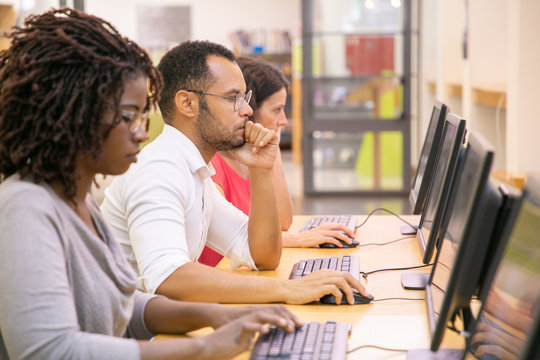

#### A Python Notebook Implementation of "Where the Eye Lingers: Exploring the Temporal Dynamics of Test-Taking" to Run Locally on a Single-GPU (CUDA 5070 Ti)

#### Research Objectives
1. To **test** whether **sequence-aware neural architectures** (RNN/GRU, Transformer) applied to **raw eye-movement trajectories** can meaningfully model the **cognitive process** behind an answer, beyond what aggregate ML baselines capture.
2. To **identify** which **specific ocular behaviors** (fixation duration, saccade amplitude, pupil dilation, and their temporal combinations) carry the **strongest predictive signal**, rather than treating eye-movement data as undifferentiated input.
3. To **evaluate** whether sequence-aware architectures (RNN/GRU, Transformer) trained solely on **physiological signals** can **close or exceed the performance gap** left by **demographic-based models**, establishing a bias-resistant methodology.

#### Distilled Version of the Full Exploratory Notebook (Originally on Kaggle)
1. **Full repeatability**: We set a single global seed is set once at the top, where every stochastic library (`random`, `numpy`, `torch`, CUDA) is seeded, and PyTorch's deterministic algorithms are enabled throughout. Every model construction is additionally re-seeded immediately before it, so each
   phase is independently reproducible even if run in isolation.
2. **Strict test-set isolation**: We ensure that the test set is not touched, evaluated, or printed anywhere until the single, final model has been chosen using validation metrics alone, which happens in exactly one cell, near the end. (The 3 data ablations after it are exempt by design -- they are comparative reporting studies where showing test performance for every condition *is* the deliverable, not a search for one winner.)
3. **No hardcoded hyperparameters**: Every search phase (the 30-trial backbone search, the
   architecture ablation, the `linear_per_timestep`-specific 30-trial search, etc.) selects its winner programmatically from that phase's own results table and passes the winning configuration forward as a variable, rather than a hand-copied literal dict. Re-running this notebook end to end will always use whatever configuration that run's search actually produced.
4. **Single-GPU only**: Every `nn.DataParallel` branch and the dual-GPU threaded search loop from the exploratory notebook have been removed (previously leveraged in Kaggle). We instead run locally in PyCharm on a single CUDA GPU (an RTX 5070 Ti), at the cost of the multi-GPU speedup those branches provided, such that it still runs correctly on any other single-GPU (or CPU) runtime.

#### Note: This is the full, faithful pipeline the Where the Eye Linger models was designed and analyzed with. Both 30-trial searches and the 6-way architecture ablation do run in full for RNN, RNN with Ablation, and Transformer-based Models. With a 5070ti, expect a long (2-hour) end-to-end runtime if executing top to bottom.

## Section 1: Notebook Configuration

### Section 1a: Importing necessary Packages and External Libraries

#### Python Libraries
1. import os: Interacts with the operating system to navigate directories and managing file paths.
2. import glob: Finds and retrieves file paths that match a specific pattern for finding all TüEyeQ .csv files in a folder.
3. import copy: Creates copies of Python objects for data modification without altering the original source.
4. import random: Generates pseudo-random numbers to handle random sampling.
5. import gc: Manually triggers Python's garbage collector between hyperparameter-search trials, freeing GPU memory that a trial's now-unreachable model/optimizer would otherwise leave allocated.
6. import math: Provides trigonometric and logarithmic functions used by the cosine learning-rate schedule and the Transformer's sinusoidal positional encoding.

#### Data Manipulation & Visualization
1. from IPython.display import display: Render Jupyter Notebooks rich and formatted outputs instead of plain text.
2. import numpy as np: High-performance math on multidimensional arrays and matrices
3. import pandas as pd: Dataframe data structure
4. import matplotlib.pyplot as plt: Renders the training curves, confusion-matrix heatmaps, and comparison charts used throughout this notebook.
5. import seaborn as sns: Adds statistical-plotting conveniences (heatmaps, consistent color palettes) on top of matplotlib.

#### Machine Learning (Scikit-Learn)
1. from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score: Evaluation metrics to measure how well the Where the Eye Lingers classification model is performing.
2. from sklearn.model_selection import train_test_split: Randomly divides the dataset into separate training and testing subsets.
3. from sklearn.preprocessing import StandardScaler: Normalizes dataset features to a mean of zero and variance of one to help algorithms converge faster.
4. from sklearn.utils.class_weight import compute_class_weight: Calculates penalty weights for unbalanced datasets to prevent the model from ignoring minority classes.

#### Deep Learning (PyTorch)
1. import torch: Create and manipulate multi-dimensional tensors.
2. import torch.nn as nn: Building blocks to construct neural networks.
3. import torch.optim as optim: Implements optimization algorithms that tweak neural network weights during training.
4. from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence: Allows recurrent neural networks to efficiently process sequential data of varying lengths.
5. from torch.utils.data import DataLoader: Efficiently batches, shuffles, and feeds data into PyTorch models.

In [1]:
import copy
import gc
import glob
import math
import os
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import display

from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader

In [2]:
import time

_notebook_start_time = time.time()
print(f"Notebook timer started at {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_notebook_start_time))}")


Notebook timer started at 2026-08-10 01:21:22


### Section 1b: Seeding Mechanism


**To ensure that the machine learning pipeline produces identical, reproducible results every time it is run, and configures the hardware accelerator, we set the following:**

1. **Global Seeding (`set_seed`)**: Forces determinism across all random number generators used in the pipeline:
   * **`random.seed` & `os.environ`**: Seeds Python's built-in random module and sets the hash seed for consistent dictionary/set ordering.
   * **`np.random.seed`**: Seeds NumPy's random operations.
   * **`torch.manual_seed`**: Seeds PyTorch for the CPU.
   * **`torch.cuda.manual_seed_all`**: Seeds PyTorch for all available GPUs.
2. **CuDNN Determinism**:
   * **`cudnn.deterministic = True`**: Forces NVIDIA's backend to only use deterministic convolutional algorithms.
   * **`cudnn.benchmark = False`**: Disables the auto-tuner that searches for the fastest algorithms, as it can introduce randomness.
3. **Strict PyTorch Determinism**: The `CUBLAS_WORKSPACE_CONFIG` variable and `use_deterministic_algorithms(True)` prohibit PyTorch from using any non-deterministic operations on the GPU.
4. **Device Configuration**: Automatically detects if an NVIDIA GPU (`cuda`) is available to accelerate training and falls back to the `cpu` if no GPU is found.

In [3]:
def set_seed(seed=69):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True)

GLOBAL_SEED = 69
set_seed(GLOBAL_SEED)
print(f"Global determinism established: seed={GLOBAL_SEED}, cudnn.deterministic=True, "
      f"cudnn.benchmark=False, torch.use_deterministic_algorithms(True).")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"CUDA available: True")
    print(f"Device count: {torch.cuda.device_count()}")
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
else:
    device = torch.device("cpu")
    print("CUDA available: Running on CPU")

print(f"Using device: {device}")

Global determinism established: seed=69, cudnn.deterministic=True, cudnn.benchmark=False, torch.use_deterministic_algorithms(True).
CUDA available: True
Device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 5070 Ti
CUDA version: 13.0
cuDNN version: 92000
Using device: cuda


## Section 2: Data Loading, Wrangling, and Preprocessing

### Section 2a: Loading Socio-Demographic Data (Legacy)

Here, we load the TüEyeQ primary dataset containing subject demographics and test results, and performs initial feature engineering to structure the task data.

1. **Data Loading & Validation**: Checks that the `cft_full.csv` file exists in the current directory and loads it into a pandas DataFrame.
2. **Task ID Feature Engineering**:
   * Maps 54 specific string-based `task_ids` into numerical IDs (1 to 54).
   * Calculates a `per_block_id` (1 to 15) to track the progression of task items within a specific test block.
   * Creates one-hot encoded binary columns (`block_1`, `block_2`, `block_3`, `block_4`) to indicate which of the four test blocks a specific task belongs to.
   * Drops the now-redundant `task_id` column.
3. **Integer Casting**: Converts the large set of TüEyeQ categorical/binary variables (e.g., gaming habits, leisure activities, handedness) into pandas' nullable integer format (`Int64`) to allow the columns to remain integers even if they contain missing (`NaN`) values.
4. **Missing Value Imputation**: Replaces any missing values in the `cft_task` column with `0`.

In [4]:
INPUT_DIR = '.'

if not os.path.isfile(os.path.join(INPUT_DIR, "cft_full.csv")):
    raise FileNotFoundError(
        f"Could not find cft_full.csv under INPUT_DIR={INPUT_DIR!r}. "
        "Set INPUT_DIR to the local folder containing cft_full.csv and EyeMovementData/."
    )

print(f"Using INPUT_DIR = {INPUT_DIR}")

pd.set_option('display.max_columns', None)

demographic_df = pd.read_csv(os.path.join(INPUT_DIR, "cft_full.csv"))

task_ids = [
    'cft_rows_1', 'cft_rows_2', 'cft_rows_3', 'cft_rows_4_e', 'cft_rows_5',
    'cft_rows_6', 'cft_rows_7', 'cft_rows_8', 'cft_rows_9', 'cft_rows_10',
    'cft_rows_11', 'cft_rows_12_e', 'cft_rows_13', 'cft_rows_14', 'cft_rows_15',
    'cft_clas_1', 'cft_clas_2', 'cft_clas_3', 'cft_clas_4', 'cft_clas_5',
    'cft_clas_6', 'cft_clas_7', 'cft_clas_8', 'cft_clas_9', 'cft_clas_10',
    'cft_clas_11', 'cft_clas_12', 'cft_clas_13', 'cft_clas_14', 'cft_clas_15',
    'cft_mat1_1', 'cft_mat1_2', 'cft_mat1_3', 'cft_mat1_4', 'cft_mat1_5',
    'cft_mat1_6', 'cft_mat1_7', 'cft_mat1_8', 'cft_mat1_9', 'cft_mat1_10',
    'cft_mat1_12', 'cft_mat1_13', 'cft_mat1_14', 'cft_mat1_15', 'cft_mat2_1',
    'cft_mat2_2', 'cft_mat2_4_e', 'cft_mat2_5', 'cft_mat2_6', 'cft_mat2_7_e',
    'cft_mat2_8', 'cft_mat2_9', 'cft_mat2_10', 'cft_mat2_11'
]

# Create a dictionary using the array of possible task_id values
task_mapping = {task: i for i, task in enumerate(task_ids, 1)}
demographic_df['task_id'] = demographic_df['task_id'].map(task_mapping)

# Item number within each test block
demographic_df['per_block_id'] = ((demographic_df['task_id'] - 1) % 15) + 1
demographic_df['block_1'] = (demographic_df['task_id'] < 16).astype(int)
demographic_df['block_2'] = ((demographic_df['task_id'] >= 16) & (demographic_df['task_id'] < 31)).astype(int)
demographic_df['block_3'] = ((demographic_df['task_id'] >= 31) & (demographic_df['task_id'] < 46)).astype(int)
demographic_df['block_4'] = (demographic_df['task_id'] >= 46).astype(int)

demographic_df.drop(["task_id"], axis=1, inplace=True)

# Change datatype of all binary variables to Int64
binary_columns = [
    "handedness", "native_german", "native_german_mother",
    "native_german_father", "programming_experience", "gaming_adventure",
    "gaming_action", "gaming_first_person_shooter", "gaming_casual",
    "gaming_mmo", "gaming_racing", "gaming_rpg",
    "gaming_simulation", "gaming_sports", "gaming_strategy",
    "smoking", "excessive_drinking", "leisure_simple_entertainment",
    "leisure_mental_activity", "leisure_sports_exercise", "leisure_music",
    "leisure_art", "leisure_dance", "leisure_hobbies",
    "leisure_play_games", "leisure_relaxation", "leisure_social_activity",
    "leisure_humanitarian_services", "leisure_nature_activities", "leisure_travel_tourism", "cft_task"
]
existing_binary_columns = [col for col in binary_columns if col in demographic_df.columns]
demographic_df[existing_binary_columns] = demographic_df[existing_binary_columns].astype('Int64')

demographic_df.info()
demographic_df.head()
demographic_df['cft_task'] = demographic_df['cft_task'].fillna(0)

Using INPUT_DIR = .
<class 'pandas.DataFrame'>
RangeIndex: 17010 entries, 0 to 17009
Data columns (total 83 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject                        17010 non-null  str    
 1   age                            16848 non-null  float64
 2   gender                         16794 non-null  float64
 3   handedness                     16308 non-null  Int64  
 4   native_german                  16848 non-null  Int64  
 5   native_german_mother           16848 non-null  Int64  
 6   native_language_mother         3078 non-null   str    
 7   native_german_father           16848 non-null  Int64  
 8   native_language_father         3294 non-null   str    
 9   education_mother               16362 non-null  float64
 10  education_father               16254 non-null  float64
 11  training_mother                16362 non-null  float64
 12  training_father                16254 

### Section 2b: Loading and Preprocessing Eye-Tracking Data

This section loads the raw eye-movement time-series data, merges it with the task outcomes from the emographic dataset, and engineering physical features from the screen coordinates.

1. **Data Loading (`load_raw_eye_data`)**: Iterates through subject folders in the `EyeMovementData` directory in **sorted order** -- `os.listdir()` alone returns filesystem-dependent ordering, and since the train/val/test split (Section 2c) is a seeded function of the *order* subjects are first seen in, an unsorted listing would silently assign different subjects to different splits depending on which machine this notebook runs on -- reading individual task CSVs and concatenating them into a single unified DataFrame, while also tagging them with the correct subject and task IDs.
2. **Alignment & Merging**:
   * Recreates the `per_block_id` and block one-hot encodings into eye-movement data to match the structure of the demographic data.
   * Merges `eye_df` with `demographic_df` to attach the cognitive test outcome (`cft_task`) to every single eye movement.
3. **Data Cleaning & Imputation**:
   * Binarizes `eventType` (1 for fixation, 0 for saccade) and `eye` (1 for right, 0 for left).
   * Fills missing microsaccade values with `0`.
   * Uses forward-fill (`ffill`) — i.e. last observation carried (LOCF) — forward on spatial features (like coordinates) so that missing coordinate data inherits the last known valid position.
4. **Feature Engineering (`saccadeAmplitude`)**:
   * Considers TüEyeQ using physical monitor specifications (17-inch diagonal, 16:9 ratio, 1920px width) to calculate the physical width of a single pixel in centimeters.
   * Calculates the Euclidean distance (in cm) of each saccade.
   * Uses trigonometry and a fixed viewing distance of 60 cm to calculate the visual angle (`saccadeAmplitude`) in arcminutes.
   * Sets amplitude to `0` for fixations, since the eye isn't moving.
5. **Temporal Normalization**: Sorts all rows chronologically and calculates `timeSinceStart` to ensure every trial's timeline starts at 0, regardless of the absolute timestamp.
6. **Feature Selection**: Defines the final list of features that will be fed into the sequence model, such as separating out continuous features for standard scaling.

In [5]:
def load_raw_eye_data(base_path):
    all_tasks = []
    # sorted(): os.listdir() order is filesystem/OS-dependent (not guaranteed alphabetical), so leaving it
    # unsorted made unique_subjects' order -- and therefore train_test_split's split assignment, even under a
    # fixed random_state -- silently depend on which machine this notebook runs on. Sorting pins subject order
    # (and hence the split) to the subject IDs themselves, independent of environment.
    for sub_dir in sorted(os.listdir(base_path)):
        sub_path = os.path.join(base_path, sub_dir)
        if os.path.isdir(sub_path):
            for task_file in glob.glob(os.path.join(sub_path, '*.csv')):
                task_id = os.path.basename(task_file).replace('task_','').replace('.csv', '')

                df = pd.read_csv(task_file)
                df['subject'] = sub_dir
                df['task_id'] = int(task_id)
                all_tasks.append(df)

    return pd.concat(all_tasks, ignore_index=True)

eye_raw_df = load_raw_eye_data(os.path.join(INPUT_DIR, "EyeMovementData", "EyeMovementData", "split"))

# item number within each test block
eye_raw_df['per_block_id'] = ((eye_raw_df['task_id'] - 1) % 15) + 1
eye_raw_df['block_1'] = (eye_raw_df['task_id'] < 16).astype(int)
eye_raw_df['block_2'] = ((eye_raw_df['task_id'] >= 16) & (eye_raw_df['task_id'] < 31)).astype(int)
eye_raw_df['block_3'] = ((eye_raw_df['task_id'] >= 31) & (eye_raw_df['task_id'] < 46)).astype(int)
eye_raw_df['block_4'] = (eye_raw_df['task_id'] >= 46).astype(int)

eye_raw_df.drop(["task_id"], axis=1, inplace=True)
eye_raw_df.info()
eye_raw_df.head()

eye_df = eye_raw_df[['subject', 'per_block_id', 'block_1', 'block_2', 'block_3', 'block_4', 'eventType', 'starttime', 'eye', 'duration', 'meanX', 'meanY', 'meanPupilDiameter', 'microsaccadeCount', 'microsaccadeAmplitude', 'microsaccadePeakVelocity', "startSaccadeX", "startSaccadeY", "endSaccadeX", "endSaccadeY"]].copy()
eye_df['eventType'] = (eye_df['eventType'] == 'fixation').astype(int) # 0 (saccade); 1 (fixation)
eye_df['starttime'] = eye_df['starttime'].astype(int)
eye_df['eye'] = (eye_df['eye'] == 'right').astype(int) # 0 (left eye); 1 (right eye)
eye_df['duration'] = eye_df['duration'].astype(int)

eye_df = pd.merge(
    eye_df,
    demographic_df[['subject', 'per_block_id', 'block_1', 'block_2', 'block_3', 'block_4', 'cft_task']], # give the eye_df information about the outcome of an item
    on=['subject', 'per_block_id', 'block_1', 'block_2', 'block_3', 'block_4'],
    how='inner' # keep only subject-task eye movement aggregates that have both saccade and fixation aggregates
)

count_features = ['microsaccadeCount', 'microsaccadeAmplitude', 'microsaccadePeakVelocity']
eye_df[count_features] = eye_df[count_features].fillna(0)

spatial_features = ['startSaccadeX', 'startSaccadeY', 'endSaccadeX', 'endSaccadeY', 'meanX', 'meanY']
eye_df[spatial_features] = eye_df.groupby(['subject', 'per_block_id'])[spatial_features].ffill().fillna(0)

eye_df = eye_df.fillna(-1)

# get the saccadeAmplitude
diagonal_len = 17.0
aspect_ratio_width = 16.0
aspect_ratio_height = 9.0
cm_per_inch = 2.54
width_in_pixels = 1920.0 # in pixels

# Using the ratio of the width to the hypotenuse, we obtain the width of a screen in inches
width_in_inches = diagonal_len * (aspect_ratio_width / np.sqrt(aspect_ratio_width**2 + aspect_ratio_height **2))

# Then, we convert this to cm and divide by the width of the screen in pixels to get the pixel width
pixel_width = (width_in_inches * cm_per_inch) / width_in_pixels

eye_df['endSaccadeX'] = eye_df['endSaccadeX'].astype(float)
eye_df['startSaccadeX'] = eye_df['startSaccadeX'].astype(float)
eye_df['endSaccadeY'] = eye_df['endSaccadeY'].astype(float)
eye_df['startSaccadeY'] = eye_df['startSaccadeY'].astype(float)

eye_df['saccade_distance'] = np.hypot(
    eye_df['endSaccadeX'] - eye_df['startSaccadeX'],
    eye_df['endSaccadeY'] - eye_df['startSaccadeY']
) * pixel_width # Converts distance from pixels to cm

view_dist = 60 # in cm

eye_df['saccadeAmplitude'] = np.degrees(2 * np.arctan(eye_df['saccade_distance'] / (2 * view_dist))) * 60 # convert radians to arcminutes

eye_df.loc[eye_df['eventType'] == 1, 'saccadeAmplitude'] = 0.0

eye_df = eye_df.drop(['saccade_distance'], axis=1)

eye_df = eye_df.sort_values(by=['subject', 'block_4', 'block_3', 'block_2', 'block_1', 'per_block_id', 'starttime'])
eye_df = eye_df.reset_index(drop=True)

eye_df.info()
print(eye_df['cft_task'].value_counts())
eye_df.head(5)

# express each starttime in terms of the first starttime of the trial
eye_df['timeSinceStart'] = eye_df['starttime'] - eye_df.groupby(['subject', 'block_4', 'block_3', 'block_2', 'block_1', 'per_block_id'])['starttime'].transform('min')

# per trial, we only consider the features that change over time
features = [
    'eventType', 'timeSinceStart', 'eye', 'duration', 'meanX', 'meanY',
    'meanPupilDiameter', 'microsaccadeCount', 'microsaccadeAmplitude',
    'microsaccadePeakVelocity', 'startSaccadeX', 'startSaccadeY',
    'endSaccadeX', 'endSaccadeY', 'saccadeAmplitude'
]

# we only scale the continuous features to preserve the binary nature of eye and eventType
scale_features = [f for f in features if f not in ['eventType', 'eye']]

<class 'pandas.DataFrame'>
RangeIndex: 801274 entries, 0 to 801273
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Unnamed: 0                801274 non-null  object
 1   starttime                 801274 non-null  object
 2   duration                  801274 non-null  object
 3   meanPupilDiameter         388506 non-null  object
 4   eye                       801274 non-null  object
 5   eventType                 801274 non-null  object
 6   eventIdxLeft              801274 non-null  object
 7   eventIdxRight             403729 non-null  object
 8   meanX                     399809 non-null  object
 9   meanY                     399809 non-null  object
 10  startSaccadeX             401465 non-null  object
 11  startSaccadeY             401465 non-null  object
 12  endSaccadeX               401465 non-null  object
 13  endSaccadeY               401465 non-null  object
 14  microsaccadeCou

### Section 2c: Data Splitting, Scaling, and DataLoader Preparation

We present our approach of splitting the preprocessed data into training, validation, and testing sets, scalig the numerical features, and building the PyTorch DataLoaders required for sequence modeling.

1. **Subject-Level Split (60-20-20)**: Divides the dataset into training (60%), validation (20%), and testing (20%) sets based on unique `subject` IDs. Splitting by subject ensures no data leakage occurs (i.e., the model would not memorize a specific person's eye movement patterns in training and get tested on that same person).
2. **Feature Scaling (`StandardScaler`)**:
   * Fits the scaler **only** on the training set to prevent information from the validation/test sets from leaking into the model's training phase.
   * Before scaling, placeholder values (`-1`) are temporarily swapped to `NaN` so they don't skew the mathematical mean and variance calculations, then swapped back after scaling.
3. **Dynamic Batch Padding (`dynamic_batch_padding`)**: Because participants take varying amounts of time to complete cognitive tasks, the eye movement sequences are all different lengths. We develop a custom `collate_fn` that pads shorter sequences in a batch with zeroes so they can be structured into a uniform 3D tensor `(batch_size, sequence_length, features)`.
4. **PyTorch DataLoaders (`create_dataloader`)**:
   * Re-groups the flattened Pandas DataFrame back into separate trials (sequences).
   * Extracts the sequence tensor, the ground-truth label (`cft_task`), and the original, unpadded sequence length (which the RNN needs later to ignore the padded zeroes).


In [6]:
# train-test-val split of 60-20-20 with no subject being assigned to more than one set
unique_subjects = eye_df['subject'].unique()

train_subs, temp_subs = train_test_split(unique_subjects, test_size=0.4, random_state=69)
val_subs, test_subs = train_test_split(temp_subs, test_size=0.5, random_state=69)

train_df = eye_df[eye_df['subject'].isin(train_subs)].copy()
val_df = eye_df[eye_df['subject'].isin(val_subs)].copy()
test_df = eye_df[eye_df['subject'].isin(test_subs)].copy()

scaler = StandardScaler()

# fit scaler to train only
train_df[scale_features] = scaler.fit_transform(train_df[scale_features].replace(-1, np.nan))
train_df[scale_features] = train_df[scale_features].fillna(-1)

# scale using train data scaler
val_df[scale_features] = scaler.transform(val_df[scale_features].replace(-1, np.nan))
val_df[scale_features] = val_df[scale_features].fillna(-1)

test_df[scale_features] = scaler.transform(test_df[scale_features].replace(-1, np.nan))
test_df[scale_features] = test_df[scale_features].fillna(-1)

def dynamic_batch_padding(batch):
    sequences = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    lengths = [item[2] for item in batch]

    # if a trial has fewer measurements, pad with zeroes so that matrix math is easier
    # batch_first=True ensures our shape is (batch size, sequence length, features) for readability
    X_3d = pad_sequence(sequences, batch_first=True, padding_value=0.0)

    # long for the cft_task ground truth label
    y_tensor = torch.tensor(labels, dtype=torch.long)
    lengths_tensor = torch.tensor(lengths, dtype=torch.long)

    return X_3d, y_tensor, lengths_tensor

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def create_dataloader(df, feature_cols, batch_size, shuffle=True, max_seq_len=None):
    dataset_data = []

    # group rows by the subject and item being answered (i.e. by trial)
    grouped_by_trial = df.groupby(['subject', 'block_4', 'block_3', 'block_2', 'block_1', 'per_block_id'])

    # pandas df to pytorch tensor per trial
    for _, group in grouped_by_trial:
        seq_tensor = torch.tensor(group[feature_cols].values, dtype=torch.float32)
        label = group['cft_task'].iloc[0]
        length = len(group) # we need length of a trial sequence later on if we want the RNN to ignore the padding zeroes

        if max_seq_len is not None and length > max_seq_len:
            seq_tensor = seq_tensor[:max_seq_len]
            length = max_seq_len

        dataset_data.append((seq_tensor, label, length))

    g = torch.Generator()
    g.manual_seed(69)

    return DataLoader(dataset_data, batch_size=batch_size, shuffle=shuffle, collate_fn=dynamic_batch_padding, worker_init_fn=seed_worker, generator=g, drop_last=False)

N_FEATURES = len(features)


## Section 3: Shared Training, Evaluation, and Ablation Infrastructure

We present our core, reusable PyTorch training loop (`train_with_early_stopping`) designed to train our Where the Eye Lingers sequence models efficiently while also aggressively preventing overfitting.

1. **Learning Rate Scheduling**: Implements a linear warmup phase (slowly increasing the learning rate to prevent early divergence) followed by a cosine annealing decay (smoothly reducing the learning rate to help the model converge at the end).
2. **Automatic Mixed Precision (AMP)**: Uses `torch.amp` and a `GradScaler` to perform operations in 16-bit floating-point format where safe. This significantly accelerates GPU training and reduces VRAM usage without sacrificing much accuracy.
3. **Gradient Clipping**: Utilizes `clip_grad_norm_` to cap the maximum size of gradients, preventing the **exploding gradient** problem that frequently destabilizes recurrent neural networks.
4. **Exponentiated Moving Average & Early Stopping**: Instead of relying on epoch-to-epoch validation loss, we calculate an Exponential Moving Average (EMA) of the validation loss. Training aborts if this smoothed metric fails to improve by `min_delta` for a given number of epochs (`patience`).
5. **Stall Detection**: We monitor the training loss across sliding windows (`stall_window`). If the model simply stops learning (i.e. training loss plateaus), the loop terminates early to save compute time.
6. **Best Weight Restoration**: Saves a deep copy of the model weights whenever a new lowest validation loss is achieved, to return the best version of the model, not just the version from the final epoch.

In [7]:
def train_with_early_stopping(model, train_loader, val_loader, optimizer, criterion, device,
                               max_epochs=200, patience=15,
                               min_delta=0.001, warmup_steps=None, max_grad_norm=1.0,
                               val_loss_ema_beta=0.3, stall_window=8, stall_min_improvement=0.01,
                               lr_decay_epochs=40, use_amp=True, relative_thresholds=False):
    if warmup_steps is None:
        warmup_steps = len(train_loader)
    total_steps = lr_decay_epochs * len(train_loader)
    min_lr_ratio = 0.1

    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = min(1.0, (step - warmup_steps) / max(1, total_steps - warmup_steps))
        cosine = 0.5 * (1 + math.cos(math.pi * progress))
        return min_lr_ratio + (1 - min_lr_ratio) * cosine

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    amp_enabled = use_amp and (device.type == 'cuda')
    scaler = torch.amp.GradScaler(device.type, enabled=amp_enabled)

    best_val_loss = float('inf')
    best_val_loss_ema = None
    val_loss_ema = None
    best_model_weights = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0
    train_losses, val_losses, val_loss_emas = [], [], []

    val_loss_scale = None
    train_loss_scale = None

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss_total = 0.0
        for X_batch, y_batch, lengths_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            lengths_batch = lengths_batch.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
                out = model(X_batch, lengths_batch)
                loss = criterion(out, y_batch)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)

            scale_before_step = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            if scaler.get_scale() >= scale_before_step:
                scheduler.step()

            train_loss_total += loss.item() * X_batch.size(0)
        train_loss = train_loss_total / len(train_loader.dataset)

        model.eval()
        val_loss_total = 0.0
        with torch.no_grad():
            for X_batch, y_batch, lengths_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                lengths_batch = lengths_batch.to(device)

                with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
                    out = model(X_batch, lengths_batch)
                    loss = criterion(out, y_batch)

                val_loss_total += loss.item() * X_batch.size(0)
        val_loss = val_loss_total / len(val_loader.dataset)

        val_loss_ema = val_loss if val_loss_ema is None else val_loss_ema_beta * val_loss + (1 - val_loss_ema_beta) * val_loss_ema

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_loss_emas.append(val_loss_ema)

        print(f"Epoch {epoch:3d}/{max_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_loss_ema={val_loss_ema:.4f}")

        if relative_thresholds:
            if val_loss_scale is None:
                val_loss_scale = val_loss
            if train_loss_scale is None:
                train_loss_scale = train_loss
            effective_min_delta = min_delta * val_loss_scale
            effective_stall_min_improvement = stall_min_improvement * train_loss_scale
        else:
            effective_min_delta = min_delta
            effective_stall_min_improvement = stall_min_improvement

        if epoch >= 2 * stall_window:
            recent_avg = sum(train_losses[-stall_window:]) / stall_window
            prior_avg = sum(train_losses[-2 * stall_window:-stall_window]) / stall_window
            if prior_avg - recent_avg < effective_stall_min_improvement:
                print(f"\nStalled: train_loss improved by only {prior_avg - recent_avg:.4f} between the last "
                      f"two {stall_window}-epoch windows (< {effective_stall_min_improvement:.4f}). Stopping early.")
                break

        if best_val_loss_ema is None or best_val_loss_ema - val_loss_ema > effective_min_delta:
            best_val_loss_ema = val_loss_ema
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch} (best val_loss={best_val_loss:.4f}, ema={best_val_loss_ema:.4f})")
                break

    model.load_state_dict(best_model_weights)
    return model, best_val_loss, train_losses, val_losses, val_loss_emas

This following code cell defines our common standardized evaluation function (`evaluate_model`) to measure the performance of our models on the validation or test sets.

1. **Evaluation Mode**: We call `model.eval()` and uses `torch.no_grad()` to disable gradient tracking, dropout, and batch normalization updates, to reduce memory usage and speed up inference.
2. **Batch Processing**: Iterates through the provided DataLoader and runs each batch through the model at full precision -- unlike the training loop, evaluation does not use Automatic Mixed Precision (AMP), so every reported metric is computed from an unambiguous, full-precision forward pass.
3. **Probability Conversion**: Applies a Softmax function to the model's raw output logits to convert them into probabilities between 0 and 1.
4. **Thresholding**: Converts the probability of the positive class into a hard binary prediction (0 or 1) using a set threshold (defaulting to `0.5`).
5. **Metric Calculation**: Aggregates the predictions across the entire dataset to compute and return a comprehensive dictionary of metrics, including the average loss, Macro F1-score (to account for class imbalance), per-class F1-scores, ROC-AUC score, and a confusion matrix.

In [8]:
def evaluate_model(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    targets, probs = [], []
    with torch.no_grad():
        for X_batch, y_batch, lengths_batch in loader:
            X_batch = X_batch.to(device)
            y_batch_dev = y_batch.to(device)
            lengths_batch = lengths_batch.to(device)

            out = model(X_batch, lengths_batch)
            loss = criterion(out, y_batch_dev)
            total_loss += loss.item() * X_batch.size(0)

            p = torch.softmax(out, dim=1)
            targets.extend(y_batch.numpy())
            probs.extend(p[:, 1].cpu().numpy())

    preds = [1 if p >= threshold else 0 for p in probs]
    per_class_f1 = f1_score(targets, preds, average=None)
    return {
        'loss': total_loss / len(loader.dataset),
        'macro_f1': f1_score(targets, preds, average='macro'),
        'f1_class0': per_class_f1[0],
        'f1_class1': per_class_f1[1],
        'roc_auc': roc_auc_score(targets, probs),
        'confusion_matrix': confusion_matrix(targets, preds),
    }

#### Global Hyperparameters and Ablation Setup
We define global constants to be used throughout the training process and sets up an alternative feature configuration for an ablation study.

1. **Early Stopping Hyperparameters**: Sets the default values for the maximum number of epochs (`200`), the patience threshold (`15` epochs without improvement), and the minimum required improvement (`0.001`) to continue training.
2. **Sequence Truncation (`MAX_SEQ_LEN`)**: Caps the maximum length of any eye-tracking sequence at 320 time steps. This prevents out-of-memory errors from long trials and speeds up training.
3. **Feature Ablation (`features_no_coords`)**: Creates a modified feature set that explicitly removes all raw spatial coordinates (`meanX`, `meanY`, `startSaccadeX`, etc.). This allows us to test whether the model can predict cognitive performance using only derived metrics (like saccade amplitude, velocity, and duration) without knowing exactly *where* on the screen the user was looking.
4. **Task Blocks**: A simple list of the one-hot encoded block identifiers for easy iteration later.

In [9]:
TUNING_MAX_EPOCHS = 200
TUNING_PATIENCE = 15
TUNING_MIN_DELTA = 0.001

MAX_SEQ_LEN = 320

features_no_coords = [f for f in features if f not in ['meanX', 'meanY', 'startSaccadeX', 'startSaccadeY', 'endSaccadeX', 'endSaccadeY']]
N_FEATURES_NO_COORDS = len(features_no_coords)

TASK_BLOCKS = ['block_1', 'block_2', 'block_3', 'block_4']


#### Shared Visualization Helpers

We define three small, reusable plotting functions used throughout the rest of this notebook, so every architecture and ablation renders its training curves, confusion matrices, and metric comparisons the same way.

1. **`plot_confusion_matrix`**: Renders a 2x2 confusion matrix as an annotated heatmap (raw counts, not normalized) instead of a plain printed table.
2. **`plot_training_curves`**: Plots a model's training loss, validation loss, and the EMA-smoothed validation loss (the signal `train_with_early_stopping` actually uses to decide when to stop) against epoch, so convergence and the absence of overfitting can be read visually.
3. **`plot_grouped_metric_comparison`**: Plots a small set of metric columns from a results DataFrame as grouped bars, one group per row -- used for the cross-architecture and cross-ablation comparisons at the end of this notebook.

Each helper accepts an optional `ax` so it can either draw its own standalone figure or be dropped into a subplot grid alongside other panels. A single `sns.set_theme(...)` call here keeps every plot's palette and gridlines consistent without repeating styling code in every plotting cell.

In [10]:
sns.set_theme(style="whitegrid", context="notebook")


def plot_confusion_matrix(cm, title, ax=None, class_labels=("Incorrect (0)", "Correct (1)")):
    """Renders a 2x2 confusion matrix as an annotated heatmap of raw counts."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(3.6, 3.2))

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=class_labels, yticklabels=class_labels, ax=ax,
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title, fontsize=10)

    if standalone:
        fig.tight_layout()
        plt.show()


def plot_training_curves(train_losses, val_losses, val_loss_emas, title, ax=None):
    """Plots per-epoch train loss, val loss, and the EMA-smoothed val loss that
    train_with_early_stopping actually uses for its stopping decision."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5.5, 3.5))

    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, label='Train Loss')
    ax.plot(epochs, val_losses, label='Val Loss')
    ax.plot(epochs, val_loss_emas, label='Val Loss (EMA)', linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

    if standalone:
        fig.tight_layout()
        plt.show()


def plot_grouped_metric_comparison(df, metrics, title, ylabel='Score', ax=None, figsize=(9, 4.5)):
    """Plots the given metric columns of `df` as grouped bars, one group per row of df."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)

    df[metrics].plot(kind='bar', ax=ax)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

    if standalone:
        fig.tight_layout()
        plt.show()

## Section 4: GRU and GRU + Attention

The first two of this notebook's three architectures are built on the shared data pipeline (`create_dataloader`, `features`, `train_df`/`val_df`/`test_df`, `MAX_SEQ_LEN`) as defined by Section 3 and shared training/evaluation machinery (`train_with_early_stopping`, `evaluate_model`) defined above. Similarly, the Transformer model that follows later shares that same infrastructure, such as using the identical `forward(x, lengths)` contract, thus nothing in the helper functions needs to change between architectures.

- **`EyeMovementGRU`**: a standard multi-layer GRU over the packed (unpadded) sequence, classifying
  from the final layer's final hidden state.
- **`EyeMovementGRUAttention`**: the same packed multi-layer GRU, but instead of keeping only the
  last timestep's hidden state, an additive (Bahdanau-style) attention layer pools over *every*
  timestep's output, masked so padding positions can never receive weight. This tests whether
  letting the classifier weigh the whole trial (not just wherever it happened to end) helps.

Each gets its own dedicated 30-trial random search: same following mechanism
1. early-stopping settings
2. purely-mechanical lowest-val-loss selection
3. no FLOPs-tradeoff override
4. its own final model (validation, then a single test-set touch),
5. runs the same 3 data ablations run across the board
    * fixations vs. saccades modelling
    * coordinate-free features
    * per-task specialization.

Each track's final model additionally gets a short visualization addendum immediately after its own validation/test cells (training curves + a confusion-matrix heatmap, using the shared helpers defined in Section 3); GRU + Attention's addendum also visualizes its learned attention weights directly, replaying its trained `gru`/`attention` submodules on a few sample trials. A combined cross-architecture comparison -- covering the three final models and all three ablations together -- follows the Transformer track in the "Cross-Architecture Comparison" section at the end of this notebook.

### Section 4a: GRU Architecture

This block defines the PyTorch model classes for our baseline Gated Recurrent Unit (GRU) and an enhanced version that incorporates an attention mechanism.

2. **`GRUClassifierHead`**: A flexible, multi-layer feedforward network (MLP) used by both architectures. It takes the final representation generated by the recurrent layers and maps it down to two output logits (predicting if the subject answered the cognitive task incorrectly or correctly).
2. **`EyeMovementGRU`**: The baseline recurrent model.
   * It uses `pack_padded_sequence` to efficiently process the eye movements, ensuring the GRU completely ignores the trailing padded zeros added during the DataLoader batching phase.
   * It extracts the final hidden state of the very last GRU layer to serve as the single "summary" vector for the entire trial.
3. **`AdditiveAttentionPooling`**: A custom attention layer designed to solve the bottleneck problem of standard RNNs.
   * It evaluates the hidden state at *every* timestep and assigns it an importance score.
   * It applies a mask (`float('-inf')`) to the padded elements so they receive an attention weight of exactly `0`.
   * It outputs a single context vector, which is a weighted average of all timesteps based on their importance scores.
4. **`EyeMovementGRUAttention`**: An upgraded GRU model. Instead of just taking the final hidden state (which might "forget" early sequence information), it extracts the outputs across the entire sequence (`pad_packed_sequence`) and feeds them into the `AdditiveAttentionPooling` layer, allowing the model to look back at the most critical eye movements throughout the trial.

In [11]:
class GRUClassifierHead(nn.Module):
    def __init__(self, in_dim, num_fc_layers, fc_hidden_size, fc_dropout):
        super().__init__()
        fc_layers = []
        cur_dim = in_dim
        for _ in range(num_fc_layers - 1):
            fc_layers.append(nn.Linear(cur_dim, fc_hidden_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(fc_dropout))
            cur_dim = fc_hidden_size
        fc_layers.append(nn.Linear(cur_dim, 2))  # 2 output logits: incorrect (0) vs correct (1)
        self.fc = nn.Sequential(*fc_layers)

    def forward(self, x):
        return self.fc(x)


class EyeMovementGRU(nn.Module):
    def __init__(self, n_features, hidden_dim, num_layers, num_fc_layers, fc_hidden_size,
                 rnn_dropout=0.0, fc_dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.d_model = hidden_dim

        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=rnn_dropout if num_layers > 1 else 0.0,
        )
        self.head = GRUClassifierHead(hidden_dim, num_fc_layers, fc_hidden_size, fc_dropout)

    def forward(self, x, lengths, verbose=False):
        # pack sequence to ignore padding, enforce_sorted=False since the batch isn't pre-sorted
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed_x)

        final_hidden = hidden[-1, :, :]  # final GRU layer's final hidden state
        if verbose:
            print(f"[GRU] final hidden: {tuple(final_hidden.shape)}")

        return self.head(final_hidden)


class AdditiveAttentionPooling(nn.Module):
    def __init__(self, hidden_dim, attn_dim):
        super().__init__()
        self.score_proj = nn.Sequential(nn.Linear(hidden_dim, attn_dim), nn.Tanh())
        self.query = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, outputs, lengths):
        # outputs: (batch, seq_len, hidden_dim); lengths: (batch,) true (pre-padding) trial lengths
        scores = self.query(self.score_proj(outputs)).squeeze(-1)  # (batch, seq_len)

        seq_len = outputs.shape[1]
        positions = torch.arange(seq_len, device=outputs.device).unsqueeze(0)  # (1, seq_len)
        padding_mask = positions >= lengths.unsqueeze(1).to(outputs.device)  # True = padding
        scores = scores.masked_fill(padding_mask, float('-inf'))

        weights = torch.softmax(scores, dim=1)  # (batch, seq_len)
        context = torch.bmm(weights.unsqueeze(1), outputs).squeeze(1)  # (batch, hidden_dim)
        return context, weights


class EyeMovementGRUAttention(nn.Module):
    def __init__(self, n_features, hidden_dim, num_layers, attn_dim, num_fc_layers, fc_hidden_size,
                 rnn_dropout=0.0, fc_dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.d_model = hidden_dim

        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=rnn_dropout if num_layers > 1 else 0.0,
        )
        self.attention = AdditiveAttentionPooling(hidden_dim, attn_dim)
        self.head = GRUClassifierHead(hidden_dim, num_fc_layers, fc_hidden_size, fc_dropout)

    def forward(self, x, lengths, verbose=False):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.gru(packed_x)
        # total_length pins the unpacked output back to the batch's padded width, so the attention
        # mask's position indices always line up with x's own seq_len dimension
        outputs, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=x.shape[1])

        context, attn_weights = self.attention(outputs, lengths)
        if verbose:
            print(f"[GRU+Attention] pooled context: {tuple(context.shape)}, attn_weights: {tuple(attn_weights.shape)}")

        return self.head(context)

### Section 4b: GRU Hyperparameter Tuning: 30-Trial Random Search

This block implements a 30-trial random search to find the optimal architecture and regularization hyperparameters for a standard Gated Recurrent Unit (GRU) model.

1. **Hyperparameter Sampling (`sample_gru_trial_hyperparameters`)**: Defines a configuration space for the GRU (hidden dimensions, number of layers, dropout rates) and the classification head (fully connected layers and dropout). It uses a dedicated, seeded random number generator to ensure the "random" search sequence is reproducible.
2. **Class Imbalance Handling**: Before training each trial, it dynamically computes balanced class weights based on the training dataset. These weights are passed to the `CrossEntropyLoss` function so the model is penalized more heavily for misclassifying the minority class.
3. **Training & Evaluation**: Instantiates the `EyeMovementGRU` model with the sampled hyperparameters, trains it using the `train_with_early_stopping` loop, and calculates performance metrics on the validation set.
4. **Strict Determinism**: Calls `set_seed(69)` at the start of *every* trial. This guarantees that variations in performance are strictly due to the hyperparameter changes, not random luck in weight initialization or data shuffling.
5. **Memory Management**: Explicitly moves the model off the GPU, deletes it, and forces Python (`gc.collect()`) and PyTorch (`torch.cuda.empty_cache()`) to free up VRAM. This is crucial to prevent Out-Of-Memory (OOM) crashes during long, multi-trial tuning runs.
6. **Results Aggregation**: Stores the hyperparameter combinations and their resulting metrics in a Pandas DataFrame, displaying the top 10 models sorted by lowest validation loss.

In [12]:
def sample_gru_trial_hyperparameters(rng):
    hidden_dim = rng.choice([64, 128, 256])
    num_layers = rng.choice([1, 2, 3])
    rnn_dropout = rng.choice([0.0, 0.2, 0.3]) if num_layers > 1 else 0.0


    num_fc_layers = rng.choice([1, 2, 3])
    fc_hidden_size = rng.choice([hidden_dim, hidden_dim // 2])
    fc_dropout = rng.choice([0.2, 0.3, 0.5])

    learning_rate = 0.001
    batch_size = 128

    return {
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'rnn_dropout': rnn_dropout,
        'num_fc_layers': num_fc_layers,
        'fc_hidden_size': fc_hidden_size,
        'fc_dropout': fc_dropout,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
    }

NUM_GRU_TRIALS = 30
gru_sampling_rng = random.Random(69)

gru_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gru_trial_results = []

for trial_idx in range(1, NUM_GRU_TRIALS + 1):
    hp = sample_gru_trial_hyperparameters(gru_sampling_rng)
    print(f"\n{'=' * 80}\nGRU Trial {trial_idx}/{NUM_GRU_TRIALS}: {hp}\n{'=' * 80}")

    set_seed(69)

    gru_trial_train_loader = create_dataloader(train_df, features, batch_size=hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
    gru_trial_val_loader = create_dataloader(val_df, features, batch_size=hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

    gru_trial_train_labels = np.array([label for _, label, _ in gru_trial_train_loader.dataset])
    gru_trial_class_weights = compute_class_weight(
        class_weight='balanced', classes=np.unique(gru_trial_train_labels), y=gru_trial_train_labels
    )
    gru_trial_class_weights_tensor = torch.tensor(gru_trial_class_weights, dtype=torch.float32).to(gru_device)
    gru_trial_criterion = nn.CrossEntropyLoss(weight=gru_trial_class_weights_tensor)

    gru_trial_model = EyeMovementGRU(
        n_features=N_FEATURES,
        hidden_dim=hp['hidden_dim'],
        num_layers=hp['num_layers'],
        num_fc_layers=hp['num_fc_layers'],
        fc_hidden_size=hp['fc_hidden_size'],
        rnn_dropout=hp['rnn_dropout'],
        fc_dropout=hp['fc_dropout'],
    ).to(gru_device)

    gru_trial_optimizer = optim.Adam(gru_trial_model.parameters(), lr=hp['learning_rate'])

    gru_trial_model, gru_trial_best_val_loss, gru_trial_train_losses, gru_trial_val_losses, gru_trial_val_loss_emas = train_with_early_stopping(
        gru_trial_model, gru_trial_train_loader, gru_trial_val_loader, gru_trial_optimizer, gru_trial_criterion, gru_device,
        max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
    )

    gru_trial_val_metrics = evaluate_model(gru_trial_model, gru_trial_val_loader, gru_trial_criterion, gru_device)

    print(f"Trial {trial_idx} result: best_val_loss={gru_trial_best_val_loss:.4f} | epochs_run={len(gru_trial_train_losses)} | "
          f"val_macro_f1={gru_trial_val_metrics['macro_f1']:.4f} | val_roc_auc={gru_trial_val_metrics['roc_auc']:.4f}")

    gru_trial_results.append({
        'trial': trial_idx,
        **hp,
        'best_val_loss': gru_trial_best_val_loss,
        'epochs_run': len(gru_trial_train_losses),
        'val_macro_f1': gru_trial_val_metrics['macro_f1'],
        'val_f1_class0': gru_trial_val_metrics['f1_class0'],
        'val_f1_class1': gru_trial_val_metrics['f1_class1'],
        'val_roc_auc': gru_trial_val_metrics['roc_auc'],
    })

    gru_trial_model.cpu()
    del gru_trial_model, gru_trial_optimizer
    gc.collect()
    torch.cuda.empty_cache()

gru_trial_results_df = pd.DataFrame(gru_trial_results).sort_values('trial').reset_index(drop=True)
print("\n=== GRU 30-Trial Search: Top 10 by Validation Loss ===")
pd.set_option('display.float_format', '{:.4f}'.format)
display(gru_trial_results_df.sort_values('best_val_loss').head(10))



GRU Trial 1/30: {'hidden_dim': 256, 'num_layers': 1, 'rnn_dropout': 0.0, 'num_fc_layers': 1, 'fc_hidden_size': 256, 'fc_dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 128}
Epoch   1/200 | train_loss=0.6688 | val_loss=0.6164 | val_loss_ema=0.6164
Epoch   2/200 | train_loss=0.6447 | val_loss=0.6222 | val_loss_ema=0.6181
Epoch   3/200 | train_loss=0.6159 | val_loss=0.6126 | val_loss_ema=0.6165
Epoch   4/200 | train_loss=0.6084 | val_loss=0.5990 | val_loss_ema=0.6112
Epoch   5/200 | train_loss=0.6051 | val_loss=0.6055 | val_loss_ema=0.6095
Epoch   6/200 | train_loss=0.6036 | val_loss=0.6022 | val_loss_ema=0.6073
Epoch   7/200 | train_loss=0.5994 | val_loss=0.5963 | val_loss_ema=0.6040
Epoch   8/200 | train_loss=0.5924 | val_loss=0.6070 | val_loss_ema=0.6049
Epoch   9/200 | train_loss=0.5946 | val_loss=0.5947 | val_loss_ema=0.6018
Epoch  10/200 | train_loss=0.5871 | val_loss=0.5999 | val_loss_ema=0.6013
Epoch  11/200 | train_loss=0.5853 | val_loss=0.5952 | val_loss_ema=0.5995
Epoch  

,trial,hidden_dim,num_layers,rnn_dropout,num_fc_layers,fc_hidden_size,fc_dropout,learning_rate,batch_size,best_val_loss,epochs_run,val_macro_f1,val_f1_class0,val_f1_class1,val_roc_auc
11,12,128,1,0.0000,3,128,0.3000,0.0010,128,0.5894,26,0.6162,0.4920,0.7404,0.7512
7,8,256,3,0.2000,1,256,0.2000,0.0010,128,0.5920,26,0.6222,0.4935,0.7510,0.7470
13,14,256,3,0.2000,1,128,0.5000,0.0010,128,0.5920,26,0.6222,0.4935,0.7510,0.7470
9,10,128,1,0.0000,2,128,0.5000,0.0010,128,0.5921,26,0.6207,0.4871,0.7543,0.7464
18,19,256,2,0.2000,1,256,0.3000,0.0010,128,0.5925,26,0.6202,0.4827,0.7576,0.7458
4,5,128,2,0.0000,1,128,0.3000,0.0010,128,0.5930,26,0.6280,0.4932,0.7628,0.7450
6,7,64,2,0.3000,3,64,0.3000,0.0010,128,0.5932,29,0.6000,0.4783,0.7217,0.7427
29,30,64,1,0.0000,2,64,0.3000,0.0010,128,0.5933,29,0.6053,0.4861,0.7246,0.7445
20,21,64,1,0.0000,2,64,0.5000,0.0010,128,0.5937,38,0.5976,0.4769,0.7183,0.7439
15,16,128,2,0.2000,3,128,0.5000,0.0010,128,0.5937,29,0.6074,0.4766,0.7383,0.7423


This brief block programmatically selects the best-performing hyperparameters from the previous 30-trial random search to be used for the final model training.

1. **Best Trial Selection**: Uses `idxmin()` to locate the specific row in the `gru_trial_results_df` DataFrame that has the absolute lowest validation loss.
2. **Type Casting**: Iterates through the hyperparameter columns, ensuring that discrete parameters (like the number of layers or batch size) are properly cast back to integers, as Pandas often automatically converts them to floats during aggregation.
3. **Dynamic Dictionary**: Stores the winning configuration in the `selected_gru_hp` dictionary, which will be passed directly into the final model instantiation.

In [13]:
gru_int_cols = ['hidden_dim', 'num_layers', 'num_fc_layers', 'fc_hidden_size', 'batch_size']
gru_hp_cols = ['hidden_dim', 'num_layers', 'rnn_dropout', 'num_fc_layers', 'fc_hidden_size', 'fc_dropout', 'learning_rate', 'batch_size']

gru_final_trial_row = gru_trial_results_df.loc[gru_trial_results_df['best_val_loss'].idxmin()]
gru_final_trial_number = int(gru_final_trial_row['trial'])

selected_gru_hp = {}
for col in gru_hp_cols:
    value = gru_final_trial_row[col]
    selected_gru_hp[col] = int(value) if col in gru_int_cols else value

print(f"Selected GRU configuration: Trial {gru_final_trial_number} "
      f"(val_loss={gru_final_trial_row['best_val_loss']:.4f}, lowest of all {NUM_GRU_TRIALS} trials), "
      f"dynamically captured from gru_trial_results_df:")
print(selected_gru_hp)

Selected GRU configuration: Trial 12 (val_loss=0.5894, lowest of all 30 trials), dynamically captured from gru_trial_results_df:
{'hidden_dim': 128, 'num_layers': 1, 'rnn_dropout': np.float64(0.0), 'num_fc_layers': 3, 'fc_hidden_size': 128, 'fc_dropout': np.float64(0.3), 'learning_rate': np.float64(0.001), 'batch_size': 128}


### Section 4c: Final GRU Model with Validation, Then (Only Then) Test


This section takes the optimal hyperparameter configuration discovered in the previous step and trains a final, standalone baseline GRU model from scratch.

1. **Reproducibility**: We reset the global seed to `69` to ensure this final run is perfectly deterministic and matches the outcome of the best trial in the search phase.
2. **Data & Loss Preparation**: We recreate the PyTorch DataLoaders using the optimal `batch_size` and recalculates the balanced class weights for the `CrossEntropyLoss` function.
3. **Model Initialization**: Instantiates a fresh `EyeMovementGRU` model utilizing all the dynamically selected hyperparameters (hidden dimensions, dropout rates, layer counts).
4. **Training**: Trains the model using our `train_with_early_stopping` loop to prevent overfitting.
5. **Final Evaluation**: Runs the `evaluate_model` function to calculate the comprehensive performance metrics (Macro F1, ROC-AUC, per-class F1) on the validation set, and formats the confusion matrix into a clean Pandas DataFrame for review.

Retrained standalone using the dynamically-captured `selected_gru_hp` from the search above. Same process as the Transformer track's final model: everything in the next cell uses validation data only. This track's own test set is touched exactly once, in the cell immediately after -- named `gru_final_*` to match what the 3 data ablations below expect.

In [14]:
set_seed(69)

gru_final_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

gru_final_train_loader = create_dataloader(train_df, features, batch_size=selected_gru_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
gru_final_val_loader = create_dataloader(val_df, features, batch_size=selected_gru_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

gru_final_train_labels = np.array([label for _, label, _ in gru_final_train_loader.dataset])
gru_final_class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(gru_final_train_labels), y=gru_final_train_labels
)
gru_final_class_weights_tensor = torch.tensor(gru_final_class_weights, dtype=torch.float32).to(gru_final_device)
gru_final_criterion = nn.CrossEntropyLoss(weight=gru_final_class_weights_tensor)

gru_final_model = EyeMovementGRU(
    n_features=N_FEATURES,
    hidden_dim=selected_gru_hp['hidden_dim'],
    num_layers=selected_gru_hp['num_layers'],
    num_fc_layers=selected_gru_hp['num_fc_layers'],
    fc_hidden_size=selected_gru_hp['fc_hidden_size'],
    rnn_dropout=selected_gru_hp['rnn_dropout'],
    fc_dropout=selected_gru_hp['fc_dropout'],
).to(gru_final_device)

gru_final_optimizer = optim.Adam(gru_final_model.parameters(), lr=selected_gru_hp['learning_rate'])

gru_final_model, gru_final_best_val_loss, gru_final_train_losses, gru_final_val_losses, gru_final_val_loss_emas = train_with_early_stopping(
    gru_final_model, gru_final_train_loader, gru_final_val_loader, gru_final_optimizer, gru_final_criterion, gru_final_device,
    max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
)

gru_final_val_metrics = evaluate_model(gru_final_model, gru_final_val_loader, gru_final_criterion, gru_final_device)

print(f"Final GRU model (Trial {gru_final_trial_number}'s dynamically-captured configuration) -- best_val_loss={gru_final_best_val_loss:.4f}")
print(f"Val Loss:        {gru_final_val_metrics['loss']:.4f}")
print(f"Val Macro F1:    {gru_final_val_metrics['macro_f1']:.4f}")
print(f"Val F1 (class0): {gru_final_val_metrics['f1_class0']:.4f}")
print(f"Val F1 (class1): {gru_final_val_metrics['f1_class1']:.4f}")
print(f"Val ROC-AUC:     {gru_final_val_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(gru_final_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

Epoch   1/200 | train_loss=0.6828 | val_loss=0.6426 | val_loss_ema=0.6426
Epoch   2/200 | train_loss=0.6255 | val_loss=0.6067 | val_loss_ema=0.6318
Epoch   3/200 | train_loss=0.6157 | val_loss=0.6065 | val_loss_ema=0.6242
Epoch   4/200 | train_loss=0.6067 | val_loss=0.5956 | val_loss_ema=0.6156
Epoch   5/200 | train_loss=0.6079 | val_loss=0.6015 | val_loss_ema=0.6114
Epoch   6/200 | train_loss=0.6029 | val_loss=0.6055 | val_loss_ema=0.6096
Epoch   7/200 | train_loss=0.5990 | val_loss=0.5943 | val_loss_ema=0.6050
Epoch   8/200 | train_loss=0.5936 | val_loss=0.6017 | val_loss_ema=0.6040
Epoch   9/200 | train_loss=0.5967 | val_loss=0.5941 | val_loss_ema=0.6011
Epoch  10/200 | train_loss=0.5887 | val_loss=0.5964 | val_loss_ema=0.5997
Epoch  11/200 | train_loss=0.5893 | val_loss=0.5894 | val_loss_ema=0.5966
Epoch  12/200 | train_loss=0.5789 | val_loss=0.6022 | val_loss_ema=0.5983
Epoch  13/200 | train_loss=0.5810 | val_loss=0.5975 | val_loss_ema=0.5980
Epoch  14/200 | train_loss=0.5747 | va

### Section 4d: Final GRU Model -- Training Curves and Validation Confusion Matrix

Visualizes the final GRU model's optimization behavior and validation-set performance, using the loss histories and confusion matrix already computed above -- no retraining or additional test-set contact.

1. **Training Convergence**: Plots `gru_final_train_losses`, `gru_final_val_losses`, and the EMA-smoothed validation loss (`gru_final_val_loss_emas`) that `train_with_early_stopping` checks for -- here, we attempt to show evidence how the "early stopping worked, the model didn't overfit" claim.
2. **Validation Confusion Matrix**: Renders `gru_final_val_metrics['confusion_matrix']` as a heatmap via the shared `plot_confusion_matrix` helper, plus the exact counts already printed above.

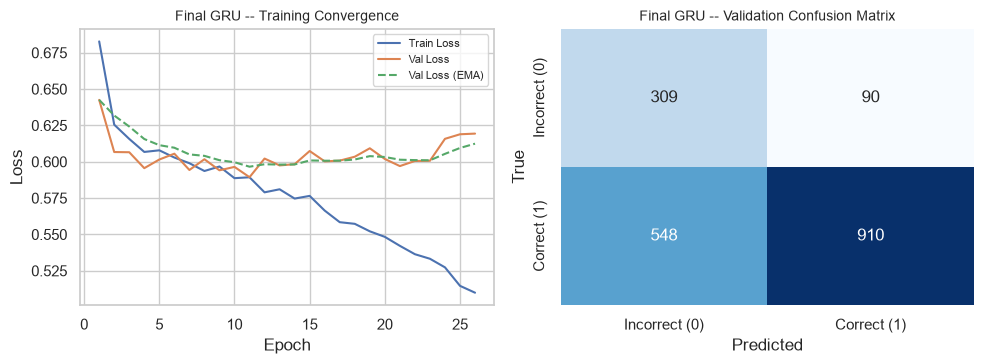

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
plot_training_curves(gru_final_train_losses, gru_final_val_losses, gru_final_val_loss_emas,
                      title='Final GRU -- Training Convergence', ax=axes[0])
plot_confusion_matrix(gru_final_val_metrics['confusion_matrix'],
                       title='Final GRU -- Validation Confusion Matrix', ax=axes[1])
fig.tight_layout()
plt.show()

In [16]:
gru_final_test_loader = create_dataloader(test_df, features, batch_size=selected_gru_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

gru_final_test_metrics = evaluate_model(gru_final_model, gru_final_test_loader, gru_final_criterion, gru_final_device)

print("=== Final GRU Model -- Test Set Evaluation ===")
print(f"Test Loss:        {gru_final_test_metrics['loss']:.4f}")
print(f"Test Macro F1:    {gru_final_test_metrics['macro_f1']:.4f}")
print(f"Test F1 (class0): {gru_final_test_metrics['f1_class0']:.4f}")
print(f"Test F1 (class1): {gru_final_test_metrics['f1_class1']:.4f}")
print(f"Test ROC-AUC:     {gru_final_test_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(gru_final_test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))


=== Final GRU Model -- Test Set Evaluation ===
Test Loss:        0.6227
Test Macro F1:    0.6003
Test F1 (class0): 0.4820
Test F1 (class1): 0.7185
Test ROC-AUC:     0.7146
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     315     132
True 1     545     864


### Section 4e: Final GRU Model -- Test Confusion Matrix

We output the final GRU model's test-set confusion matrix (`gru_final_test_metrics['confusion_matrix']`, computed in the cell above) as a heatmap instead.

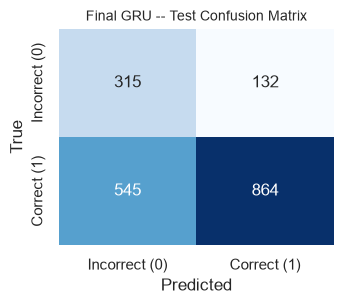

In [17]:
plot_confusion_matrix(gru_final_test_metrics['confusion_matrix'],
                       title='Final GRU -- Test Confusion Matrix')

### Section 4f: Data Ablation 1 (GRU) on Fixations vs. Saccades

We split analysis where (`eventType == 1` for fixations-only, `eventType == 0` for saccades-only, applied before the trial-grouping step), same reused scaler, retraining GRU's exact architecture and hyperparameters (`selected_gru_hp`) unchanged. Only sequence length is the only variable that changes (each trial keeps roughly half its rows), and since `selected_gru_hp` has no dependency on sequence length, nothing else needs to be adjusted. The existing `gru_final_*` model is already the "both events" condition, so this experiment needs two new training runs.

#### Section 4fa: Data Ablation 1 (GRU) - Event Type Isolation

We conduct ablation study to determine whether the GRU model relies more heavily on **fixations** (when the eye is relatively still and processing information) or **saccades** (the rapid movements between fixations) to predict cognitive performance.

1. **Data Filtering**: We filter the train, validation, and test datasets to isolate the specific event types into two separate conditions: `fixations_only` and `saccades_only`.
2. **Pipeline Reset**: This recreates the DataLoaders for each condition from scratch. As noted in the code comments, this prevents the PyTorch random generator from drifting out of sync between conditions, ensuring strict reproducibility. Class weights are also dynamically recalculated for the filtered sets.
3. **Deterministic Retraining**: This calls `set_seed(69)` before initializing a fresh GRU model with the previously discovered optimal hyperparameters (`selected_gru_hp`). The model is then trained from scratch on the ablated dataset.
4. **Comparative Summary**: We evaluate the isolated models on the validation set and aggregates the results into a  DataFrame, comparing the performance of `fixations_only` and `saccades_only` against the original `both_events_baseline`.

In [18]:
GRU_EVENT_TYPE_CONDITIONS = {'fixations_only': 1, 'saccades_only': 0}

gru_event_results = {}
for name, event_value in GRU_EVENT_TYPE_CONDITIONS.items():
    print(f"\n{'=' * 80}\nData Ablation 1 (GRU) -- {name} (eventType == {event_value})\n{'=' * 80}")

    cond_train_df = train_df[train_df['eventType'] == event_value]
    cond_val_df = val_df[val_df['eventType'] == event_value]
    cond_test_df = test_df[test_df['eventType'] == event_value]

    cond_train_loader = create_dataloader(cond_train_df, features, batch_size=selected_gru_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
    cond_val_loader = create_dataloader(cond_val_df, features, batch_size=selected_gru_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)
    cond_test_loader = create_dataloader(cond_test_df, features, batch_size=selected_gru_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

    print(f"Trials: train={len(cond_train_loader.dataset)}, val={len(cond_val_loader.dataset)}, test={len(cond_test_loader.dataset)} "
          f"(baseline both-events: train={len(gru_final_train_loader.dataset)}, val={len(gru_final_val_loader.dataset)}, "
          f"test={len(gru_final_test_loader.dataset)})")

    cond_train_labels = np.array([label for _, label, _ in cond_train_loader.dataset])
    cond_class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(cond_train_labels), y=cond_train_labels)
    cond_class_weights_tensor = torch.tensor(cond_class_weights, dtype=torch.float32).to(gru_final_device)
    cond_criterion = nn.CrossEntropyLoss(weight=cond_class_weights_tensor)

    set_seed(69)
    cond_model = EyeMovementGRU(
        n_features=N_FEATURES,
        hidden_dim=selected_gru_hp['hidden_dim'],
        num_layers=selected_gru_hp['num_layers'],
        num_fc_layers=selected_gru_hp['num_fc_layers'],
        fc_hidden_size=selected_gru_hp['fc_hidden_size'],
        rnn_dropout=selected_gru_hp['rnn_dropout'],
        fc_dropout=selected_gru_hp['fc_dropout'],
    ).to(gru_final_device)

    cond_optimizer = optim.Adam(cond_model.parameters(), lr=selected_gru_hp['learning_rate'])

    cond_model, cond_best_val_loss, cond_train_losses, cond_val_losses, cond_val_loss_emas = train_with_early_stopping(
        cond_model, cond_train_loader, cond_val_loader, cond_optimizer, cond_criterion, gru_final_device,
        max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
    )

    cond_val_metrics = evaluate_model(cond_model, cond_val_loader, cond_criterion, gru_final_device)
    gru_event_results[name] = {
        'model': cond_model, 'criterion': cond_criterion, 'test_loader': cond_test_loader, 'val_metrics': cond_val_metrics,
    }

    print(f"Val Loss:        {cond_val_metrics['loss']:.4f}")
    print(f"Val Macro F1:    {cond_val_metrics['macro_f1']:.4f}")
    print(f"Val F1 (class0): {cond_val_metrics['f1_class0']:.4f}")
    print(f"Val F1 (class1): {cond_val_metrics['f1_class1']:.4f}")
    print(f"Val ROC-AUC:     {cond_val_metrics['roc_auc']:.4f}")
    print("Confusion Matrix (rows=true, cols=pred):")
    print(pd.DataFrame(cond_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Data Ablation 1 (GRU): Validation Summary (vs. the final model's both-events baseline) ===")
gru_event_val_rows = {
    name: {
        'val_loss': r['val_metrics']['loss'],
        'val_macro_f1': r['val_metrics']['macro_f1'],
        'val_f1_class0': r['val_metrics']['f1_class0'],
        'val_f1_class1': r['val_metrics']['f1_class1'],
        'val_roc_auc': r['val_metrics']['roc_auc'],
    }
    for name, r in gru_event_results.items()
}
gru_event_val_rows['both_events_baseline'] = {
    'val_loss': gru_final_val_metrics['loss'],
    'val_macro_f1': gru_final_val_metrics['macro_f1'],
    'val_f1_class0': gru_final_val_metrics['f1_class0'],
    'val_f1_class1': gru_final_val_metrics['f1_class1'],
    'val_roc_auc': gru_final_val_metrics['roc_auc'],
}
gru_event_val_summary = pd.DataFrame(gru_event_val_rows).T
display(gru_event_val_summary)



Data Ablation 1 (GRU) -- fixations_only (eventType == 1)
Trials: train=5465, val=1857, test=1855 (baseline both-events: train=5465, val=1857, test=1856)
Epoch   1/200 | train_loss=0.6822 | val_loss=0.6380 | val_loss_ema=0.6380
Epoch   2/200 | train_loss=0.6282 | val_loss=0.6099 | val_loss_ema=0.6295
Epoch   3/200 | train_loss=0.6148 | val_loss=0.6073 | val_loss_ema=0.6229
Epoch   4/200 | train_loss=0.6068 | val_loss=0.5985 | val_loss_ema=0.6156
Epoch   5/200 | train_loss=0.6077 | val_loss=0.6040 | val_loss_ema=0.6121
Epoch   6/200 | train_loss=0.6056 | val_loss=0.6045 | val_loss_ema=0.6098
Epoch   7/200 | train_loss=0.6000 | val_loss=0.6028 | val_loss_ema=0.6077
Epoch   8/200 | train_loss=0.5958 | val_loss=0.6083 | val_loss_ema=0.6079
Epoch   9/200 | train_loss=0.5960 | val_loss=0.5980 | val_loss_ema=0.6049
Epoch  10/200 | train_loss=0.5917 | val_loss=0.5980 | val_loss_ema=0.6028
Epoch  11/200 | train_loss=0.5894 | val_loss=0.5968 | val_loss_ema=0.6010
Epoch  12/200 | train_loss=0.578

,val_loss,val_macro_f1,val_f1_class0,val_f1_class1,val_roc_auc
fixations_only,0.5919,0.6161,0.4853,0.7470,0.7529
saccades_only,0.5888,0.6009,0.4852,0.7165,0.7494
both_events_baseline,0.5894,0.6162,0.4920,0.7404,0.7512


#### Section 4fb: Data Ablation 1 (GRU) - Test Set Evaluation

This block evaluates the event-isolated models trained in the previous step on the completely unseen test set to see how well the findings generalize.

1. **Test Evaluation**: Iterates through the models stored in `gru_event_results` (fixations only and saccades only) and evaluates them using their respective withheld test DataLoaders.
2. **Metric Output**: This prints the detailed test metrics (Loss, Macro F1, ROC-AUC) and confusion matrix for each ablated condition.
3. **Test Summary Comparison**: Aggregates the test results into a Pandas DataFrame, placing them side-by-side with the baseline model's test performance (`both_events_baseline`). We compare whether the model truly generalizes better to unseen subjects when restricted to a specific type of eye movement, or if it needs both to achieve maximum accuracy.

In [19]:
for name, r in gru_event_results.items():
    test_metrics = evaluate_model(r['model'], r['test_loader'], r['criterion'], gru_final_device)
    r['test_metrics'] = test_metrics

    print(f"\nData Ablation 1 (GRU) -- {name} -- Test Set Evaluation")
    print(f"Test Loss:        {test_metrics['loss']:.4f}")
    print(f"Test Macro F1:    {test_metrics['macro_f1']:.4f}")
    print(f"Test F1 (class0): {test_metrics['f1_class0']:.4f}")
    print(f"Test F1 (class1): {test_metrics['f1_class1']:.4f}")
    print(f"Test ROC-AUC:     {test_metrics['roc_auc']:.4f}")
    print("Confusion Matrix (rows=true, cols=pred):")
    print(pd.DataFrame(test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Data Ablation 1 (GRU): Test Summary (vs. the final model's both-events baseline) ===")
gru_event_test_rows = {
    name: {
        'test_loss': r['test_metrics']['loss'],
        'test_macro_f1': r['test_metrics']['macro_f1'],
        'test_f1_class0': r['test_metrics']['f1_class0'],
        'test_f1_class1': r['test_metrics']['f1_class1'],
        'test_roc_auc': r['test_metrics']['roc_auc'],
    }
    for name, r in gru_event_results.items()
}
gru_event_test_rows['both_events_baseline'] = {
    'test_loss': gru_final_test_metrics['loss'],
    'test_macro_f1': gru_final_test_metrics['macro_f1'],
    'test_f1_class0': gru_final_test_metrics['f1_class0'],
    'test_f1_class1': gru_final_test_metrics['f1_class1'],
    'test_roc_auc': gru_final_test_metrics['roc_auc'],
}
gru_event_test_summary = pd.DataFrame(gru_event_test_rows).T
display(gru_event_test_summary)



Data Ablation 1 (GRU) -- fixations_only -- Test Set Evaluation
Test Loss:        0.6590
Test Macro F1:    0.6048
Test F1 (class0): 0.4791
Test F1 (class1): 0.7305
Test ROC-AUC:     0.7074
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     303     143
True 1     516     893

Data Ablation 1 (GRU) -- saccades_only -- Test Set Evaluation
Test Loss:        0.6494
Test Macro F1:    0.5985
Test F1 (class0): 0.4912
Test F1 (class1): 0.7058
Test ROC-AUC:     0.7059
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     334     113
True 1     579     830

=== Data Ablation 1 (GRU): Test Summary (vs. the final model's both-events baseline) ===


,test_loss,test_macro_f1,test_f1_class0,test_f1_class1,test_roc_auc
fixations_only,0.6590,0.6048,0.4791,0.7305,0.7074
saccades_only,0.6494,0.5985,0.4912,0.7058,0.7059
both_events_baseline,0.6227,0.6003,0.4820,0.7185,0.7146


### Section 4g: Data Ablation 2 (GRU) on Coordinate-Free Features

This is 9-of-15 coordinate-free feature set of this ablation (using `features_no_coords`/`N_FEATURES_NO_COORDS` computed there). GRU's architecture-defining
hyperparameters (`hidden_dim`, `num_layers`, `fc_hidden_size`) have no dependency on `n_features` at all -- only `nn.GRU`'s `input_size` changes. `selected_gru_hp` therefore
carries over completely unchanged; only the feature list and the resulting `n_features` passed into the model differ from the final model.

#### Section 4ga: Data Ablation 2 (GRU) - Validation on the Coordinate-Free Feature Set

We retrain GRU's exact architecture (`selected_gru_hp`, unchanged) on the coordinate-free feature set introduced above, and evaluates it on the validation set.

1. **Dataloader Rebuild**: We recreate the train/val/test DataLoaders using `features_no_coords` (9 features) instead of the full `features` list (15 features), with `selected_gru_hp['batch_size']` and `MAX_SEQ_LEN` unchanged.
2. **Class Weight Recalculation**: Recomputes balanced class weights from the (feature-reduced, but subject-identical) training labels, since removing coordinate columns doesn't change trial-level labels or their distribution.
3. **Deterministic Retraining**: This calls `set_seed(69)` before instantiating a fresh `EyeMovementGRU` with `n_features=N_FEATURES_NO_COORDS`, where the only architecture-defining hyperparameter that changes is `nn.GRU`'s `input_size`, since `hidden_dim`/`num_layers`/`fc_hidden_size` carry no dependency on feature count.
4. **Validation Comparison**: We print the coordinate-free model's validation metrics directly alongside the 15-feature final GRU model's (`gru_final_val_metrics`) for a side-by-side reading.

In [20]:
print(f"Coordinate-free feature set ({N_FEATURES_NO_COORDS} features): {features_no_coords}")

gru_coordfree_train_loader = create_dataloader(train_df, features_no_coords, batch_size=selected_gru_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
gru_coordfree_val_loader = create_dataloader(val_df, features_no_coords, batch_size=selected_gru_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)
gru_coordfree_test_loader = create_dataloader(test_df, features_no_coords, batch_size=selected_gru_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

gru_coordfree_train_labels = np.array([label for _, label, _ in gru_coordfree_train_loader.dataset])
gru_coordfree_class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(gru_coordfree_train_labels), y=gru_coordfree_train_labels
)
gru_coordfree_class_weights_tensor = torch.tensor(gru_coordfree_class_weights, dtype=torch.float32).to(gru_final_device)
gru_coordfree_criterion = nn.CrossEntropyLoss(weight=gru_coordfree_class_weights_tensor)

set_seed(69)
gru_coordfree_model = EyeMovementGRU(
    n_features=N_FEATURES_NO_COORDS,
    hidden_dim=selected_gru_hp['hidden_dim'],
    num_layers=selected_gru_hp['num_layers'],
    num_fc_layers=selected_gru_hp['num_fc_layers'],
    fc_hidden_size=selected_gru_hp['fc_hidden_size'],
    rnn_dropout=selected_gru_hp['rnn_dropout'],
    fc_dropout=selected_gru_hp['fc_dropout'],
).to(gru_final_device)

gru_coordfree_optimizer = optim.Adam(gru_coordfree_model.parameters(), lr=selected_gru_hp['learning_rate'])

gru_coordfree_model, gru_coordfree_best_val_loss, gru_coordfree_train_losses, gru_coordfree_val_losses, gru_coordfree_val_loss_emas = train_with_early_stopping(
    gru_coordfree_model, gru_coordfree_train_loader, gru_coordfree_val_loader, gru_coordfree_optimizer, gru_coordfree_criterion, gru_final_device,
    max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
)

gru_coordfree_val_metrics = evaluate_model(gru_coordfree_model, gru_coordfree_val_loader, gru_coordfree_criterion, gru_final_device)

print(f"\nData Ablation 2 (GRU, {N_FEATURES_NO_COORDS} features) -- Validation")
print(f"Val Loss:        {gru_coordfree_val_metrics['loss']:.4f}")
print(f"Val Macro F1:    {gru_coordfree_val_metrics['macro_f1']:.4f}")
print(f"Val F1 (class0): {gru_coordfree_val_metrics['f1_class0']:.4f}")
print(f"Val F1 (class1): {gru_coordfree_val_metrics['f1_class1']:.4f}")
print(f"Val ROC-AUC:     {gru_coordfree_val_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(gru_coordfree_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print(f"\nFor comparison, final GRU model (15 features): val macro F1={gru_final_val_metrics['macro_f1']:.4f}, "
      f"val F1 class0={gru_final_val_metrics['f1_class0']:.4f}, val ROC-AUC={gru_final_val_metrics['roc_auc']:.4f}")


Coordinate-free feature set (9 features): ['eventType', 'timeSinceStart', 'eye', 'duration', 'meanPupilDiameter', 'microsaccadeCount', 'microsaccadeAmplitude', 'microsaccadePeakVelocity', 'saccadeAmplitude']
Epoch   1/200 | train_loss=0.6759 | val_loss=0.6067 | val_loss_ema=0.6067
Epoch   2/200 | train_loss=0.6278 | val_loss=0.6044 | val_loss_ema=0.6060
Epoch   3/200 | train_loss=0.6115 | val_loss=0.5982 | val_loss_ema=0.6036
Epoch   4/200 | train_loss=0.6115 | val_loss=0.5986 | val_loss_ema=0.6021
Epoch   5/200 | train_loss=0.6130 | val_loss=0.5965 | val_loss_ema=0.6004
Epoch   6/200 | train_loss=0.6073 | val_loss=0.5979 | val_loss_ema=0.5997
Epoch   7/200 | train_loss=0.6030 | val_loss=0.6017 | val_loss_ema=0.6003
Epoch   8/200 | train_loss=0.6042 | val_loss=0.6046 | val_loss_ema=0.6016
Epoch   9/200 | train_loss=0.5994 | val_loss=0.5946 | val_loss_ema=0.5995
Epoch  10/200 | train_loss=0.6043 | val_loss=0.5979 | val_loss_ema=0.5990
Epoch  11/200 | train_loss=0.6010 | val_loss=0.5975 

#### Section 4gb: Data Ablation 2 (GRU) - Test Set Evaluation

We evaluate the already-trained coordinate-free GRU model (`gru_coordfree_model`) on its held-out test set.

1. **Test Evaluation**: Runs `evaluate_model` on `gru_coordfree_test_loader`, reusing the model, criterion, and device from the previous cell.
2. **Metric Output**: We print the full test metric suite (Loss, Macro F1, per-class F1, ROC-AUC) and confusion matrix.
3. **Baseline Comparison**: Additionally, we also output the 15-feature final GRU model's test metrics (`gru_final_test_metrics`) alongside, so the coordinate-free result can be read directly against the full-feature baseline.

In [21]:
gru_coordfree_test_metrics = evaluate_model(gru_coordfree_model, gru_coordfree_test_loader, gru_coordfree_criterion, gru_final_device)

print(f"Data Ablation 2 (GRU, {N_FEATURES_NO_COORDS} features) -- Test Set Evaluation")
print(f"Test Loss:        {gru_coordfree_test_metrics['loss']:.4f}")
print(f"Test Macro F1:    {gru_coordfree_test_metrics['macro_f1']:.4f}")
print(f"Test F1 (class0): {gru_coordfree_test_metrics['f1_class0']:.4f}")
print(f"Test F1 (class1): {gru_coordfree_test_metrics['f1_class1']:.4f}")
print(f"Test ROC-AUC:     {gru_coordfree_test_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(gru_coordfree_test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print(f"\nFor comparison, final GRU model (15 features): test macro F1={gru_final_test_metrics['macro_f1']:.4f}, "
      f"test F1 class0={gru_final_test_metrics['f1_class0']:.4f}, test ROC-AUC={gru_final_test_metrics['roc_auc']:.4f}")


Data Ablation 2 (GRU, 9 features) -- Test Set Evaluation
Test Loss:        0.6114
Test Macro F1:    0.5896
Test F1 (class0): 0.4937
Test F1 (class1): 0.6856
Test ROC-AUC:     0.7170
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     351      96
True 1     624     785

For comparison, final GRU model (15 features): test macro F1=0.6003, test F1 class0=0.4820, test ROC-AUC=0.7146


### Section 4h: Data Ablation 3 (GRU) with Per-Task Specialization

Same per-block training as proposed: one model per task block (Series Continuation, Classifications, Matrices, Topological Conclusions), each using GRU's selected architecture (`selected_gru_hp`) but only that block's trials. The generalist's comparison numbers are recomputed *per block* here by re-scoring the already-trained `gru_final_model` on each block's own val/test subset, not its overall aggregate metrics, as comparing a specialist's block-specific performance against the generalist's overall performance would compare different populations.

#### Section 4ha: Data Ablation 3 (GRU) - Per-Block Training and Validation

This cell trains one GRU specialist per task block (`block_1` through `block_4` -- Series Continuation, Classifications, Matrices, and Topological Conclusions), then compares each specialist against the already-trained generalist (`gru_final_model`) re-scored on that same block's validation subset.

1. **Per-Block Data Filtering**: This restricts the train/val/test DataFrames to rows belonging to a single task block before rebuilding DataLoaders, mirroring we implemented reproducibility in Data Ablation 1 (fresh DataLoaders every iteration, since a shared shuffling generator would drift across blocks).
2. **Specialist Training**: We reinitialize `EyeMovementGRU` with GRU's selected hyperparameters (`selected_gru_hp`) and trains it from scratch on only that block's trials, with its own from-scratch balanced class weights.
3. **Generalist Re-Scoring**: Evaluates the existing `gru_final_model` (trained on all four blocks) on this block's validation subset only, so the specialist-vs-generalist comparison is apples-to-apples (the generalist's overall aggregate metrics would mix in the other three blocks and wouldn't answer the question).
4. **Per-Block Results Storage & Summary**: This stores both models' metrics per block in `gru_task_results`, then tabulates every block's specialist and generalist validation metrics side by side in a single summary DataFrame.

In [22]:
gru_task_results = {}
for block in TASK_BLOCKS:
    print(f"\n{'=' * 80}\nData Ablation 3 (GRU) -- {block}\n{'=' * 80}")

    block_train_df = train_df[train_df[block] == 1]
    block_val_df = val_df[val_df[block] == 1]
    block_test_df = test_df[test_df[block] == 1]

    block_train_loader = create_dataloader(block_train_df, features, batch_size=selected_gru_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
    block_val_loader = create_dataloader(block_val_df, features, batch_size=selected_gru_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)
    block_test_loader = create_dataloader(block_test_df, features, batch_size=selected_gru_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

    print(f"Trials: train={len(block_train_loader.dataset)}, val={len(block_val_loader.dataset)}, test={len(block_test_loader.dataset)}")

    block_train_labels = np.array([label for _, label, _ in block_train_loader.dataset])
    block_class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(block_train_labels), y=block_train_labels)
    block_class_weights_tensor = torch.tensor(block_class_weights, dtype=torch.float32).to(gru_final_device)
    block_criterion = nn.CrossEntropyLoss(weight=block_class_weights_tensor)

    set_seed(69)
    block_model = EyeMovementGRU(
        n_features=N_FEATURES,
        hidden_dim=selected_gru_hp['hidden_dim'],
        num_layers=selected_gru_hp['num_layers'],
        num_fc_layers=selected_gru_hp['num_fc_layers'],
        fc_hidden_size=selected_gru_hp['fc_hidden_size'],
        rnn_dropout=selected_gru_hp['rnn_dropout'],
        fc_dropout=selected_gru_hp['fc_dropout'],
    ).to(gru_final_device)

    block_optimizer = optim.Adam(block_model.parameters(), lr=selected_gru_hp['learning_rate'])

    block_model, block_best_val_loss, block_train_losses, block_val_losses, block_val_loss_emas = train_with_early_stopping(
        block_model, block_train_loader, block_val_loader, block_optimizer, block_criterion, gru_final_device,
        max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
    )

    block_val_metrics = evaluate_model(block_model, block_val_loader, block_criterion, gru_final_device)

    # Generalist comparison: the already-trained final GRU model, re-scored on this block's
    # val subset only -- NOT its overall aggregate metrics, which would be a different population.
    general_block_val_metrics = evaluate_model(gru_final_model, block_val_loader, gru_final_criterion, gru_final_device)

    gru_task_results[block] = {
        'model': block_model, 'criterion': block_criterion, 'test_loader': block_test_loader,
        'specialist_val_metrics': block_val_metrics, 'general_val_metrics': general_block_val_metrics,
    }

    print(f"Specialist -- Val Loss: {block_val_metrics['loss']:.4f} | Val Macro F1: {block_val_metrics['macro_f1']:.4f} | "
          f"Val F1 class0: {block_val_metrics['f1_class0']:.4f} | Val F1 class1: {block_val_metrics['f1_class1']:.4f} | "
          f"Val ROC-AUC: {block_val_metrics['roc_auc']:.4f}")
    print(f"Generalist (scored on this block only) -- Val Macro F1: {general_block_val_metrics['macro_f1']:.4f} | "
          f"Val F1 class0: {general_block_val_metrics['f1_class0']:.4f} | Val F1 class1: {general_block_val_metrics['f1_class1']:.4f} | "
          f"Val ROC-AUC: {general_block_val_metrics['roc_auc']:.4f}")
    print("Specialist Confusion Matrix (rows=true, cols=pred):")
    print(pd.DataFrame(block_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Data Ablation 3 (GRU): Validation Summary -- Specialist vs. Generalist per Block ===")
gru_task_val_rows = {}
for block, r in gru_task_results.items():
    gru_task_val_rows[f"{block}_specialist"] = {
        'val_macro_f1': r['specialist_val_metrics']['macro_f1'],
        'val_f1_class0': r['specialist_val_metrics']['f1_class0'],
        'val_f1_class1': r['specialist_val_metrics']['f1_class1'],
        'val_roc_auc': r['specialist_val_metrics']['roc_auc'],
    }
    gru_task_val_rows[f"{block}_generalist"] = {
        'val_macro_f1': r['general_val_metrics']['macro_f1'],
        'val_f1_class0': r['general_val_metrics']['f1_class0'],
        'val_f1_class1': r['general_val_metrics']['f1_class1'],
        'val_roc_auc': r['general_val_metrics']['roc_auc'],
    }
gru_task_val_summary = pd.DataFrame(gru_task_val_rows).T
display(gru_task_val_summary)



Data Ablation 3 (GRU) -- block_1
Trials: train=1540, val=524, test=519
Epoch   1/200 | train_loss=0.6912 | val_loss=0.6857 | val_loss_ema=0.6857
Epoch   2/200 | train_loss=0.6779 | val_loss=0.6559 | val_loss_ema=0.6767
Epoch   3/200 | train_loss=0.6479 | val_loss=0.6017 | val_loss_ema=0.6542
Epoch   4/200 | train_loss=0.6256 | val_loss=0.5878 | val_loss_ema=0.6343
Epoch   5/200 | train_loss=0.5991 | val_loss=0.6066 | val_loss_ema=0.6260
Epoch   6/200 | train_loss=0.5873 | val_loss=0.6209 | val_loss_ema=0.6245
Epoch   7/200 | train_loss=0.5840 | val_loss=0.5915 | val_loss_ema=0.6146
Epoch   8/200 | train_loss=0.5724 | val_loss=0.5896 | val_loss_ema=0.6071
Epoch   9/200 | train_loss=0.5542 | val_loss=0.6086 | val_loss_ema=0.6075
Epoch  10/200 | train_loss=0.5616 | val_loss=0.5992 | val_loss_ema=0.6050
Epoch  11/200 | train_loss=0.5660 | val_loss=0.5820 | val_loss_ema=0.5981
Epoch  12/200 | train_loss=0.5513 | val_loss=0.5961 | val_loss_ema=0.5975
Epoch  13/200 | train_loss=0.5420 | val_

,val_macro_f1,val_f1_class0,val_f1_class1,val_roc_auc
block_1_specialist,0.5730,0.3676,0.7784,0.7724
block_1_generalist,0.5859,0.3852,0.7866,0.7678
block_2_specialist,0.6908,0.5567,0.8250,0.8193
block_2_generalist,0.6398,0.5269,0.7526,0.7787
block_3_specialist,0.6001,0.4393,0.7608,0.7773
block_3_generalist,0.5887,0.4097,0.7678,0.7021
block_4_specialist,0.5369,0.5249,0.5489,0.5702
block_4_generalist,0.5571,0.6087,0.5055,0.6619


#### Section 4hb: Data Ablation 3 (GRU) - Test Set Evaluation

We evaluate every block's specialist and re-scored generalist from the previous cell on that block's held-out test subset .

1. **Per-Block Test Evaluation**: For each of the four task blocks, we evaluate both the block's specialist model and the generalist model (`gru_final_model`) on that block's own `test_loader`.
2. **Metric Output**: This prints Macro F1, per-class F1, and ROC-AUC for both models per block, plus the specialist's confusion matrix.
3. **Test Summary Comparison**: We show every block's specialist-vs-generalist test metrics into one summary DataFrame.

In [23]:
for block, r in gru_task_results.items():
    specialist_test_metrics = evaluate_model(r['model'], r['test_loader'], r['criterion'], gru_final_device)
    general_test_metrics = evaluate_model(gru_final_model, r['test_loader'], gru_final_criterion, gru_final_device)
    r['specialist_test_metrics'] = specialist_test_metrics
    r['general_test_metrics'] = general_test_metrics

    print(f"\nData Ablation 3 (GRU) -- {block} -- Test Set Evaluation")
    print(f"Specialist -- Test Macro F1: {specialist_test_metrics['macro_f1']:.4f} | "
          f"Test F1 class0: {specialist_test_metrics['f1_class0']:.4f} | "
          f"Test F1 class1: {specialist_test_metrics['f1_class1']:.4f} | "
          f"Test ROC-AUC: {specialist_test_metrics['roc_auc']:.4f}")
    print(f"Generalist (scored on this block only) -- Test Macro F1: {general_test_metrics['macro_f1']:.4f} | "
          f"Test F1 class0: {general_test_metrics['f1_class0']:.4f} | "
          f"Test F1 class1: {general_test_metrics['f1_class1']:.4f} | "
          f"Test ROC-AUC: {general_test_metrics['roc_auc']:.4f}")
    print("Specialist Confusion Matrix (rows=true, cols=pred):")
    print(pd.DataFrame(specialist_test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Data Ablation 3 (GRU): Test Summary -- Specialist vs. Generalist per Block ===")
gru_task_test_rows = {}
for block, r in gru_task_results.items():
    gru_task_test_rows[f"{block}_specialist"] = {
        'test_macro_f1': r['specialist_test_metrics']['macro_f1'],
        'test_f1_class0': r['specialist_test_metrics']['f1_class0'],
        'test_f1_class1': r['specialist_test_metrics']['f1_class1'],
        'test_roc_auc': r['specialist_test_metrics']['roc_auc'],
    }
    gru_task_test_rows[f"{block}_generalist"] = {
        'test_macro_f1': r['general_test_metrics']['macro_f1'],
        'test_f1_class0': r['general_test_metrics']['f1_class0'],
        'test_f1_class1': r['general_test_metrics']['f1_class1'],
        'test_roc_auc': r['general_test_metrics']['roc_auc'],
    }
gru_task_test_summary = pd.DataFrame(gru_task_test_rows).T
display(gru_task_test_summary)



Data Ablation 3 (GRU) -- block_1 -- Test Set Evaluation
Specialist -- Test Macro F1: 0.5617 | Test F1 class0: 0.3472 | Test F1 class1: 0.7762 | Test ROC-AUC: 0.6606
Generalist (scored on this block only) -- Test Macro F1: 0.5521 | Test F1 class0: 0.3200 | Test F1 class1: 0.7843 | Test ROC-AUC: 0.6828
Specialist Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0      46      36
True 1     137     300

Data Ablation 3 (GRU) -- block_2 -- Test Set Evaluation
Specialist -- Test Macro F1: 0.7074 | Test F1 class0: 0.5969 | Test F1 class1: 0.8178 | Test ROC-AUC: 0.7690
Generalist (scored on this block only) -- Test Macro F1: 0.6339 | Test F1 class0: 0.5539 | Test F1 class1: 0.7138 | Test ROC-AUC: 0.7348
Specialist Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0      97      49
True 1      82     294

Data Ablation 3 (GRU) -- block_3 -- Test Set Evaluation
Specialist -- Test Macro F1: 0.6727 | Test F1 class0: 0.5664 | Test F1 class1: 0.7789 | Test RO

,test_macro_f1,test_f1_class0,test_f1_class1,test_roc_auc
block_1_specialist,0.5617,0.3472,0.7762,0.6606
block_1_generalist,0.5521,0.3200,0.7843,0.6828
block_2_specialist,0.7074,0.5969,0.8178,0.7690
block_2_generalist,0.6339,0.5539,0.7138,0.7348
block_3_specialist,0.6727,0.5664,0.7789,0.7983
block_3_generalist,0.6255,0.4890,0.7620,0.7325
block_4_specialist,0.5140,0.4565,0.5714,0.5611
block_4_generalist,0.4809,0.5091,0.4527,0.6194


### Section 4i: GRU + Attention Hyperparameter Tuning with 30-Trial Random Search

We explore a dedicated 30-trial search for GRU + Attention, mirroring the linear_per_timestep-specific search's methodology exactly: same train/val split, same class weighting, same early-stopping settings (`TUNING_MAX_EPOCHS`/`TUNING_PATIENCE`/`TUNING_MIN_DELTA`, `MAX_SEQ_LEN`), same `batch_size=32` OOM margin, and selection by validation loss only. The winning configuration is stored into `selected_gru_attn_hp` below.

In [24]:
def sample_gru_attn_trial_hyperparameters(rng):
    hidden_dim = rng.choice([64, 128, 256])
    num_layers = rng.choice([1, 2, 3])
    rnn_dropout = rng.choice([0.0, 0.2, 0.3]) if num_layers > 1 else 0.0

    attn_dim = rng.choice([hidden_dim, hidden_dim // 2, 32])

    num_fc_layers = rng.choice([1, 2, 3])
    fc_hidden_size = rng.choice([hidden_dim, hidden_dim // 2])
    fc_dropout = rng.choice([0.2, 0.3, 0.5])

    learning_rate = 0.001
    batch_size = 128

    return {
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'rnn_dropout': rnn_dropout,
        'attn_dim': attn_dim,
        'num_fc_layers': num_fc_layers,
        'fc_hidden_size': fc_hidden_size,
        'fc_dropout': fc_dropout,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
    }


NUM_GRU_ATTN_TRIALS = 30
gru_attn_sampling_rng = random.Random(69)

gru_attn_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gru_attn_trial_results = []

for trial_idx in range(1, NUM_GRU_ATTN_TRIALS + 1):
    hp = sample_gru_attn_trial_hyperparameters(gru_attn_sampling_rng)
    print(f"\n{'=' * 80}\nGRU + Attention Trial {trial_idx}/{NUM_GRU_ATTN_TRIALS}: {hp}\n{'=' * 80}")

    set_seed(69)

    gru_attn_trial_train_loader = create_dataloader(train_df, features, batch_size=hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
    gru_attn_trial_val_loader = create_dataloader(val_df, features, batch_size=hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

    gru_attn_trial_train_labels = np.array([label for _, label, _ in gru_attn_trial_train_loader.dataset])
    gru_attn_trial_class_weights = compute_class_weight(
        class_weight='balanced', classes=np.unique(gru_attn_trial_train_labels), y=gru_attn_trial_train_labels
    )
    gru_attn_trial_class_weights_tensor = torch.tensor(gru_attn_trial_class_weights, dtype=torch.float32).to(gru_attn_device)
    gru_attn_trial_criterion = nn.CrossEntropyLoss(weight=gru_attn_trial_class_weights_tensor)

    gru_attn_trial_model = EyeMovementGRUAttention(
        n_features=N_FEATURES,
        hidden_dim=hp['hidden_dim'],
        num_layers=hp['num_layers'],
        attn_dim=hp['attn_dim'],
        num_fc_layers=hp['num_fc_layers'],
        fc_hidden_size=hp['fc_hidden_size'],
        rnn_dropout=hp['rnn_dropout'],
        fc_dropout=hp['fc_dropout'],
    ).to(gru_attn_device)

    gru_attn_trial_optimizer = optim.Adam(gru_attn_trial_model.parameters(), lr=hp['learning_rate'])

    gru_attn_trial_model, gru_attn_trial_best_val_loss, gru_attn_trial_train_losses, gru_attn_trial_val_losses, gru_attn_trial_val_loss_emas = train_with_early_stopping(
        gru_attn_trial_model, gru_attn_trial_train_loader, gru_attn_trial_val_loader, gru_attn_trial_optimizer, gru_attn_trial_criterion, gru_attn_device,
        max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
    )

    gru_attn_trial_val_metrics = evaluate_model(gru_attn_trial_model, gru_attn_trial_val_loader, gru_attn_trial_criterion, gru_attn_device)

    print(f"Trial {trial_idx} result: best_val_loss={gru_attn_trial_best_val_loss:.4f} | epochs_run={len(gru_attn_trial_train_losses)} | "
          f"val_macro_f1={gru_attn_trial_val_metrics['macro_f1']:.4f} | val_roc_auc={gru_attn_trial_val_metrics['roc_auc']:.4f}")

    gru_attn_trial_results.append({
        'trial': trial_idx,
        **hp,
        'best_val_loss': gru_attn_trial_best_val_loss,
        'epochs_run': len(gru_attn_trial_train_losses),
        'val_macro_f1': gru_attn_trial_val_metrics['macro_f1'],
        'val_f1_class0': gru_attn_trial_val_metrics['f1_class0'],
        'val_f1_class1': gru_attn_trial_val_metrics['f1_class1'],
        'val_roc_auc': gru_attn_trial_val_metrics['roc_auc'],
    })

    gru_attn_trial_model.cpu()
    del gru_attn_trial_model, gru_attn_trial_optimizer
    gc.collect()
    torch.cuda.empty_cache()

gru_attn_trial_results_df = pd.DataFrame(gru_attn_trial_results).sort_values('trial').reset_index(drop=True)
print("\n=== GRU + Attention 30-Trial Search: Top 10 by Validation Loss ===")
pd.set_option('display.float_format', '{:.4f}'.format)
display(gru_attn_trial_results_df.sort_values('best_val_loss').head(10))



GRU + Attention Trial 1/30: {'hidden_dim': 256, 'num_layers': 1, 'rnn_dropout': 0.0, 'attn_dim': 256, 'num_fc_layers': 1, 'fc_hidden_size': 256, 'fc_dropout': 0.5, 'learning_rate': 0.001, 'batch_size': 128}
Epoch   1/200 | train_loss=0.6726 | val_loss=0.6329 | val_loss_ema=0.6329
Epoch   2/200 | train_loss=0.6323 | val_loss=0.6090 | val_loss_ema=0.6258
Epoch   3/200 | train_loss=0.6147 | val_loss=0.5980 | val_loss_ema=0.6174
Epoch   4/200 | train_loss=0.6055 | val_loss=0.5945 | val_loss_ema=0.6106
Epoch   5/200 | train_loss=0.6739 | val_loss=0.6764 | val_loss_ema=0.6303
Epoch   6/200 | train_loss=0.6771 | val_loss=0.6688 | val_loss_ema=0.6419
Epoch   7/200 | train_loss=0.6720 | val_loss=0.6667 | val_loss_ema=0.6493
Epoch   8/200 | train_loss=0.6723 | val_loss=0.7061 | val_loss_ema=0.6663
Epoch   9/200 | train_loss=0.6466 | val_loss=0.6254 | val_loss_ema=0.6541
Epoch  10/200 | train_loss=0.6182 | val_loss=0.6156 | val_loss_ema=0.6425
Epoch  11/200 | train_loss=0.6113 | val_loss=0.6024 

,trial,hidden_dim,num_layers,rnn_dropout,attn_dim,num_fc_layers,fc_hidden_size,fc_dropout,learning_rate,batch_size,best_val_loss,epochs_run,val_macro_f1,val_f1_class0,val_f1_class1,val_roc_auc
12,13,128,1,0.0000,32,2,64,0.3000,0.0010,128,0.5724,35,0.6128,0.4901,0.7354,0.7664
13,14,128,2,0.3000,32,1,64,0.5000,0.0010,128,0.5749,36,0.6069,0.4896,0.7242,0.7641
25,26,128,1,0.0000,64,3,128,0.3000,0.0010,128,0.5760,31,0.6061,0.4873,0.7249,0.7592
14,15,256,3,0.2000,256,1,128,0.5000,0.0010,128,0.5813,35,0.6359,0.5021,0.7696,0.7644
19,20,256,3,0.2000,256,1,128,0.2000,0.0010,128,0.5813,35,0.6359,0.5021,0.7696,0.7644
18,19,256,1,0.0000,128,2,256,0.5000,0.0010,128,0.5816,28,0.6274,0.4992,0.7556,0.7545
16,17,64,1,0.0000,32,2,64,0.5000,0.0010,128,0.5838,38,0.6142,0.4941,0.7343,0.7521
21,22,256,2,0.3000,32,3,128,0.2000,0.0010,128,0.5843,35,0.6126,0.4922,0.7329,0.7572
8,9,256,1,0.0000,32,2,128,0.5000,0.0010,128,0.5849,29,0.6193,0.4881,0.7505,0.7554
11,12,256,3,0.2000,256,2,256,0.5000,0.0010,128,0.5855,36,0.6141,0.4913,0.7369,0.7502


In [25]:
gru_attn_int_cols = ['hidden_dim', 'num_layers', 'attn_dim', 'num_fc_layers', 'fc_hidden_size', 'batch_size']
gru_attn_hp_cols = ['hidden_dim', 'num_layers', 'rnn_dropout', 'attn_dim', 'num_fc_layers', 'fc_hidden_size', 'fc_dropout', 'learning_rate', 'batch_size']

gru_attn_final_trial_row = gru_attn_trial_results_df.loc[gru_attn_trial_results_df['best_val_loss'].idxmin()]
gru_attn_final_trial_number = int(gru_attn_final_trial_row['trial'])

selected_gru_attn_hp = {}
for col in gru_attn_hp_cols:
    value = gru_attn_final_trial_row[col]
    selected_gru_attn_hp[col] = int(value) if col in gru_attn_int_cols else value

print(f"Selected GRU + Attention configuration: Trial {gru_attn_final_trial_number} "
      f"(val_loss={gru_attn_final_trial_row['best_val_loss']:.4f}, lowest of all {NUM_GRU_ATTN_TRIALS} trials), "
      f"dynamically captured from gru_attn_trial_results_df:")
print(selected_gru_attn_hp)


Selected GRU + Attention configuration: Trial 13 (val_loss=0.5724, lowest of all 30 trials), dynamically captured from gru_attn_trial_results_df:
{'hidden_dim': 128, 'num_layers': 1, 'rnn_dropout': np.float64(0.0), 'attn_dim': 32, 'num_fc_layers': 2, 'fc_hidden_size': 64, 'fc_dropout': np.float64(0.3), 'learning_rate': np.float64(0.001), 'batch_size': 128}


### Section 4j: Final GRU + Attention Model -- Validation, Then (Only Then) Test

We retrain standalone using the dynamically-captured `selected_gru_attn_hp` from the search above. Everything in the next cell uses validation data only. This track's own test set is touched exactly once, in the cell immediately after named `gru_attn_final_*`.

In [26]:
set_seed(69)

gru_attn_final_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

gru_attn_final_train_loader = create_dataloader(train_df, features, batch_size=selected_gru_attn_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
gru_attn_final_val_loader = create_dataloader(val_df, features, batch_size=selected_gru_attn_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

gru_attn_final_train_labels = np.array([label for _, label, _ in gru_attn_final_train_loader.dataset])
gru_attn_final_class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(gru_attn_final_train_labels), y=gru_attn_final_train_labels
)
gru_attn_final_class_weights_tensor = torch.tensor(gru_attn_final_class_weights, dtype=torch.float32).to(gru_attn_final_device)
gru_attn_final_criterion = nn.CrossEntropyLoss(weight=gru_attn_final_class_weights_tensor)

gru_attn_final_model = EyeMovementGRUAttention(
    n_features=N_FEATURES,
    hidden_dim=selected_gru_attn_hp['hidden_dim'],
    num_layers=selected_gru_attn_hp['num_layers'],
    attn_dim=selected_gru_attn_hp['attn_dim'],
    num_fc_layers=selected_gru_attn_hp['num_fc_layers'],
    fc_hidden_size=selected_gru_attn_hp['fc_hidden_size'],
    rnn_dropout=selected_gru_attn_hp['rnn_dropout'],
    fc_dropout=selected_gru_attn_hp['fc_dropout'],
).to(gru_attn_final_device)

gru_attn_final_optimizer = optim.Adam(gru_attn_final_model.parameters(), lr=selected_gru_attn_hp['learning_rate'])

gru_attn_final_model, gru_attn_final_best_val_loss, gru_attn_final_train_losses, gru_attn_final_val_losses, gru_attn_final_val_loss_emas = train_with_early_stopping(
    gru_attn_final_model, gru_attn_final_train_loader, gru_attn_final_val_loader, gru_attn_final_optimizer, gru_attn_final_criterion, gru_attn_final_device,
    max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
)

gru_attn_final_val_metrics = evaluate_model(gru_attn_final_model, gru_attn_final_val_loader, gru_attn_final_criterion, gru_attn_final_device)

print(f"Final GRU + Attention model (Trial {gru_attn_final_trial_number}'s dynamically-captured configuration) -- best_val_loss={gru_attn_final_best_val_loss:.4f}")
print(f"Val Loss:        {gru_attn_final_val_metrics['loss']:.4f}")
print(f"Val Macro F1:    {gru_attn_final_val_metrics['macro_f1']:.4f}")
print(f"Val F1 (class0): {gru_attn_final_val_metrics['f1_class0']:.4f}")
print(f"Val F1 (class1): {gru_attn_final_val_metrics['f1_class1']:.4f}")
print(f"Val ROC-AUC:     {gru_attn_final_val_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(gru_attn_final_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))


Epoch   1/200 | train_loss=0.6832 | val_loss=0.6565 | val_loss_ema=0.6565
Epoch   2/200 | train_loss=0.6420 | val_loss=0.6198 | val_loss_ema=0.6455
Epoch   3/200 | train_loss=0.6165 | val_loss=0.5964 | val_loss_ema=0.6308
Epoch   4/200 | train_loss=0.6091 | val_loss=0.5995 | val_loss_ema=0.6214
Epoch   5/200 | train_loss=0.6095 | val_loss=0.5967 | val_loss_ema=0.6140
Epoch   6/200 | train_loss=0.6062 | val_loss=0.5973 | val_loss_ema=0.6090
Epoch   7/200 | train_loss=0.6017 | val_loss=0.5939 | val_loss_ema=0.6044
Epoch   8/200 | train_loss=0.5959 | val_loss=0.6029 | val_loss_ema=0.6040
Epoch   9/200 | train_loss=0.5948 | val_loss=0.5874 | val_loss_ema=0.5990
Epoch  10/200 | train_loss=0.5919 | val_loss=0.5897 | val_loss_ema=0.5962
Epoch  11/200 | train_loss=0.5904 | val_loss=0.5857 | val_loss_ema=0.5931
Epoch  12/200 | train_loss=0.5839 | val_loss=0.5866 | val_loss_ema=0.5911
Epoch  13/200 | train_loss=0.5755 | val_loss=0.5810 | val_loss_ema=0.5881
Epoch  14/200 | train_loss=0.5718 | va

### Section 4n: Final GRU + Attention Model -- Training Curves and Validation Confusion Matrix

We visualize the final GRU + Attention model's optimization behavior and validation-set performance, using the loss histories and confusion matrix already computed above -- no retraining or additional test-set contact.

1. **Training Convergence**: We plot `gru_attn_final_train_losses`, `gru_attn_final_val_losses`, and the EMA-smoothed validation loss (`gru_attn_final_val_loss_emas`) that `train_with_early_stopping` checks for.
2. **Validation Confusion Matrix**: We also render `gru_attn_final_val_metrics['confusion_matrix']` as a heatmap via the shared `plot_confusion_matrix` helper, alongside the exact counts already printed above.

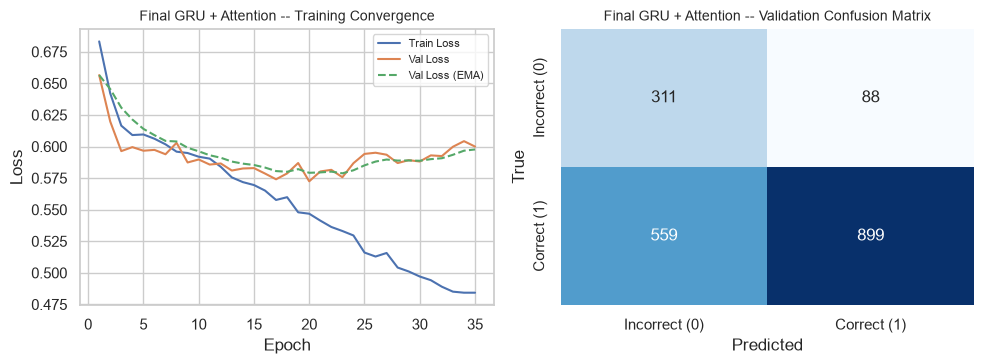

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
plot_training_curves(gru_attn_final_train_losses, gru_attn_final_val_losses, gru_attn_final_val_loss_emas,
                      title='Final GRU + Attention -- Training Convergence', ax=axes[0])
plot_confusion_matrix(gru_attn_final_val_metrics['confusion_matrix'],
                       title='Final GRU + Attention -- Validation Confusion Matrix', ax=axes[1])
fig.tight_layout()
plt.show()

In [28]:
gru_attn_final_test_loader = create_dataloader(test_df, features, batch_size=selected_gru_attn_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

gru_attn_final_test_metrics = evaluate_model(gru_attn_final_model, gru_attn_final_test_loader, gru_attn_final_criterion, gru_attn_final_device)

print("=== Final GRU + Attention Model -- Test Set Evaluation ===")
print(f"Test Loss:        {gru_attn_final_test_metrics['loss']:.4f}")
print(f"Test Macro F1:    {gru_attn_final_test_metrics['macro_f1']:.4f}")
print(f"Test F1 (class0): {gru_attn_final_test_metrics['f1_class0']:.4f}")
print(f"Test F1 (class1): {gru_attn_final_test_metrics['f1_class1']:.4f}")
print(f"Test ROC-AUC:     {gru_attn_final_test_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(gru_attn_final_test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))


=== Final GRU + Attention Model -- Test Set Evaluation ===
Test Loss:        0.6426
Test Macro F1:    0.5981
Test F1 (class0): 0.4842
Test F1 (class1): 0.7120
Test ROC-AUC:     0.7109
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     322     125
True 1     561     848


### Section 4o: Final GRU + Attention Model -- Test Confusion Matrix

This section Renders the final GRU + Attention model's test-set confusion matrix (`gru_attn_final_test_metrics['confusion_matrix']`, computed in the cell above) as a heatmap -- a visual companion to the exact counts already printed.

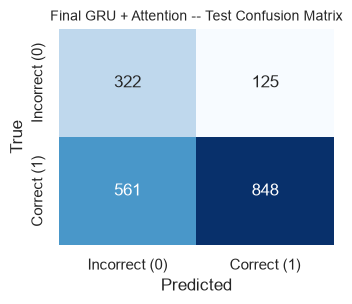

In [29]:
plot_confusion_matrix(gru_attn_final_test_metrics['confusion_matrix'],
                       title='Final GRU + Attention -- Test Confusion Matrix')

### Section 4p: Visualizing What the Attention Layer Looks At

Basing from our Objective 2 (which ocular behaviors carry the strongest predictive signal) for the GRU + Attention track, we explore for a handful of validation trials, replaying the trained `gru_attn_final_model`'s own `gru` and `attention` submodules by hand and mirroring `EyeMovementGRUAttention.forward` exactly, without modifying the model class -- to recover the per-timestep attention weights `AdditiveAttentionPooling` computes internally but that `forward()` never returns.

1. **Sample Selection**: We pull a few trials directly from `gru_attn_final_val_loader.dataset` -- no re-shuffling, no retraining, and no test-set contact.
2. **Manual Forward Pass**: We run the same `pack_padded_sequence` -> `gru` -> `pad_packed_sequence` -> `attention` sequence the model's own `forward()` uses internally, stopping one step early to capture `attn_weights` instead of letting them be discarded.
3. **Per-Trial Attention Curve**: This section plots each sampled trial's attention weight against timestep, showing which specific moments in the trial the trained model weighted most heavily when forming its prediction.

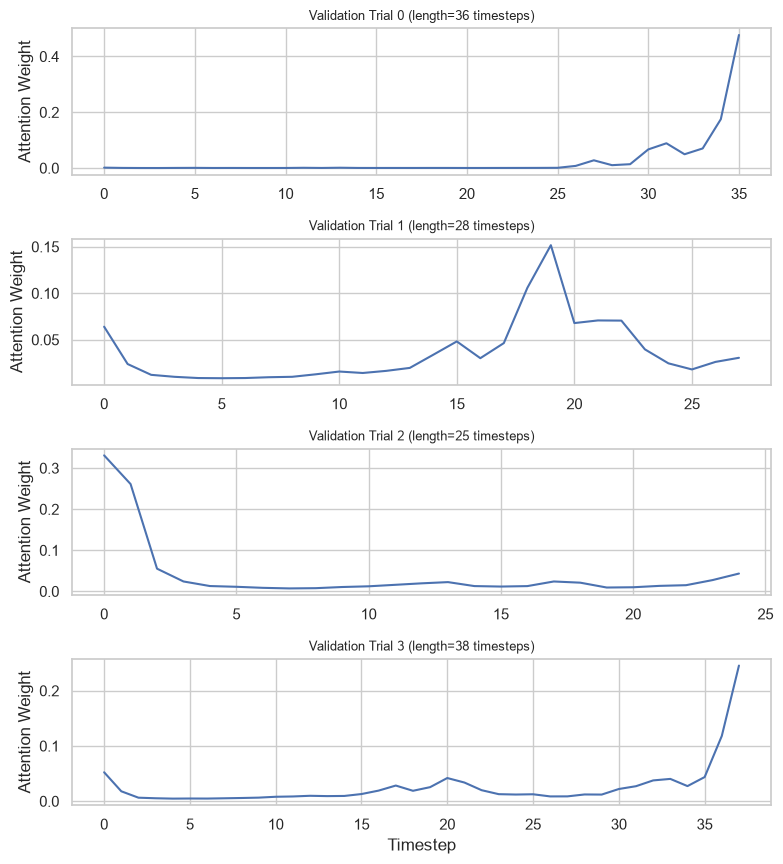

In [30]:
attn_viz_sample_size = 4
attn_viz_items = [gru_attn_final_val_loader.dataset[i] for i in range(attn_viz_sample_size)]
attn_viz_X, _, attn_viz_lengths = dynamic_batch_padding(attn_viz_items)

attn_viz_X = attn_viz_X.to(gru_attn_final_device)
attn_viz_lengths = attn_viz_lengths.to(gru_attn_final_device)

gru_attn_final_model.eval()
with torch.no_grad():
    attn_viz_packed = pack_padded_sequence(attn_viz_X, attn_viz_lengths.cpu(), batch_first=True, enforce_sorted=False)
    attn_viz_packed_out, _ = gru_attn_final_model.gru(attn_viz_packed)
    attn_viz_outputs, _ = pad_packed_sequence(attn_viz_packed_out, batch_first=True, total_length=attn_viz_X.shape[1])
    _, attn_viz_weights = gru_attn_final_model.attention(attn_viz_outputs, attn_viz_lengths)

attn_viz_weights = attn_viz_weights.cpu().numpy()

fig, axes = plt.subplots(attn_viz_sample_size, 1, figsize=(8, 2.2 * attn_viz_sample_size))
for i, ax in enumerate(axes):
    length = attn_viz_lengths[i].item()
    ax.plot(range(length), attn_viz_weights[i, :length])
    ax.set_title(f'Validation Trial {i} (length={length} timesteps)', fontsize=9)
    ax.set_ylabel('Attention Weight')
axes[-1].set_xlabel('Timestep')
fig.tight_layout()
plt.show()

### Section 4k: Data Ablation 1 (GRU + Attention) -- Fixations vs. Saccades

Same filtering as defined by the experimental plan, we explore (`eventType == 1` for fixations-only, `eventType == 0` for saccades-only, applied before the trial-grouping step), same reused scaler, retraining GRU + Attention's exact architecture and hyperparameters (`selected_gru_attn_hp`) unchanged as sequence length is the only thing that changes, and since `selected_gru_attn_hp` has no dependency on sequence length, nothing else needs to be adjusted. The existing `gru_attn_final_*` model already is the "both events" condition, so, similarly this only needs two new training runs.

#### Section 4ka: Data Ablation 1 (GRU + Attention) - Event Type Isolation

Note: RNN with Attention generally has the same process shared with the RNN ablation pipeline (set-up).

In [31]:
GRU_ATTN_EVENT_TYPE_CONDITIONS = {'fixations_only': 1, 'saccades_only': 0}

gru_attn_event_results = {}
for name, event_value in GRU_ATTN_EVENT_TYPE_CONDITIONS.items():
    print(f"\n{'=' * 80}\nData Ablation 1 (GRU + Attention) -- {name} (eventType == {event_value})\n{'=' * 80}")

    cond_train_df = train_df[train_df['eventType'] == event_value]
    cond_val_df = val_df[val_df['eventType'] == event_value]
    cond_test_df = test_df[test_df['eventType'] == event_value]

    cond_train_loader = create_dataloader(cond_train_df, features, batch_size=selected_gru_attn_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
    cond_val_loader = create_dataloader(cond_val_df, features, batch_size=selected_gru_attn_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)
    cond_test_loader = create_dataloader(cond_test_df, features, batch_size=selected_gru_attn_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

    print(f"Trials: train={len(cond_train_loader.dataset)}, val={len(cond_val_loader.dataset)}, test={len(cond_test_loader.dataset)} "
          f"(baseline both-events: train={len(gru_attn_final_train_loader.dataset)}, val={len(gru_attn_final_val_loader.dataset)}, "
          f"test={len(gru_attn_final_test_loader.dataset)})")

    cond_train_labels = np.array([label for _, label, _ in cond_train_loader.dataset])
    cond_class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(cond_train_labels), y=cond_train_labels)
    cond_class_weights_tensor = torch.tensor(cond_class_weights, dtype=torch.float32).to(gru_attn_final_device)
    cond_criterion = nn.CrossEntropyLoss(weight=cond_class_weights_tensor)

    set_seed(69)
    cond_model = EyeMovementGRUAttention(
        n_features=N_FEATURES,
        hidden_dim=selected_gru_attn_hp['hidden_dim'],
        num_layers=selected_gru_attn_hp['num_layers'],
        attn_dim=selected_gru_attn_hp['attn_dim'],
        num_fc_layers=selected_gru_attn_hp['num_fc_layers'],
        fc_hidden_size=selected_gru_attn_hp['fc_hidden_size'],
        rnn_dropout=selected_gru_attn_hp['rnn_dropout'],
        fc_dropout=selected_gru_attn_hp['fc_dropout'],
    ).to(gru_attn_final_device)

    cond_optimizer = optim.Adam(cond_model.parameters(), lr=selected_gru_attn_hp['learning_rate'])

    cond_model, cond_best_val_loss, cond_train_losses, cond_val_losses, cond_val_loss_emas = train_with_early_stopping(
        cond_model, cond_train_loader, cond_val_loader, cond_optimizer, cond_criterion, gru_attn_final_device,
        max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
    )

    cond_val_metrics = evaluate_model(cond_model, cond_val_loader, cond_criterion, gru_attn_final_device)
    gru_attn_event_results[name] = {
        'model': cond_model, 'criterion': cond_criterion, 'test_loader': cond_test_loader, 'val_metrics': cond_val_metrics,
    }

    print(f"Val Loss:        {cond_val_metrics['loss']:.4f}")
    print(f"Val Macro F1:    {cond_val_metrics['macro_f1']:.4f}")
    print(f"Val F1 (class0): {cond_val_metrics['f1_class0']:.4f}")
    print(f"Val F1 (class1): {cond_val_metrics['f1_class1']:.4f}")
    print(f"Val ROC-AUC:     {cond_val_metrics['roc_auc']:.4f}")
    print("Confusion Matrix (rows=true, cols=pred):")
    print(pd.DataFrame(cond_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Data Ablation 1 (GRU + Attention): Validation Summary (vs. the final model's both-events baseline) ===")
gru_attn_event_val_rows = {
    name: {
        'val_loss': r['val_metrics']['loss'],
        'val_macro_f1': r['val_metrics']['macro_f1'],
        'val_f1_class0': r['val_metrics']['f1_class0'],
        'val_f1_class1': r['val_metrics']['f1_class1'],
        'val_roc_auc': r['val_metrics']['roc_auc'],
    }
    for name, r in gru_attn_event_results.items()
}
gru_attn_event_val_rows['both_events_baseline'] = {
    'val_loss': gru_attn_final_val_metrics['loss'],
    'val_macro_f1': gru_attn_final_val_metrics['macro_f1'],
    'val_f1_class0': gru_attn_final_val_metrics['f1_class0'],
    'val_f1_class1': gru_attn_final_val_metrics['f1_class1'],
    'val_roc_auc': gru_attn_final_val_metrics['roc_auc'],
}
gru_attn_event_val_summary = pd.DataFrame(gru_attn_event_val_rows).T
display(gru_attn_event_val_summary)



Data Ablation 1 (GRU + Attention) -- fixations_only (eventType == 1)
Trials: train=5465, val=1857, test=1855 (baseline both-events: train=5465, val=1857, test=1856)
Epoch   1/200 | train_loss=0.6826 | val_loss=0.6513 | val_loss_ema=0.6513
Epoch   2/200 | train_loss=0.6431 | val_loss=0.6208 | val_loss_ema=0.6421
Epoch   3/200 | train_loss=0.6156 | val_loss=0.5982 | val_loss_ema=0.6289
Epoch   4/200 | train_loss=0.6100 | val_loss=0.5998 | val_loss_ema=0.6202
Epoch   5/200 | train_loss=0.6104 | val_loss=0.5994 | val_loss_ema=0.6140
Epoch   6/200 | train_loss=0.6046 | val_loss=0.5969 | val_loss_ema=0.6088
Epoch   7/200 | train_loss=0.6023 | val_loss=0.5960 | val_loss_ema=0.6050
Epoch   8/200 | train_loss=0.5956 | val_loss=0.6053 | val_loss_ema=0.6051
Epoch   9/200 | train_loss=0.5939 | val_loss=0.5906 | val_loss_ema=0.6007
Epoch  10/200 | train_loss=0.5947 | val_loss=0.5914 | val_loss_ema=0.5979
Epoch  11/200 | train_loss=0.5893 | val_loss=0.5952 | val_loss_ema=0.5971
Epoch  12/200 | trai

,val_loss,val_macro_f1,val_f1_class0,val_f1_class1,val_roc_auc
fixations_only,0.5886,0.6107,0.4861,0.7352,0.7550
saccades_only,0.5804,0.6068,0.4884,0.7252,0.7612
both_events_baseline,0.5724,0.6128,0.4901,0.7354,0.7664


#### Section 4kb: Data Ablation 1 (GRU + Attention) - Test Set Evaluation

Note: RNN with Attention generally has the same process shared with the RNN ablation pipeline (evaluation).

In [32]:
for name, r in gru_attn_event_results.items():
    test_metrics = evaluate_model(r['model'], r['test_loader'], r['criterion'], gru_attn_final_device)
    r['test_metrics'] = test_metrics

    print(f"\nData Ablation 1 (GRU + Attention) -- {name} -- Test Set Evaluation")
    print(f"Test Loss:        {test_metrics['loss']:.4f}")
    print(f"Test Macro F1:    {test_metrics['macro_f1']:.4f}")
    print(f"Test F1 (class0): {test_metrics['f1_class0']:.4f}")
    print(f"Test F1 (class1): {test_metrics['f1_class1']:.4f}")
    print(f"Test ROC-AUC:     {test_metrics['roc_auc']:.4f}")
    print("Confusion Matrix (rows=true, cols=pred):")
    print(pd.DataFrame(test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Data Ablation 1 (GRU + Attention): Test Summary (vs. the final model's both-events baseline) ===")
gru_attn_event_test_rows = {
    name: {
        'test_loss': r['test_metrics']['loss'],
        'test_macro_f1': r['test_metrics']['macro_f1'],
        'test_f1_class0': r['test_metrics']['f1_class0'],
        'test_f1_class1': r['test_metrics']['f1_class1'],
        'test_roc_auc': r['test_metrics']['roc_auc'],
    }
    for name, r in gru_attn_event_results.items()
}
gru_attn_event_test_rows['both_events_baseline'] = {
    'test_loss': gru_attn_final_test_metrics['loss'],
    'test_macro_f1': gru_attn_final_test_metrics['macro_f1'],
    'test_f1_class0': gru_attn_final_test_metrics['f1_class0'],
    'test_f1_class1': gru_attn_final_test_metrics['f1_class1'],
    'test_roc_auc': gru_attn_final_test_metrics['roc_auc'],
}
gru_attn_event_test_summary = pd.DataFrame(gru_attn_event_test_rows).T
display(gru_attn_event_test_summary)



Data Ablation 1 (GRU + Attention) -- fixations_only -- Test Set Evaluation
Test Loss:        0.6167
Test Macro F1:    0.6110
Test F1 (class0): 0.4992
Test F1 (class1): 0.7228
Test ROC-AUC:     0.7268
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     330     116
True 1     546     863

Data Ablation 1 (GRU + Attention) -- saccades_only -- Test Set Evaluation
Test Loss:        0.6205
Test Macro F1:    0.5961
Test F1 (class0): 0.4804
Test F1 (class1): 0.7119
Test ROC-AUC:     0.7229
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     318     129
True 1     559     850

=== Data Ablation 1 (GRU + Attention): Test Summary (vs. the final model's both-events baseline) ===


,test_loss,test_macro_f1,test_f1_class0,test_f1_class1,test_roc_auc
fixations_only,0.6167,0.6110,0.4992,0.7228,0.7268
saccades_only,0.6205,0.5961,0.4804,0.7119,0.7229
both_events_baseline,0.6426,0.5981,0.4842,0.7120,0.7109


### Section 4l: Data Ablation 2 (GRU + Attention) -- Coordinate-Free Features

Same 9-of-15 coordinate-free feature set as defined in the ablation experiment (reusing `features_no_coords`/`N_FEATURES_NO_COORDS` computed there, not recomputed here). GRU + Attention's architecture-defining hyperparameters (`hidden_dim`, `num_layers`, `attn_dim`, `fc_hidden_size`) have no dependency on `n_features` at all -- only `nn.GRU`'s `input_size` changes. `selected_gru_attn_hp` therefore carries over completely unchanged; only the feature list and the resulting `n_features` passed into the model differ from the final model.

#### Section 4la: Data Ablation 2 (GRU + Attention) - Validation on the Coordinate-Free Feature Set

Note: RNN with Attention generally has the same process shared with the RNN ablation pipeline (set-up).

In [33]:
print(f"Coordinate-free feature set ({N_FEATURES_NO_COORDS} features): {features_no_coords}")

gru_attn_coordfree_train_loader = create_dataloader(train_df, features_no_coords, batch_size=selected_gru_attn_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
gru_attn_coordfree_val_loader = create_dataloader(val_df, features_no_coords, batch_size=selected_gru_attn_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)
gru_attn_coordfree_test_loader = create_dataloader(test_df, features_no_coords, batch_size=selected_gru_attn_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

gru_attn_coordfree_train_labels = np.array([label for _, label, _ in gru_attn_coordfree_train_loader.dataset])
gru_attn_coordfree_class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(gru_attn_coordfree_train_labels), y=gru_attn_coordfree_train_labels
)
gru_attn_coordfree_class_weights_tensor = torch.tensor(gru_attn_coordfree_class_weights, dtype=torch.float32).to(gru_attn_final_device)
gru_attn_coordfree_criterion = nn.CrossEntropyLoss(weight=gru_attn_coordfree_class_weights_tensor)

set_seed(69)
gru_attn_coordfree_model = EyeMovementGRUAttention(
    n_features=N_FEATURES_NO_COORDS,
    hidden_dim=selected_gru_attn_hp['hidden_dim'],
    num_layers=selected_gru_attn_hp['num_layers'],
    attn_dim=selected_gru_attn_hp['attn_dim'],
    num_fc_layers=selected_gru_attn_hp['num_fc_layers'],
    fc_hidden_size=selected_gru_attn_hp['fc_hidden_size'],
    rnn_dropout=selected_gru_attn_hp['rnn_dropout'],
    fc_dropout=selected_gru_attn_hp['fc_dropout'],
).to(gru_attn_final_device)

gru_attn_coordfree_optimizer = optim.Adam(gru_attn_coordfree_model.parameters(), lr=selected_gru_attn_hp['learning_rate'])

gru_attn_coordfree_model, gru_attn_coordfree_best_val_loss, gru_attn_coordfree_train_losses, gru_attn_coordfree_val_losses, gru_attn_coordfree_val_loss_emas = train_with_early_stopping(
    gru_attn_coordfree_model, gru_attn_coordfree_train_loader, gru_attn_coordfree_val_loader, gru_attn_coordfree_optimizer, gru_attn_coordfree_criterion, gru_attn_final_device,
    max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
)

gru_attn_coordfree_val_metrics = evaluate_model(gru_attn_coordfree_model, gru_attn_coordfree_val_loader, gru_attn_coordfree_criterion, gru_attn_final_device)

print(f"\nData Ablation 2 (GRU + Attention, {N_FEATURES_NO_COORDS} features) -- Validation")
print(f"Val Loss:        {gru_attn_coordfree_val_metrics['loss']:.4f}")
print(f"Val Macro F1:    {gru_attn_coordfree_val_metrics['macro_f1']:.4f}")
print(f"Val F1 (class0): {gru_attn_coordfree_val_metrics['f1_class0']:.4f}")
print(f"Val F1 (class1): {gru_attn_coordfree_val_metrics['f1_class1']:.4f}")
print(f"Val ROC-AUC:     {gru_attn_coordfree_val_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(gru_attn_coordfree_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print(f"\nFor comparison, final GRU + Attention model (15 features): val macro F1={gru_attn_final_val_metrics['macro_f1']:.4f}, "
      f"val F1 class0={gru_attn_final_val_metrics['f1_class0']:.4f}, val ROC-AUC={gru_attn_final_val_metrics['roc_auc']:.4f}")


Coordinate-free feature set (9 features): ['eventType', 'timeSinceStart', 'eye', 'duration', 'meanPupilDiameter', 'microsaccadeCount', 'microsaccadeAmplitude', 'microsaccadePeakVelocity', 'saccadeAmplitude']
Epoch   1/200 | train_loss=0.6859 | val_loss=0.6466 | val_loss_ema=0.6466
Epoch   2/200 | train_loss=0.6354 | val_loss=0.6139 | val_loss_ema=0.6368
Epoch   3/200 | train_loss=0.6145 | val_loss=0.5988 | val_loss_ema=0.6254
Epoch   4/200 | train_loss=0.6111 | val_loss=0.6014 | val_loss_ema=0.6182
Epoch   5/200 | train_loss=0.6104 | val_loss=0.6006 | val_loss_ema=0.6129
Epoch   6/200 | train_loss=0.6062 | val_loss=0.6002 | val_loss_ema=0.6091
Epoch   7/200 | train_loss=0.6053 | val_loss=0.6060 | val_loss_ema=0.6082
Epoch   8/200 | train_loss=0.6051 | val_loss=0.6064 | val_loss_ema=0.6076
Epoch   9/200 | train_loss=0.6024 | val_loss=0.6006 | val_loss_ema=0.6055
Epoch  10/200 | train_loss=0.6023 | val_loss=0.6019 | val_loss_ema=0.6044
Epoch  11/200 | train_loss=0.6013 | val_loss=0.6045 

#### Section 4lb: Data Ablation 2 (GRU + Attention) - Test Set Evaluation

Note: RNN with Attention generally has the same process shared with the RNN ablation pipeline (evaluation).

In [34]:
gru_attn_coordfree_test_metrics = evaluate_model(gru_attn_coordfree_model, gru_attn_coordfree_test_loader, gru_attn_coordfree_criterion, gru_attn_final_device)

print(f"Data Ablation 2 (GRU + Attention, {N_FEATURES_NO_COORDS} features) -- Test Set Evaluation")
print(f"Test Loss:        {gru_attn_coordfree_test_metrics['loss']:.4f}")
print(f"Test Macro F1:    {gru_attn_coordfree_test_metrics['macro_f1']:.4f}")
print(f"Test F1 (class0): {gru_attn_coordfree_test_metrics['f1_class0']:.4f}")
print(f"Test F1 (class1): {gru_attn_coordfree_test_metrics['f1_class1']:.4f}")
print(f"Test ROC-AUC:     {gru_attn_coordfree_test_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(gru_attn_coordfree_test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print(f"\nFor comparison, final GRU + Attention model (15 features): test macro F1={gru_attn_final_test_metrics['macro_f1']:.4f}, "
      f"test F1 class0={gru_attn_final_test_metrics['f1_class0']:.4f}, test ROC-AUC={gru_attn_final_test_metrics['roc_auc']:.4f}")


Data Ablation 2 (GRU + Attention, 9 features) -- Test Set Evaluation
Test Loss:        0.6188
Test Macro F1:    0.6188
Test F1 (class0): 0.4976
Test F1 (class1): 0.7400
Test ROC-AUC:     0.7244
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     315     132
True 1     504     905

For comparison, final GRU + Attention model (15 features): test macro F1=0.5981, test F1 class0=0.4842, test ROC-AUC=0.7109


### Section 4m: Data Ablation 3 (GRU + Attention) -- Per-Task Specialization

For RNN with attention, we run one model per task block (Series Continuation, Classifications, Matrices, Topological Conclusions), each using GRU + Attention's selected architecture (`selected_gru_attn_hp`) but only that block's trials. The generalist's comparison numbers are recomputed *per block* here by re-scoring the already-trained `gru_attn_final_model` on each block's own val/test subset, not its overall aggregate metrics -- comparing a specialist's block-specific performance
against the generalist's overall performance would compare different populations.

#### Section 4ma: Data Ablation 3 (GRU + Attention) - Per-Block Training and Validation

Note: RNN with Attention generally has the same process shared with the RNN ablation pipeline (set-up).

In [35]:
gru_attn_task_results = {}
for block in TASK_BLOCKS:
    print(f"\n{'=' * 80}\nData Ablation 3 (GRU + Attention) -- {block}\n{'=' * 80}")

    block_train_df = train_df[train_df[block] == 1]
    block_val_df = val_df[val_df[block] == 1]
    block_test_df = test_df[test_df[block] == 1]

    block_train_loader = create_dataloader(block_train_df, features, batch_size=selected_gru_attn_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
    block_val_loader = create_dataloader(block_val_df, features, batch_size=selected_gru_attn_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)
    block_test_loader = create_dataloader(block_test_df, features, batch_size=selected_gru_attn_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

    print(f"Trials: train={len(block_train_loader.dataset)}, val={len(block_val_loader.dataset)}, test={len(block_test_loader.dataset)}")

    block_train_labels = np.array([label for _, label, _ in block_train_loader.dataset])
    block_class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(block_train_labels), y=block_train_labels)
    block_class_weights_tensor = torch.tensor(block_class_weights, dtype=torch.float32).to(gru_attn_final_device)
    block_criterion = nn.CrossEntropyLoss(weight=block_class_weights_tensor)

    set_seed(69)
    block_model = EyeMovementGRUAttention(
        n_features=N_FEATURES,
        hidden_dim=selected_gru_attn_hp['hidden_dim'],
        num_layers=selected_gru_attn_hp['num_layers'],
        attn_dim=selected_gru_attn_hp['attn_dim'],
        num_fc_layers=selected_gru_attn_hp['num_fc_layers'],
        fc_hidden_size=selected_gru_attn_hp['fc_hidden_size'],
        rnn_dropout=selected_gru_attn_hp['rnn_dropout'],
        fc_dropout=selected_gru_attn_hp['fc_dropout'],
    ).to(gru_attn_final_device)

    block_optimizer = optim.Adam(block_model.parameters(), lr=selected_gru_attn_hp['learning_rate'])

    block_model, block_best_val_loss, block_train_losses, block_val_losses, block_val_loss_emas = train_with_early_stopping(
        block_model, block_train_loader, block_val_loader, block_optimizer, block_criterion, gru_attn_final_device,
        max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
    )

    block_val_metrics = evaluate_model(block_model, block_val_loader, block_criterion, gru_attn_final_device)

    # Generalist comparison: the already-trained final GRU + Attention model, re-scored on this block's
    # val subset only -- NOT its overall aggregate metrics, which would be a different population.
    general_block_val_metrics = evaluate_model(gru_attn_final_model, block_val_loader, gru_attn_final_criterion, gru_attn_final_device)

    gru_attn_task_results[block] = {
        'model': block_model, 'criterion': block_criterion, 'test_loader': block_test_loader,
        'specialist_val_metrics': block_val_metrics, 'general_val_metrics': general_block_val_metrics,
    }

    print(f"Specialist -- Val Loss: {block_val_metrics['loss']:.4f} | Val Macro F1: {block_val_metrics['macro_f1']:.4f} | "
          f"Val F1 class0: {block_val_metrics['f1_class0']:.4f} | Val F1 class1: {block_val_metrics['f1_class1']:.4f} | "
          f"Val ROC-AUC: {block_val_metrics['roc_auc']:.4f}")
    print(f"Generalist (scored on this block only) -- Val Macro F1: {general_block_val_metrics['macro_f1']:.4f} | "
          f"Val F1 class0: {general_block_val_metrics['f1_class0']:.4f} | Val F1 class1: {general_block_val_metrics['f1_class1']:.4f} | "
          f"Val ROC-AUC: {general_block_val_metrics['roc_auc']:.4f}")
    print("Specialist Confusion Matrix (rows=true, cols=pred):")
    print(pd.DataFrame(block_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Data Ablation 3 (GRU + Attention): Validation Summary -- Specialist vs. Generalist per Block ===")
gru_attn_task_val_rows = {}
for block, r in gru_attn_task_results.items():
    gru_attn_task_val_rows[f"{block}_specialist"] = {
        'val_macro_f1': r['specialist_val_metrics']['macro_f1'],
        'val_f1_class0': r['specialist_val_metrics']['f1_class0'],
        'val_f1_class1': r['specialist_val_metrics']['f1_class1'],
        'val_roc_auc': r['specialist_val_metrics']['roc_auc'],
    }
    gru_attn_task_val_rows[f"{block}_generalist"] = {
        'val_macro_f1': r['general_val_metrics']['macro_f1'],
        'val_f1_class0': r['general_val_metrics']['f1_class0'],
        'val_f1_class1': r['general_val_metrics']['f1_class1'],
        'val_roc_auc': r['general_val_metrics']['roc_auc'],
    }
gru_attn_task_val_summary = pd.DataFrame(gru_attn_task_val_rows).T
display(gru_attn_task_val_summary)



Data Ablation 3 (GRU + Attention) -- block_1
Trials: train=1540, val=524, test=519
Epoch   1/200 | train_loss=0.6948 | val_loss=0.6813 | val_loss_ema=0.6813
Epoch   2/200 | train_loss=0.6859 | val_loss=0.6689 | val_loss_ema=0.6776
Epoch   3/200 | train_loss=0.6724 | val_loss=0.6461 | val_loss_ema=0.6681
Epoch   4/200 | train_loss=0.6501 | val_loss=0.6234 | val_loss_ema=0.6547
Epoch   5/200 | train_loss=0.6302 | val_loss=0.6001 | val_loss_ema=0.6383
Epoch   6/200 | train_loss=0.6075 | val_loss=0.6082 | val_loss_ema=0.6293
Epoch   7/200 | train_loss=0.6035 | val_loss=0.5938 | val_loss_ema=0.6187
Epoch   8/200 | train_loss=0.5828 | val_loss=0.5891 | val_loss_ema=0.6098
Epoch   9/200 | train_loss=0.5777 | val_loss=0.6109 | val_loss_ema=0.6101
Epoch  10/200 | train_loss=0.5840 | val_loss=0.6048 | val_loss_ema=0.6085
Epoch  11/200 | train_loss=0.5788 | val_loss=0.5947 | val_loss_ema=0.6044
Epoch  12/200 | train_loss=0.5760 | val_loss=0.5812 | val_loss_ema=0.5974
Epoch  13/200 | train_loss=0

,val_macro_f1,val_f1_class0,val_f1_class1,val_roc_auc
block_1_specialist,0.5528,0.3497,0.7559,0.7665
block_1_generalist,0.5848,0.3788,0.7908,0.7765
block_2_specialist,0.6886,0.5493,0.8280,0.8183
block_2_generalist,0.6195,0.5056,0.7335,0.7788
block_3_specialist,0.5876,0.4258,0.7493,0.7607
block_3_generalist,0.5796,0.4040,0.7552,0.7348
block_4_specialist,0.5300,0.5118,0.5483,0.5849
block_4_generalist,0.5791,0.6322,0.5259,0.6702


#### Section 4mb: Data Ablation 3 (GRU + Attention) - Test Set Evaluation

Note: RNN with Attention generally has the same process shared with the RNN ablation pipeline (evaluation).

In [36]:
for block, r in gru_attn_task_results.items():
    specialist_test_metrics = evaluate_model(r['model'], r['test_loader'], r['criterion'], gru_attn_final_device)
    general_test_metrics = evaluate_model(gru_attn_final_model, r['test_loader'], gru_attn_final_criterion, gru_attn_final_device)
    r['specialist_test_metrics'] = specialist_test_metrics
    r['general_test_metrics'] = general_test_metrics

    print(f"\nData Ablation 3 (GRU + Attention) -- {block} -- Test Set Evaluation")
    print(f"Specialist -- Test Macro F1: {specialist_test_metrics['macro_f1']:.4f} | "
          f"Test F1 class0: {specialist_test_metrics['f1_class0']:.4f} | "
          f"Test F1 class1: {specialist_test_metrics['f1_class1']:.4f} | "
          f"Test ROC-AUC: {specialist_test_metrics['roc_auc']:.4f}")
    print(f"Generalist (scored on this block only) -- Test Macro F1: {general_test_metrics['macro_f1']:.4f} | "
          f"Test F1 class0: {general_test_metrics['f1_class0']:.4f} | "
          f"Test F1 class1: {general_test_metrics['f1_class1']:.4f} | "
          f"Test ROC-AUC: {general_test_metrics['roc_auc']:.4f}")
    print("Specialist Confusion Matrix (rows=true, cols=pred):")
    print(pd.DataFrame(specialist_test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Data Ablation 3 (GRU + Attention): Test Summary -- Specialist vs. Generalist per Block ===")
gru_attn_task_test_rows = {}
for block, r in gru_attn_task_results.items():
    gru_attn_task_test_rows[f"{block}_specialist"] = {
        'test_macro_f1': r['specialist_test_metrics']['macro_f1'],
        'test_f1_class0': r['specialist_test_metrics']['f1_class0'],
        'test_f1_class1': r['specialist_test_metrics']['f1_class1'],
        'test_roc_auc': r['specialist_test_metrics']['roc_auc'],
    }
    gru_attn_task_test_rows[f"{block}_generalist"] = {
        'test_macro_f1': r['general_test_metrics']['macro_f1'],
        'test_f1_class0': r['general_test_metrics']['f1_class0'],
        'test_f1_class1': r['general_test_metrics']['f1_class1'],
        'test_roc_auc': r['general_test_metrics']['roc_auc'],
    }
gru_attn_task_test_summary = pd.DataFrame(gru_attn_task_test_rows).T
display(gru_attn_task_test_summary)



Data Ablation 3 (GRU + Attention) -- block_1 -- Test Set Evaluation
Specialist -- Test Macro F1: 0.5349 | Test F1 class0: 0.3333 | Test F1 class1: 0.7366 | Test ROC-AUC: 0.6753
Generalist (scored on this block only) -- Test Macro F1: 0.5541 | Test F1 class0: 0.3281 | Test F1 class1: 0.7801 | Test ROC-AUC: 0.6743
Specialist Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0      49      33
True 1     163     274

Data Ablation 3 (GRU + Attention) -- block_2 -- Test Set Evaluation
Specialist -- Test Macro F1: 0.6752 | Test F1 class0: 0.5706 | Test F1 class1: 0.7797 | Test ROC-AUC: 0.7548
Generalist (scored on this block only) -- Test Macro F1: 0.6408 | Test F1 class0: 0.5645 | Test F1 class1: 0.7172 | Test ROC-AUC: 0.7594
Specialist Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     101      45
True 1     107     269

Data Ablation 3 (GRU + Attention) -- block_3 -- Test Set Evaluation
Specialist -- Test Macro F1: 0.6319 | Test F1 class0: 0.514

,test_macro_f1,test_f1_class0,test_f1_class1,test_roc_auc
block_1_specialist,0.5349,0.3333,0.7366,0.6753
block_1_generalist,0.5541,0.3281,0.7801,0.6743
block_2_specialist,0.6752,0.5706,0.7797,0.7548
block_2_generalist,0.6408,0.5645,0.7172,0.7594
block_3_specialist,0.6319,0.5146,0.7492,0.7824
block_3_generalist,0.6085,0.4759,0.7411,0.6897
block_4_specialist,0.5096,0.4610,0.5581,0.5738
block_4_generalist,0.4839,0.5136,0.4542,0.5941


## Section 5: Transformer on Eye-Movement Time Series

Like Section 4's two architectures, we present the Transformer track, which is generally built on the same shared data pipeline (`create_dataloader`, `features`, `train_df`/`val_df`/`test_df`, `MAX_SEQ_LEN`) and shared training/evaluation infrastructure (`train_with_early_stopping`, `evaluate_model`) defined in Section 3, under the identical `forward(x, lengths)` contract, where nothing in those helpers changes between architectures.

- **`EyeMovementTransformer`**: a 1D convolutional patcher extracts localized temporal patterns per feature, flattens them into token embeddings, prepends a learnable CLS token, adds sinusoidal positional encoding, and runs the result through a Pre-LN Transformer encoder. The CLS token's final hidden state is the trial's summary representation.
- Unlike GRU/GRU + Attention's single dedicated search each, the Transformer track runs **three sequential search phases**, each narrowing what the next one searches over:
  1. A 30-trial random search (Proposal S6.2) over the conv-patcher backbone's own hyperparameters (kernel size, encoder depth/width, dropout, FC head).
  2. A 6-way **architecture ablation** testing whether something other than (or in addition to) the conv patcher makes a better tokenizer, using the backbone hyperparameters the first search selected.
  3. A dedicated 30-trial search over the tokenizer-specific hyperparameters (expansion factor, tokenizer depth, dropout, gate type) for whichever tokenizer the ablation selects.
- The final, dynamically-captured configuration from that third search trains the track's single ultimate model, validated then tested exactly once, then subjected to the same 3 data ablations run across the board (fixations vs. saccades, coordinate-free features, per-task specialization) as GRU and GRU + Attention.


### Section 5.1a: Transformer Architecture

Here, we define the two PyTorch classes that make up the Transformer track's baseline architecture: a convolutional patcher that tokenizes the raw eye-movement sequence, and the end-to-end Transformer model built on top of it.

1. **`EyeMovementPatcher`**: A grouped 1D convolution (`groups=n_features`) that extracts `patch_out_channels` (`m`) learned temporal patterns *per feature*, independently, so features are never mixed at this stage.
   * This slides a `kernel_size`-wide window across each feature's own timeseries with stride `stride`, converting `seq_len` raw timesteps into a shorter sequence of `t` patches (`t = (seq_len - kernel_size) // stride + 1`).
   * It reshapes and permutes its output into a `(batch, t, m, n)` tensor, matching the `t x m x n` patch-token layout the encoder expects.
2. **`EyeMovementTransformer`**: The end-to-end model: conv patcher -> CLS token + positional encoding -> Transformer encoder -> FC classification head.
   * Flattens each patch's `(m, n)` dimensions together into a single `d_model = m * n_features`-wide token embedding.
   * Prepends a learnable CLS token (`nn.Parameter`, small-scale-initialized) to the patch token sequence -- this token's final hidden state becomes the model's trial-level summary representation.
   * Adds a standard sinusoidal positional encoding (computed on the fly, so any sequence length works without a fixed-length lookup table) so the encoder can tell patches apart by position.
   * Builds a boolean padding mask (`_build_padding_mask`) from each trial's true (pre-padding) length, so `nn.TransformerEncoder`'s self-attention never attends to structurally-padded patches; a trial too short to produce even one real patch degenerates to attending only to its own CLS token.
   * Runs the tokens through a **Pre-LN** (`norm_first=True`) `nn.TransformerEncoder` stack, with an explicit final `nn.LayerNorm` after the stack -- required for Pre-LN architectures, since normalizing each sublayer's input (never its output) lets the residual stream's magnitude grow unboundedly with depth otherwise.
   * Extracts the encoded CLS token's representation and maps it to 2 output logits via the same style of multi-layer FC head used elsewhere in this notebook.

In [37]:
PATCH_KERNEL_SIZE = 5    # k: length (in timesteps) of each patch's receptive field
PATCH_STRIDE = 3         # s: step size between patches (s <= k allows overlapping patches)
PATCH_OUT_CHANNELS = 8   # m: number of learned output channels extracted per feature, per patch


class EyeMovementPatcher(nn.Module):
    def __init__(self, n_features, kernel_size, stride, out_channels_per_feature):
        super().__init__()
        self.n_features = n_features
        self.out_channels_per_feature = out_channels_per_feature

        # groups=n_features gives each feature channel its own independent set of
        # `out_channels_per_feature` filters, so channels are never mixed at this stage
        self.patcher = nn.Conv1d(
            in_channels=n_features,
            out_channels=n_features * out_channels_per_feature,
            kernel_size=kernel_size,
            stride=stride,
            groups=n_features,
        )

    def forward(self, x, verbose=True):
        # x: (batch, seq_len, n_features)
        if verbose:
            print(f"[Patcher] input: {tuple(x.shape)}")

        x = x.permute(0, 2, 1)  # conv1d expects (batch, channels, seq_len)
        x = x.contiguous()
        if verbose:
            print(f"[Patcher] channels-first: {tuple(x.shape)}")

        x = self.patcher(x)  # (batch, n_features * m, t)
        if verbose:
            print(f"[Patcher] after conv1d: {tuple(x.shape)}")

        batch_size, _, t = x.shape
        x = x.reshape(batch_size, self.n_features, self.out_channels_per_feature, t)
        if verbose:
            print(f"[Patcher] reshaped to (batch, n, m, t): {tuple(x.shape)}")

        x = x.permute(0, 3, 2, 1)  # -> (batch, t, m, n), matches the proposal's t x m x n tensor
        if verbose:
            print(f"[Patcher] final (batch, t, m, n): {tuple(x.shape)}")

        return x


class EyeMovementTransformer(nn.Module):
    """End-to-end architecture: 1D conv patcher -> CLS token + positional encoding -> Transformer encoder -> FC classification head."""

    def __init__(
        self,
        n_features,
        patch_kernel_size,
        patch_stride,
        patch_out_channels,       # m: conv output channels per feature -> sets d_model = m * n_features
        num_encoder_layers,       # depth of the Transformer encoder stack
        num_attention_heads,      # self-attention heads per encoder layer (must evenly divide d_model)
        ffn_hidden_dim,           # feed-forward sublayer width inside each encoder layer
        num_fc_layers,            # number of Linear layers in the classification head (last one always -> 2 logits)
        fc_hidden_size,           # hidden width of the FC head's intermediate layers
        attention_dropout=0.1,
        fc_dropout=0.2,
    ):
        super().__init__()
        self.patch_kernel_size = patch_kernel_size
        self.patch_stride = patch_stride

        self.patcher = EyeMovementPatcher(n_features, patch_kernel_size, patch_stride, patch_out_channels)

        # d_model: transformer embedding dimension, fixed by flattening the patcher's (m, n) dims together
        self.d_model = patch_out_channels * n_features
        assert self.d_model % num_attention_heads == 0, (
            f"d_model ({self.d_model} = m * n_features) must be divisible by num_attention_heads "
            f"({num_attention_heads}); got remainder {self.d_model % num_attention_heads}."
        )

        # learnable "timestep 0" / CLS token, prepended to every sequence (Devlin et al., Dosovitskiy et al.)
        self.cls_token = nn.Parameter(torch.randn(1, 1, self.d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=num_attention_heads,
            dim_feedforward=ffn_hidden_dim,
            dropout=attention_dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_encoder_layers, norm=nn.LayerNorm(self.d_model)
        )

        fc_layers = []
        in_dim = self.d_model
        for _ in range(num_fc_layers - 1):
            fc_layers.append(nn.Linear(in_dim, fc_hidden_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(fc_dropout))
            in_dim = fc_hidden_size
        fc_layers.append(nn.Linear(in_dim, 2))  # 2 output logits: incorrect (0) vs correct (1)
        self.fc = nn.Sequential(*fc_layers)

    @staticmethod
    def _sinusoidal_positional_encoding(seq_len, d_model, device):
        # standard sinusoidal PE (Vaswani et al.), computed on the fly so any sequence length works
        position = torch.arange(seq_len, device=device).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2, device=device).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(seq_len, d_model, device=device)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe

    def _build_padding_mask(self, lengths, num_patches, device):
        # how many of this sample's patches are built from real (non-padded) timesteps
        valid_patches = torch.div(lengths - self.patch_kernel_size, self.patch_stride, rounding_mode='floor') + 1
        valid_patches = valid_patches.clamp(min=0, max=num_patches)

        # True = ignore this position in attention (it's padding); False = real patch or the CLS token
        patch_positions = torch.arange(num_patches, device=device).unsqueeze(0)  # (1, t)
        patch_padding_mask = patch_positions >= valid_patches.unsqueeze(1)       # (batch, t)

        cls_mask = torch.zeros(lengths.shape[0], 1, dtype=torch.bool, device=device)  # CLS is never padding
        return torch.cat([cls_mask, patch_padding_mask], dim=1)  # (batch, t+1)

    def forward(self, x, lengths, verbose=False):
        # x: (batch, seq_len, n_features); lengths: (batch,) true (pre-padding) trial lengths
        if verbose:
            print(f"[Transformer] input x: {tuple(x.shape)}, lengths: {tuple(lengths.shape)}")

        patches = self.patcher(x, verbose=verbose)  # (batch, t, m, n)
        batch_size, num_patches, m, n = patches.shape

        tokens = patches.reshape(batch_size, num_patches, m * n)  # flatten (m, n) -> d_model
        if verbose:
            print(f"[Transformer] flattened patch tokens: {tuple(tokens.shape)}")

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)  # (batch, 1, d_model)
        tokens = torch.cat([cls_tokens, tokens], dim=1)  # prepend CLS -> (batch, t+1, d_model)
        if verbose:
            print(f"[Transformer] with CLS token prepended: {tuple(tokens.shape)}")

        pos_encoding = self._sinusoidal_positional_encoding(tokens.shape[1], self.d_model, tokens.device)
        tokens = tokens + pos_encoding.unsqueeze(0)
        if verbose:
            print(f"[Transformer] with positional encoding added: {tuple(tokens.shape)}")

        padding_mask = self._build_padding_mask(lengths, num_patches, tokens.device)
        if verbose:
            print(f"[Transformer] padding mask: {tuple(padding_mask.shape)}")

        encoded = self.encoder(tokens, src_key_padding_mask=padding_mask)
        if verbose:
            print(f"[Transformer] encoder output: {tuple(encoded.shape)}")

        cls_representation = encoded[:, 0, :]  # final hidden state of the CLS token
        if verbose:
            print(f"[Transformer] CLS representation: {tuple(cls_representation.shape)}")

        logits = self.fc(cls_representation)  # raw logits; apply softmax externally for class probabilities
        if verbose:
            print(f"[Transformer] output logits: {tuple(logits.shape)}")

        return logits

### Section 5.2a: Transformer Hyperparameter Tuning (Proposal S6.2): 30-Trial Random Search

We run a 30-trial random search over the conv-patcher backbone's architecture and regularization hyperparameters, with the same procedure used for GRU's and GRU + Attention's own searches.

1. **Hyperparameter Sampling (`sample_trial_hyperparameters`)**: Draws from a round-3, already-narrowed candidate space (patch kernel/stride, attention heads, FFN width multiplier, encoder depth, dropout, FC head) via a dedicated, seeded random number generator, so the 30-trial sequence itself is reproducible.
2. **Class Imbalance Handling**: Computes balanced class weights from each trial's training labels and passes them into `CrossEntropyLoss`.
3. **Training & Evaluation**: Instantiates `EyeMovementTransformer` with the sampled hyperparameters, trains it with `train_with_early_stopping`, and records its validation-loss-based results.
4. **Strict Determinism**: Calls `set_seed(69)` before every trial, so differences between trials are attributable to the hyperparameters alone.
5. **Memory Management**: Moves each trial's model off the GPU and forces `gc.collect()`/`torch.cuda.empty_cache()` between trials, to prevent the CUDA allocator from fragmenting over 30 differently-shaped architectures.
6. **Results Aggregation**: Collects every trial's hyperparameters and metrics into `trial_results_df` for the selection and comparison cells that follow.

In [38]:
def sample_trial_hyperparameters(rng):
    kernel_size = rng.choice([1, 3, 5])
    stride = kernel_size

    m = 16
    d_model = m * N_FEATURES

    valid_head_counts = [h for h in [4, 8, 16] if d_model % h == 0]
    num_heads = rng.choice(valid_head_counts)

    ffn_multiplier = rng.choice([2, 4, 8])
    ffn_hidden_dim = ffn_multiplier * d_model

    num_encoder_layers = rng.choice([2, 4])
    attention_dropout = rng.choice([0.1, 0.2, 0.3])

    num_fc_layers = rng.choice([1, 2, 3])
    fc_hidden_size = rng.choice([d_model, d_model // 2])
    fc_dropout = rng.choice([0.2, 0.3, 0.5])

    learning_rate = 0.001
    batch_size = 128

    return {
        'patch_kernel_size': kernel_size,
        'patch_stride': stride,
        'patch_out_channels': m,
        'num_encoder_layers': num_encoder_layers,
        'num_attention_heads': num_heads,
        'ffn_hidden_dim': ffn_hidden_dim,
        'num_fc_layers': num_fc_layers,
        'fc_hidden_size': fc_hidden_size,
        'attention_dropout': attention_dropout,
        'fc_dropout': fc_dropout,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
    }


NUM_TRIALS = 30

sampling_rng = random.Random(69)  # separately-seeded RNG: makes the sequence of 30 trials reproducible

trial_results = []

for trial_idx in range(1, NUM_TRIALS + 1):
    hp = sample_trial_hyperparameters(sampling_rng)
    print(f"\n{'=' * 80}\nTrial {trial_idx}/{NUM_TRIALS}: {hp}\n{'=' * 80}")

    set_seed(69)  # weights initialized using the random state of 69, per proposal S6.2

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    trial_train_loader = create_dataloader(train_df, features, batch_size=hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
    trial_val_loader = create_dataloader(val_df, features, batch_size=hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

    # class weighting from trial-level labels (one per trial, matching what the loss operates on)
    trial_train_trial_labels = np.array([label for _, label, _ in trial_train_loader.dataset])
    trial_class_weights_array = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(trial_train_trial_labels),
        y=trial_train_trial_labels
    )
    trial_class_weights_tensor = torch.tensor(trial_class_weights_array, dtype=torch.float32).to(device)
    trial_criterion = nn.CrossEntropyLoss(weight=trial_class_weights_tensor)

    trial_model = EyeMovementTransformer(
        n_features=N_FEATURES,
        patch_kernel_size=hp['patch_kernel_size'],
        patch_stride=hp['patch_stride'],
        patch_out_channels=hp['patch_out_channels'],
        num_encoder_layers=hp['num_encoder_layers'],
        num_attention_heads=hp['num_attention_heads'],
        ffn_hidden_dim=hp['ffn_hidden_dim'],
        num_fc_layers=hp['num_fc_layers'],
        fc_hidden_size=hp['fc_hidden_size'],
        attention_dropout=hp['attention_dropout'],
        fc_dropout=hp['fc_dropout'],
    ).to(device)

    trial_optimizer = optim.Adam(trial_model.parameters(), lr=hp['learning_rate'])  # S6.2: Adam, not AdamW

    trial_model, trial_best_val_loss, trial_train_losses, trial_val_losses, trial_val_loss_emas = train_with_early_stopping(
        trial_model, trial_train_loader, trial_val_loader, trial_optimizer, trial_criterion, device,
        max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
    )

    print(f"Trial {trial_idx} result: best_val_loss={trial_best_val_loss:.4f} | epochs_run={len(trial_train_losses)}")

    trial_results.append({
        'trial': trial_idx,
        **hp,
        'best_val_loss': trial_best_val_loss,
        'epochs_run': len(trial_train_losses),
    })

    trial_model.cpu()
    del trial_model, trial_optimizer
    gc.collect()
    torch.cuda.empty_cache()

trial_results_df = pd.DataFrame(trial_results)


Trial 1/30: {'patch_kernel_size': 5, 'patch_stride': 5, 'patch_out_channels': 16, 'num_encoder_layers': 2, 'num_attention_heads': 4, 'ffn_hidden_dim': 480, 'num_fc_layers': 3, 'fc_hidden_size': 120, 'attention_dropout': 0.1, 'fc_dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 128}


C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\3150370329.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6631 | val_loss=0.6404 | val_loss_ema=0.6404
Epoch   2/200 | train_loss=0.6371 | val_loss=0.6168 | val_loss_ema=0.6333
Epoch   3/200 | train_loss=0.6151 | val_loss=0.6196 | val_loss_ema=0.6292
Epoch   4/200 | train_loss=0.6078 | val_loss=0.6068 | val_loss_ema=0.6225
Epoch   5/200 | train_loss=0.5986 | val_loss=0.6330 | val_loss_ema=0.6257
Epoch   6/200 | train_loss=0.5990 | val_loss=0.6048 | val_loss_ema=0.6194
Epoch   7/200 | train_loss=0.5829 | val_loss=0.6166 | val_loss_ema=0.6186
Epoch   8/200 | train_loss=0.5886 | val_loss=0.6088 | val_loss_ema=0.6156
Epoch   9/200 | train_loss=0.5857 | val_loss=0.6076 | val_loss_ema=0.6132
Epoch  10/200 | train_loss=0.5754 | val_loss=0.6222 | val_loss_ema=0.6159
Epoch  11/200 | train_loss=0.5625 | val_loss=0.5989 | val_loss_ema=0.6108
Epoch  12/200 | train_loss=0.5621 | val_loss=0.6086 | val_loss_ema=0.6101
Epoch  13/200 | train_loss=0.5558 | val_loss=0.6339 | val_loss_ema=0.6173
Epoch  14/200 | train_loss=0.5576 | va

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\3150370329.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6660 | val_loss=0.7221 | val_loss_ema=0.7221
Epoch   2/200 | train_loss=0.6230 | val_loss=0.6131 | val_loss_ema=0.6894
Epoch   3/200 | train_loss=0.6192 | val_loss=0.6143 | val_loss_ema=0.6669
Epoch   4/200 | train_loss=0.6173 | val_loss=0.6054 | val_loss_ema=0.6484
Epoch   5/200 | train_loss=0.5943 | val_loss=0.6253 | val_loss_ema=0.6415
Epoch   6/200 | train_loss=0.5891 | val_loss=0.6026 | val_loss_ema=0.6298
Epoch   7/200 | train_loss=0.5755 | val_loss=0.6079 | val_loss_ema=0.6232
Epoch   8/200 | train_loss=0.5905 | val_loss=0.5868 | val_loss_ema=0.6123
Epoch   9/200 | train_loss=0.5722 | val_loss=0.5925 | val_loss_ema=0.6064
Epoch  10/200 | train_loss=0.5629 | val_loss=0.5891 | val_loss_ema=0.6012
Epoch  11/200 | train_loss=0.5578 | val_loss=0.6501 | val_loss_ema=0.6159
Epoch  12/200 | train_loss=0.5541 | val_loss=0.6094 | val_loss_ema=0.6139
Epoch  13/200 | train_loss=0.5439 | val_loss=0.6308 | val_loss_ema=0.6190
Epoch  14/200 | train_loss=0.5403 | va

...

Epoch   1/200 | train_loss=0.6656 | val_loss=0.7031 | val_loss_ema=0.7031
Epoch   2/200 | train_loss=0.6476 | val_loss=0.6021 | val_loss_ema=0.6728
Epoch   3/200 | train_loss=0.6371 | val_loss=0.6234 | val_loss_ema=0.6580
Epoch   4/200 | train_loss=0.6138 | val_loss=0.5938 | val_loss_ema=0.6387
Epoch   5/200 | train_loss=0.6013 | val_loss=0.6293 | val_loss_ema=0.6359
Epoch   6/200 | train_loss=0.5967 | val_loss=0.6090 | val_loss_ema=0.6278
Epoch   7/200 | train_loss=0.5861 | val_loss=0.6093 | val_loss_ema=0.6223
Epoch   8/200 | train_loss=0.5781 | val_loss=0.5961 | val_loss_ema=0.6144
Epoch   9/200 | train_loss=0.5705 | val_loss=0.6193 | val_loss_ema=0.6159
Epoch  10/200 | train_loss=0.5676 | val_loss=0.5946 | val_loss_ema=0.6095
Epoch  11/200 | train_loss=0.5717 | val_loss=0.6640 | val_loss_ema=0.6258
Epoch  12/200 | train_loss=0.5609 | val_loss=0.6085 | val_loss_ema=0.6206
Epoch  13/200 | train_loss=0.5625 | val_loss=0.6254 | val_loss_ema=0.6221
Epoch  14/200 | train_loss=0.5566 | va

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\3150370329.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6615 | val_loss=0.6348 | val_loss_ema=0.6348
Epoch   2/200 | train_loss=0.6278 | val_loss=0.6009 | val_loss_ema=0.6246
Epoch   3/200 | train_loss=0.6121 | val_loss=0.6124 | val_loss_ema=0.6210
Epoch   4/200 | train_loss=0.6064 | val_loss=0.6041 | val_loss_ema=0.6159
Epoch   5/200 | train_loss=0.5915 | val_loss=0.6274 | val_loss_ema=0.6194
Epoch   6/200 | train_loss=0.5861 | val_loss=0.6123 | val_loss_ema=0.6172
Epoch   7/200 | train_loss=0.5770 | val_loss=0.6128 | val_loss_ema=0.6159
Epoch   8/200 | train_loss=0.5791 | val_loss=0.5936 | val_loss_ema=0.6092
Epoch   9/200 | train_loss=0.5699 | val_loss=0.5954 | val_loss_ema=0.6051
Epoch  10/200 | train_loss=0.5605 | val_loss=0.5953 | val_loss_ema=0.6021
Epoch  11/200 | train_loss=0.5571 | val_loss=0.5928 | val_loss_ema=0.5993
Epoch  12/200 | train_loss=0.5361 | val_loss=0.5992 | val_loss_ema=0.5993
Epoch  13/200 | train_loss=0.5363 | val_loss=0.6470 | val_loss_ema=0.6136
Epoch  14/200 | train_loss=0.5289 | va

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\3150370329.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6649 | val_loss=0.6262 | val_loss_ema=0.6262
Epoch   2/200 | train_loss=0.6298 | val_loss=0.6118 | val_loss_ema=0.6219
Epoch   3/200 | train_loss=0.6189 | val_loss=0.6096 | val_loss_ema=0.6182
Epoch   4/200 | train_loss=0.6035 | val_loss=0.6065 | val_loss_ema=0.6147
Epoch   5/200 | train_loss=0.6021 | val_loss=0.6154 | val_loss_ema=0.6149
Epoch   6/200 | train_loss=0.5997 | val_loss=0.5923 | val_loss_ema=0.6081
Epoch   7/200 | train_loss=0.5873 | val_loss=0.6017 | val_loss_ema=0.6062
Epoch   8/200 | train_loss=0.5898 | val_loss=0.5893 | val_loss_ema=0.6011
Epoch   9/200 | train_loss=0.5745 | val_loss=0.5880 | val_loss_ema=0.5972
Epoch  10/200 | train_loss=0.5680 | val_loss=0.5917 | val_loss_ema=0.5955
Epoch  11/200 | train_loss=0.5753 | val_loss=0.6043 | val_loss_ema=0.5982
Epoch  12/200 | train_loss=0.5748 | val_loss=0.5938 | val_loss_ema=0.5969
Epoch  13/200 | train_loss=0.5596 | val_loss=0.6008 | val_loss_ema=0.5980
Epoch  14/200 | train_loss=0.5623 | va

#### Section 5.2b: Backbone Search -- Top-5 Configurations by Parameter Count and Estimated FLOPs

Before we pick a winner purely by validation loss, we also estimate each of the top-5 trials' parameter count and forward-pass FLOPs, since the eventual selection rule (next cell) needs to weigh validation loss against compute cost.

1. **Reference Sequence Length**: Computes the median trial length in the training set, used as a representative sequence length for the FLOPs estimate.
2. **Fresh, Untrained Re-Instantiation**: Rebuilds each of the top-5 configurations as a new (untrained) `EyeMovementTransformer` purely to count parameters.
3. **FLOPs Estimation**: Approximates forward-pass FLOPs as the sum of a linear-layer term (`2 * total_params * seq_len`) and a self-attention term (`num_encoder_layers * 4 * d_model * seq_len^2`), to identify the estimated quadratic cost that attention specifically adds as sequence length grows.
4. **Comparison Table**: We display all top-5 trials' hyperparameters, parameter breakdown (patcher/encoder/FC head), and estimated FLOPs side by side, transposed for readability.

In [39]:
trial_group_lengths = train_df.groupby(['subject', 'block_4', 'block_3', 'block_2', 'block_1', 'per_block_id']).size()
median_seq_len = int(trial_group_lengths.median())

seq_info_df = pd.DataFrame({
    'Metric': ['Median Sequence Length (Train Set)'],
    'Timesteps': [median_seq_len]
})
print("=== Dataset Sequence Information ===")
print(seq_info_df.to_string(index=False))
print("\n")

hp_cols = ['patch_kernel_size', 'patch_stride', 'patch_out_channels', 'num_encoder_layers',
           'num_attention_heads', 'ffn_hidden_dim', 'num_fc_layers', 'fc_hidden_size',
           'attention_dropout', 'fc_dropout', 'learning_rate', 'batch_size']
int_hp_cols = ['patch_kernel_size', 'patch_stride', 'patch_out_channels', 'num_encoder_layers',
               'num_attention_heads', 'ffn_hidden_dim', 'num_fc_layers', 'fc_hidden_size', 'batch_size']

top5 = trial_results_df.sort_values('best_val_loss').head(5).reset_index(drop=True)

comparison_rows = []
for _, row in top5.iterrows():
    hp = {col: row[col] for col in hp_cols}
    hp = {k: (int(v) if k in int_hp_cols else v) for k, v in hp.items()}

    model = EyeMovementTransformer(
        n_features=N_FEATURES,
        patch_kernel_size=hp['patch_kernel_size'],
        patch_stride=hp['patch_stride'],
        patch_out_channels=hp['patch_out_channels'],
        num_encoder_layers=hp['num_encoder_layers'],
        num_attention_heads=hp['num_attention_heads'],
        ffn_hidden_dim=hp['ffn_hidden_dim'],
        num_fc_layers=hp['num_fc_layers'],
        fc_hidden_size=hp['fc_hidden_size'],
        attention_dropout=hp['attention_dropout'],
        fc_dropout=hp['fc_dropout'],
    )

    patcher_params = sum(p.numel() for p in model.patcher.parameters())
    encoder_params = sum(p.numel() for p in model.encoder.parameters())
    fc_params = sum(p.numel() for p in model.fc.parameters())
    total_params = sum(p.numel() for p in model.parameters())

    num_patches = (median_seq_len - hp['patch_kernel_size']) // hp['patch_stride'] + 1
    seq_len_incl_cls = num_patches + 1

    d_model = hp['patch_out_channels'] * N_FEATURES
    linear_flops = 2 * total_params * seq_len_incl_cls
    attention_flops = hp['num_encoder_layers'] * 4 * d_model * (seq_len_incl_cls ** 2)
    est_flops = linear_flops + attention_flops

    comparison_rows.append({
        'trial': int(row['trial']),
        'best_val_loss': row['best_val_loss'],
        **hp,
        'patcher_params': patcher_params,
        'encoder_params': encoder_params,
        'fc_head_params': fc_params,
        'total_params': total_params,
        'num_patches': num_patches,
        'est_FLOPs_fwd': int(est_flops),
    })

print("=== Summary: Top 5 Configurations by Validation Loss ===")
comparison_df = pd.DataFrame(comparison_rows).set_index('trial')

pd.set_option('display.float_format', '{:.4f}'.format)
display(comparison_df.T)

=== Dataset Sequence Information ===
                            Metric  Timesteps
Median Sequence Length (Train Set)         60


=== Summary: Top 5 Configurations by Validation Loss ===


C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\3150370329.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


trial,26,27,18,12,16
best_val_loss,0.5802,0.5825,0.5846,0.5850,0.5850
patch_kernel_size,3.0000,1.0000,3.0000,1.0000,5.0000
patch_stride,3.0000,1.0000,3.0000,1.0000,5.0000
patch_out_channels,16.0000,16.0000,16.0000,16.0000,16.0000
num_encoder_layers,4.0000,4.0000,2.0000,4.0000,2.0000
num_attention_heads,8.0000,16.0000,16.0000,8.0000,4.0000
ffn_hidden_dim,480.0000,960.0000,960.0000,1920.0000,1920.0000
num_fc_layers,1.0000,2.0000,1.0000,1.0000,3.0000
fc_hidden_size,120.0000,240.0000,240.0000,120.0000,120.0000
attention_dropout,0.2000,0.2000,0.1000,0.1000,0.3000


#### Section 5.2c: Dynamic Backbone Selection (FLOPs-vs-Validation-Loss Tradeoff)

Rather than automatically taking the lowest-validation-loss trial, we revalidate and apply our tradeoff rule against this run's own numbers: if the second-best trial is meaningfully cheaper in estimated FLOPs for only a small validation-loss cost relative to the best trial, we additionally experiment it too.

1. **Threshold Definition**: `FLOPS_SAVINGS_THRESHOLD` (20%) and `VAL_LOSS_TOLERANCE` (5%) encode "meaningfully cheaper" and "only a small loss cost" as adjustable numbers.
2. **Rank-1 vs. Rank-2 Comparison**: We show both trials' estimated FLOPs from the Top-5 table above and computes the relative FLOPs savings and validation-loss cost of choosing rank 2 over rank 1.
3. **Mechanical Fallback**: If the tradeoff doesn't hold for this run's actual numbers, we fall back to rank 1 (the true lowest validation loss) rather than assuming the original search's outcome reproduces.
4. **Dynamic Capture**: Stores the winning configuration in `selected_hp`, captured directly from `trial_results_df` -- not a hardcoded dictionary -- so a different random search outcome on a future run is picked up automatically.

In [40]:
FLOPS_SAVINGS_THRESHOLD = 0.20   # rank-2 must have >= 20% fewer estimated FLOPs than rank-1...
VAL_LOSS_TOLERANCE = 0.05        # ...while costing at most 5% higher val_loss (relative to rank-1's)

ranked_trials = trial_results_df.sort_values('best_val_loss').reset_index(drop=True)
rank1_row = ranked_trials.iloc[0]
rank2_row = ranked_trials.iloc[1]

rank1_trial_number = int(rank1_row['trial'])
rank2_trial_number = int(rank2_row['trial'])
rank1_val_loss = rank1_row['best_val_loss']
rank2_val_loss = rank2_row['best_val_loss']

# comparison_df (built in the Top-5 cell above) covers ranks 1-5 by val_loss, so both rank-1 and
# rank-2's FLOPs estimates are already available here without recomputing them.
rank1_flops = comparison_df.loc[rank1_trial_number, 'est_FLOPs_fwd']
rank2_flops = comparison_df.loc[rank2_trial_number, 'est_FLOPs_fwd']

flops_savings = 1 - (rank2_flops / rank1_flops)
val_loss_cost = (rank2_val_loss - rank1_val_loss) / rank1_val_loss

tradeoff_holds = (flops_savings >= FLOPS_SAVINGS_THRESHOLD) and (val_loss_cost <= VAL_LOSS_TOLERANCE)

print(f"Rank 1: Trial {rank1_trial_number} (val_loss={rank1_val_loss:.4f}, est_FLOPs={rank1_flops:,.0f})")
print(f"Rank 2: Trial {rank2_trial_number} (val_loss={rank2_val_loss:.4f}, est_FLOPs={rank2_flops:,.0f})")
print(f"Rank 2 vs. rank 1: {flops_savings:+.1%} FLOPs, {val_loss_cost:+.1%} val_loss")

if tradeoff_holds:
    backbone_rank = 2
    print(f"Tradeoff holds (>= {FLOPS_SAVINGS_THRESHOLD:.0%} FLOPs savings, <= {VAL_LOSS_TOLERANCE:.0%} val_loss "
          f"cost) -- selecting rank 2.")
else:
    backbone_rank = 1
    print(f"Tradeoff does NOT hold for this run's search outcome (threshold: >= {FLOPS_SAVINGS_THRESHOLD:.0%} "
          f"FLOPs savings, <= {VAL_LOSS_TOLERANCE:.0%} val_loss cost) -- falling back to rank 1 (lowest val_loss).")

backbone_trial_row = ranked_trials.iloc[backbone_rank - 1]
backbone_trial_number = int(backbone_trial_row['trial'])

selected_hp = {col: (int(backbone_trial_row[col]) if col in int_hp_cols else backbone_trial_row[col]) for col in hp_cols}

print(f"\nSelected backbone configuration: Trial {backbone_trial_number} "
      f"(rank {backbone_rank} by val_loss={backbone_trial_row['best_val_loss']:.4f}), "
      f"dynamically captured from trial_results_df:")
print(selected_hp)

Rank 1: Trial 26 (val_loss=0.5802, est_FLOPs=79,642,164)
Rank 2: Trial 27 (val_loss=0.5825, est_FLOPs=360,378,484)
Rank 2 vs. rank 1: -352.5% FLOPs, +0.4% val_loss
Tradeoff does NOT hold for this run's search outcome (threshold: >= 20% FLOPs savings, <= 5% val_loss cost) -- falling back to rank 1 (lowest val_loss).

Selected backbone configuration: Trial 26 (rank 1 by val_loss=0.5802), dynamically captured from trial_results_df:
{'patch_kernel_size': 3, 'patch_stride': 3, 'patch_out_channels': 16, 'num_encoder_layers': 4, 'num_attention_heads': 8, 'ffn_hidden_dim': 480, 'num_fc_layers': 1, 'fc_hidden_size': 120, 'attention_dropout': np.float64(0.2), 'fc_dropout': np.float64(0.2), 'learning_rate': np.float64(0.001), 'batch_size': 128}


### Section 5.3a: Architecture Ablation -- What Replaces (or Precedes) the Conv Patcher?

We test whether a different tokenization strategy -- what turns the raw `(batch, seq_len, n_features)` sequence into transformer tokens -- outperforms the conv patcher, using the backbone hyperparameters (`selected_hp`) chosen above so the comparison isolates the tokenizer's effect.

1. **Six Configurations**: The tuned conv-patcher backbone itself, plus five alternative tokenizers (`NoPatcherTokenizer`, `LinearPerTimestepTokenizer`, `ChannelSelfAttentionTokenizer`, `LinearThenPatchTokenizer`, `ChannelAttentionThenPatchTokenizer`) -- three that replace the patcher outright, two that add a channel-mixing step before the existing patcher.
2. **Shared Downstream Architecture**: Every variant plugs into the same `TokenizerTransformer` shell (CLS token, positional encoding, encoder, FC head) as `EyeMovementTransformer` -- only the tokenizer differs, so any performance gap is attributable to tokenization, not to the rest of the network changing too.
3. **Identical Training Conditions**: All six train with the same early-stopping settings, batch size, and class weighting; selection uses validation loss only.
4. **Dynamic Selection**: The winning tokenizer is captured directly into `selected_tokenizer_name` from this run's own results, not hardcoded, and is asserted (not merely assumed) to be `linear_per_timestep` before the dedicated follow-up search below proceeds.

#### Section 5.3b: Tokenizer Variant Classes

We define the five alternative tokenizer classes and the shared `TokenizerTransformer` shell they plug into as follows:

1. **`NoPatcherTokenizer`** (Variant 1): No learned tokenization at all -- every raw timestep is used as a token directly, forcing `d_model` down to `n_features` since there's no expansion step.
2. **`LinearPerTimestepTokenizer`** (Variant 2): A single `nn.Linear` applied identically at every timestep (equivalent to a 1x1 convolution), wrapped in a residual connection with a zero-initialized learnable gate, so training starts from "tiled raw features" and the mixing step earns its way in.
3. **`ChannelSelfAttentionTokenizer`** (Variant 3): Per-timestep multi-head self-attention *across channels* (not across time) -- each feature gets a learned identity embedding, and attention lets features weigh each other before being projected up to `d_model`, again through a zero-initialized gated residual.
4. **`LinearThenPatchTokenizer`** (Variant 4) / **`ChannelAttentionThenPatchTokenizer`** (Variant 5): Keep the existing conv patcher (and its token-count reduction) fully intact, but recombine channels -- linearly or via channel-attention -- immediately before patching, testing whether the patcher does better work on thoughtfully mixed channels than on the raw, permanently-isolated ones.
5. **`TokenizerTransformer`**: The shared shell every variant above plugs into -- identical CLS token, positional encoding, Pre-LN encoder, and FC head as `EyeMovementTransformer`, parameterized by a swappable `self.tokenizer`. Each tokenizer exposes its own `valid_token_count(lengths, num_patches)` so the padding mask stays correct whether or not that tokenizer reduces sequence length.

Every mixing tokenizer's residual gate is zero-initialized (`nn.Parameter(torch.zeros(...))`) so all four contribute exactly nothing at step 0 and have to earn their way in during training -- this was tightened on 2026-08-01 after an initialization-scale confound was found between the linear and attention variants (see the in-code comment above the class definitions for the full history).

In [41]:
class NoPatcherTokenizer(nn.Module):

    def __init__(self, n_features):
        super().__init__()
        self.n_features = n_features
        self.d_model = n_features

    def forward(self, x):
        # x: (batch, seq_len, n_features) -> unchanged; every channel stays raw and un-mixed
        return x

    def valid_token_count(self, lengths, num_patches):
        # no reduction -- token count equals raw timestep count
        return lengths.clamp(max=num_patches)


class LinearPerTimestepTokenizer(nn.Module):
    def __init__(self, n_features, d_model, hidden_size=None, dropout=0.0, gate_type='scalar'):
        super().__init__()
        assert d_model % n_features == 0, (
            f"d_model ({d_model}) must be an exact multiple of n_features ({n_features}) "
            f"for the residual tiling to be well-defined."
        )
        self.n_features = n_features
        self.d_model = d_model
        self.expansion = d_model // n_features

        if hidden_size is None:
            self.proj = nn.Sequential(nn.Linear(n_features, d_model), nn.Dropout(dropout))
        else:
            self.proj = nn.Sequential(
                nn.Linear(n_features, hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, d_model),
            )

        if gate_type == 'scalar':
            self.gate = nn.Parameter(torch.zeros(1))
        elif gate_type == 'vector':
            self.gate = nn.Parameter(torch.zeros(d_model))
        else:
            raise ValueError(f"Unknown gate_type: {gate_type!r} (expected 'scalar' or 'vector')")

    def forward(self, x):
        # x: (batch, seq_len, n_features) -> (batch, seq_len, d_model)
        x_tiled = x.repeat(1, 1, self.expansion)  # raw signal repeated to fill d_model width
        return x_tiled + self.gate * self.proj(x)

    def valid_token_count(self, lengths, num_patches):
        return lengths.clamp(max=num_patches)


class ChannelSelfAttentionTokenizer(nn.Module):
    def __init__(self, n_features, channel_embed_dim, num_heads, d_model):
        super().__init__()
        assert d_model % n_features == 0, (
            f"d_model ({d_model}) must be an exact multiple of n_features ({n_features}) "
            f"for the residual tiling to be well-defined."
        )
        self.n_features = n_features
        self.channel_embed_dim = channel_embed_dim
        self.d_model = d_model
        self.expansion = d_model // n_features
        self.channel_identity = nn.Parameter(torch.randn(1, n_features, channel_embed_dim))
        self.channel_attn = nn.MultiheadAttention(embed_dim=channel_embed_dim, num_heads=num_heads, batch_first=True)
        self.out_proj = nn.Linear(n_features * channel_embed_dim, d_model)
        self.gate = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        batch_size, seq_len, n_features = x.shape

        # fold time into batch so channel-attention runs once for every (batch, timestep) pair
        x_flat = x.reshape(batch_size * seq_len, n_features, 1)
        tokens = x_flat * self.channel_identity  # (batch*seq_len, n_features, channel_embed_dim)

        attended, _ = self.channel_attn(tokens, tokens, tokens)
        attended = tokens + attended  # standard residual around the attention sub-block

        attended = attended.reshape(batch_size, seq_len, n_features * self.channel_embed_dim)
        x_tiled = x.repeat(1, 1, self.expansion)  # raw signal repeated to fill d_model width
        return x_tiled + self.gate * self.out_proj(attended)  # (batch, seq_len, d_model)

    def valid_token_count(self, lengths, num_patches):
        return lengths.clamp(max=num_patches)


class LinearThenPatchTokenizer(nn.Module):
    def __init__(self, n_features, patch_kernel_size, patch_stride, patch_out_channels):
        super().__init__()
        self.mix = nn.Linear(n_features, n_features)  # same width (recombines, doesn't expand)
        self.gate = nn.Parameter(torch.zeros(1))
        self.pre_patch_norm = nn.LayerNorm(n_features)
        self.patcher = EyeMovementPatcher(n_features, patch_kernel_size, patch_stride, patch_out_channels)
        self.patch_kernel_size = patch_kernel_size
        self.patch_stride = patch_stride
        self.d_model = patch_out_channels * n_features

    def forward(self, x):
        mixed = x + self.gate * self.mix(x)  # (batch, seq_len, n_features), recombined channels, same width
        mixed = self.pre_patch_norm(mixed)
        # actual conv call -- a .contiguous() here was too early, since the patcher's own x.permute(0, 2, 1) undoes it before the conv ever sees this tensor)
        patches = self.patcher(mixed, verbose=False)  # (batch, t, m, n)
        batch_size, num_patches, m, n = patches.shape
        return patches.reshape(batch_size, num_patches, m * n)

    def valid_token_count(self, lengths, num_patches):
        # matches EyeMovementPatcher's own conv output-length reduction (the mixing step doesn't change sequence length, only the patcher does)
        valid = torch.div(lengths - self.patch_kernel_size, self.patch_stride, rounding_mode='floor') + 1
        return valid.clamp(min=0, max=num_patches)


class ChannelAttentionThenPatchTokenizer(nn.Module):
    def __init__(self, n_features, channel_embed_dim, channel_attn_heads,
                 patch_kernel_size, patch_stride, patch_out_channels):
        super().__init__()
        self.n_features = n_features
        self.channel_embed_dim = channel_embed_dim
        self.channel_identity = nn.Parameter(torch.randn(1, n_features, channel_embed_dim))
        self.channel_attn = nn.MultiheadAttention(embed_dim=channel_embed_dim, num_heads=channel_attn_heads, batch_first=True)
        self.mix_out_proj = nn.Linear(n_features * channel_embed_dim, n_features)  # back to n_features, same width
        self.gate = nn.Parameter(torch.zeros(1))
        self.pre_patch_norm = nn.LayerNorm(n_features)
        self.patcher = EyeMovementPatcher(n_features, patch_kernel_size, patch_stride, patch_out_channels)
        self.patch_kernel_size = patch_kernel_size
        self.patch_stride = patch_stride
        self.d_model = patch_out_channels * n_features

    def forward(self, x):
        batch_size, seq_len, n_features = x.shape
        x_flat = x.reshape(batch_size * seq_len, n_features, 1)
        tokens = x_flat * self.channel_identity
        attended, _ = self.channel_attn(tokens, tokens, tokens)
        attended = tokens + attended  # standard residual around the attention sub-block

        attended = attended.reshape(batch_size, seq_len, n_features * self.channel_embed_dim)
        mixed = x + self.gate * self.mix_out_proj(attended)  # (batch, seq_len, n_features), residual around the mix
        mixed = self.pre_patch_norm(mixed)
        # (contiguity is now handled inside EyeMovementPatcher itself)

        patches = self.patcher(mixed, verbose=False)  # (batch, t, m, n)
        b, num_patches, m, n = patches.shape
        return patches.reshape(b, num_patches, m * n)

    def valid_token_count(self, lengths, num_patches):
        valid = torch.div(lengths - self.patch_kernel_size, self.patch_stride, rounding_mode='floor') + 1
        return valid.clamp(min=0, max=num_patches)


class TokenizerTransformer(nn.Module):
    def __init__(
        self,
        tokenizer,
        num_encoder_layers,
        num_attention_heads,
        ffn_hidden_dim,
        num_fc_layers,
        fc_hidden_size,
        attention_dropout=0.1,
        fc_dropout=0.2,
    ):
        super().__init__()
        self.tokenizer = tokenizer
        self.d_model = tokenizer.d_model
        assert self.d_model % num_attention_heads == 0, (
            f"d_model ({self.d_model}) must be divisible by num_attention_heads ({num_attention_heads}); "
            f"got remainder {self.d_model % num_attention_heads}."
        )

        self.cls_token = nn.Parameter(torch.randn(1, 1, self.d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=num_attention_heads,
            dim_feedforward=ffn_hidden_dim,
            dropout=attention_dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_encoder_layers, norm=nn.LayerNorm(self.d_model)
        )

        fc_layers = []
        in_dim = self.d_model
        for _ in range(num_fc_layers - 1):
            fc_layers.append(nn.Linear(in_dim, fc_hidden_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(fc_dropout))
            in_dim = fc_hidden_size
        fc_layers.append(nn.Linear(in_dim, 2))
        self.fc = nn.Sequential(*fc_layers)

    @staticmethod
    def _sinusoidal_positional_encoding(seq_len, d_model, device):
        position = torch.arange(seq_len, device=device).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2, device=device).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(seq_len, d_model, device=device)
        pe[:, 0::2] = torch.sin(position * div_term)
        # pe[:, 1::2] has floor(d_model/2) columns vs. div_term's ceil(d_model/2) -- equal only
        # when d_model is even (always true for the original patcher's d_model=m*n_features, but
        # not for the no-patcher variant here, where d_model=n_features=15 is odd)
        pe[:, 1::2] = torch.cos(position * div_term[: pe[:, 1::2].shape[1]])
        return pe

    def _build_padding_mask(self, lengths, num_patches, device):
        # delegated to the tokenizer: variants 1-3 don't reduce sequence length (patches == raw
        # timesteps), but variants 4-5 route through the actual conv patcher, which reduces token
        # count via kernel_size/stride -- each tokenizer knows which case it is
        valid_patches = self.tokenizer.valid_token_count(lengths, num_patches)
        patch_positions = torch.arange(num_patches, device=device).unsqueeze(0)
        patch_padding_mask = patch_positions >= valid_patches.unsqueeze(1)
        cls_mask = torch.zeros(lengths.shape[0], 1, dtype=torch.bool, device=device)
        return torch.cat([cls_mask, patch_padding_mask], dim=1)

    def forward(self, x, lengths, verbose=False):
        tokens = self.tokenizer(x)  # (batch, num_patches, d_model)
        batch_size, num_patches, _ = tokens.shape

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls_tokens, tokens], dim=1)

        pos_encoding = self._sinusoidal_positional_encoding(tokens.shape[1], self.d_model, tokens.device)
        tokens = tokens + pos_encoding.unsqueeze(0)

        padding_mask = self._build_padding_mask(lengths, num_patches, tokens.device)
        encoded = self.encoder(tokens, src_key_padding_mask=padding_mask)
        cls_representation = encoded[:, 0, :]
        return self.fc(cls_representation)

#### Section 5.3c: Instantiating the Six Configurations

We build all six models (the tuned backbone plus the five tokenizer variants) from `selected_hp`'s downstream hyperparameters, re-seeding with `set_seed(69)` immediately before each one so every variant's random initialization starts from the identical RNG state -- differences in the results below reflect architecture, not which variant happened to draw luckier initial weights.

The one exception is `NoPatcherTokenizer`: since it has no learned expansion, its `d_model` is forced down to `n_features` (15), which isn't divisible by the backbone's `num_attention_heads`. This variant alone falls back to a single attention head; every other hyperparameter carries over unchanged from `selected_hp`.

In [42]:
backbone_d_model = selected_hp['patch_out_channels'] * N_FEATURES  # 16 * 15 = 240, the backbone's encoder width

set_seed(69)
no_patcher_tokenizer = NoPatcherTokenizer(n_features=N_FEATURES)
no_patcher_model = TokenizerTransformer(
    tokenizer=no_patcher_tokenizer,
    num_encoder_layers=selected_hp['num_encoder_layers'],
    num_attention_heads=1,
    ffn_hidden_dim=selected_hp['ffn_hidden_dim'],
    num_fc_layers=selected_hp['num_fc_layers'],
    fc_hidden_size=selected_hp['fc_hidden_size'],
    attention_dropout=selected_hp['attention_dropout'],
    fc_dropout=selected_hp['fc_dropout'],
)

set_seed(69)
linear_tokenizer = LinearPerTimestepTokenizer(n_features=N_FEATURES, d_model=backbone_d_model)
linear_model = TokenizerTransformer(
    tokenizer=linear_tokenizer,
    num_encoder_layers=selected_hp['num_encoder_layers'],
    num_attention_heads=selected_hp['num_attention_heads'],
    ffn_hidden_dim=selected_hp['ffn_hidden_dim'],
    num_fc_layers=selected_hp['num_fc_layers'],
    fc_hidden_size=selected_hp['fc_hidden_size'],
    attention_dropout=selected_hp['attention_dropout'],
    fc_dropout=selected_hp['fc_dropout'],
)

set_seed(69)
channel_attn_tokenizer = ChannelSelfAttentionTokenizer(
    n_features=N_FEATURES, channel_embed_dim=8, num_heads=4, d_model=backbone_d_model
)
channel_attn_model = TokenizerTransformer(
    tokenizer=channel_attn_tokenizer,
    num_encoder_layers=selected_hp['num_encoder_layers'],
    num_attention_heads=selected_hp['num_attention_heads'],
    ffn_hidden_dim=selected_hp['ffn_hidden_dim'],
    num_fc_layers=selected_hp['num_fc_layers'],
    fc_hidden_size=selected_hp['fc_hidden_size'],
    attention_dropout=selected_hp['attention_dropout'],
    fc_dropout=selected_hp['fc_dropout'],
)

set_seed(69)
linear_then_patch_tokenizer = LinearThenPatchTokenizer(
    n_features=N_FEATURES,
    patch_kernel_size=selected_hp['patch_kernel_size'],
    patch_stride=selected_hp['patch_stride'],
    patch_out_channels=selected_hp['patch_out_channels'],
)
linear_then_patch_model = TokenizerTransformer(
    tokenizer=linear_then_patch_tokenizer,
    num_encoder_layers=selected_hp['num_encoder_layers'],
    num_attention_heads=selected_hp['num_attention_heads'],
    ffn_hidden_dim=selected_hp['ffn_hidden_dim'],
    num_fc_layers=selected_hp['num_fc_layers'],
    fc_hidden_size=selected_hp['fc_hidden_size'],
    attention_dropout=selected_hp['attention_dropout'],
    fc_dropout=selected_hp['fc_dropout'],
)

set_seed(69)
channel_attn_then_patch_tokenizer = ChannelAttentionThenPatchTokenizer(
    n_features=N_FEATURES, channel_embed_dim=8, channel_attn_heads=4,
    patch_kernel_size=selected_hp['patch_kernel_size'],
    patch_stride=selected_hp['patch_stride'],
    patch_out_channels=selected_hp['patch_out_channels'],
)
channel_attn_then_patch_model = TokenizerTransformer(
    tokenizer=channel_attn_then_patch_tokenizer,
    num_encoder_layers=selected_hp['num_encoder_layers'],
    num_attention_heads=selected_hp['num_attention_heads'],
    ffn_hidden_dim=selected_hp['ffn_hidden_dim'],
    num_fc_layers=selected_hp['num_fc_layers'],
    fc_hidden_size=selected_hp['fc_hidden_size'],
    attention_dropout=selected_hp['attention_dropout'],
    fc_dropout=selected_hp['fc_dropout'],
)

variant_models = {
    'no_patcher': no_patcher_model,
    'linear_per_timestep': linear_model,
    'channel_self_attention': channel_attn_model,
    'linear_then_patch': linear_then_patch_model,
    'channel_attn_then_patch': channel_attn_then_patch_model,
}

print(f"Backbone d_model: {backbone_d_model}\n")
for name, model in variant_models.items():
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{name:24s} d_model={model.d_model:4d}  total_params={n_params:,}")

Backbone d_model: 240

no_patcher               d_model=  15  total_params=63,737
linear_per_timestep      d_model= 240  total_params=1,858,803
channel_self_attention   d_model= 240  total_params=1,884,411
linear_then_patch        d_model= 240  total_params=1,856,193
channel_attn_then_patch  d_model= 240  total_params=1,858,176


C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


#### Section 5.3d: Training and Evaluating All Six Configurations

We trains and evaluate the backbone plus all five tokenizer variants under identical conditions, then tabulates the results.

1. **Identical Training Loop**: Same `train_with_early_stopping` call, same `max_epochs`/`patience`/`min_delta`, same batch size, and the same reused validation loader (`ablation_val_loader`) across all six -- only the model (and a freshly-built training loader per model, for the same shuffle-generator-drift reason used throughout this notebook) differs.
2. **FLOPs Estimation**: Reuses the linear + attention FLOPs approximation from the backbone search's Top-5 comparison, now generalized via `get_num_patches` to read either a direct `patch_kernel_size`/`patch_stride` attribute (the backbone and the patch-then-mix variants) or delegate to the tokenizer (the non-patching variants).
3. **Memory Management**: Moves each model to CPU and clears the CUDA cache between configurations -- `del model` alone can't free anything here, since `ablation_models`/`variant_models` keep their own references to every model object.
4. **Results Table**: Aggregates validation loss, Macro F1, per-class F1, ROC-AUC, parameter count, and estimated FLOPs for all six configurations into `ablation_results_df`.

In [43]:
ablation_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ablation_reference_train_loader = create_dataloader(train_df, features, batch_size=selected_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
ablation_val_loader = create_dataloader(val_df, features, batch_size=selected_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

ablation_train_labels = np.array([label for _, label, _ in ablation_reference_train_loader.dataset])
ablation_class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(ablation_train_labels), y=ablation_train_labels
)
ablation_class_weights_tensor = torch.tensor(ablation_class_weights, dtype=torch.float32).to(ablation_device)
ablation_criterion = nn.CrossEntropyLoss(weight=ablation_class_weights_tensor)

ablation_trial_lengths = [length for _, _, length in ablation_reference_train_loader.dataset]
ablation_median_seq_len = int(np.median(ablation_trial_lengths))


def get_num_patches(model, seq_len):
    if hasattr(model, 'patch_kernel_size'):
        k, s = model.patch_kernel_size, model.patch_stride
        return (seq_len - k) // s + 1
    tok = model.tokenizer
    if hasattr(tok, 'patch_kernel_size'):
        k, s = tok.patch_kernel_size, tok.patch_stride
        return (seq_len - k) // s + 1
    return seq_len


set_seed(69)
backbone_model = EyeMovementTransformer(
    n_features=N_FEATURES,
    patch_kernel_size=selected_hp['patch_kernel_size'],
    patch_stride=selected_hp['patch_stride'],
    patch_out_channels=selected_hp['patch_out_channels'],
    num_encoder_layers=selected_hp['num_encoder_layers'],
    num_attention_heads=selected_hp['num_attention_heads'],
    ffn_hidden_dim=selected_hp['ffn_hidden_dim'],
    num_fc_layers=selected_hp['num_fc_layers'],
    fc_hidden_size=selected_hp['fc_hidden_size'],
    attention_dropout=selected_hp['attention_dropout'],
    fc_dropout=selected_hp['fc_dropout'],
)

ablation_models = {'backbone': backbone_model}
ablation_models.update(variant_models)

ablation_results = []

for name, model in ablation_models.items():
    print(f"\n{'=' * 80}\nTraining: {name}\n{'=' * 80}")
    if ablation_device.type == 'cuda':
        print(f"[mem] allocated={torch.cuda.memory_allocated() / 1e9:.2f} GB | "
              f"reserved={torch.cuda.memory_reserved() / 1e9:.2f} GB (before this model)")

    model = model.to(ablation_device)
    optimizer = optim.Adam(model.parameters(), lr=selected_hp['learning_rate'])

    # Freshly built every config (not the shared ablation_reference_train_loader above)
    ablation_train_loader = create_dataloader(train_df, features, batch_size=selected_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)

    model, best_val_loss, train_losses, val_losses, val_loss_emas = train_with_early_stopping(
        model, ablation_train_loader, ablation_val_loader, optimizer, ablation_criterion, ablation_device,
        max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
    )

    val_metrics = evaluate_model(model, ablation_val_loader, ablation_criterion, ablation_device)

    total_params = sum(p.numel() for p in model.parameters())
    num_patches = get_num_patches(model, ablation_median_seq_len)
    d_model = model.d_model

    seq_len_incl_cls = num_patches + 1
    linear_flops = 2 * total_params * seq_len_incl_cls
    attention_flops = selected_hp['num_encoder_layers'] * 4 * d_model * (seq_len_incl_cls ** 2)
    est_flops = linear_flops + attention_flops

    print(f"\n{name} result: val_loss={best_val_loss:.4f} | epochs_run={len(train_losses)} | "
          f"val_macro_f1={val_metrics['macro_f1']:.4f} | val_f1_class0={val_metrics['f1_class0']:.4f} | "
          f"val_f1_class1={val_metrics['f1_class1']:.4f} | val_roc_auc={val_metrics['roc_auc']:.4f} | "
          f"params={total_params:,} | est_FLOPs={est_flops:,.0f}")

    ablation_results.append({
        'model': name,
        'best_val_loss': best_val_loss,
        'epochs_run': len(train_losses),
        'val_macro_f1': val_metrics['macro_f1'],
        'val_f1_class0': val_metrics['f1_class0'],
        'val_f1_class1': val_metrics['f1_class1'],
        'val_roc_auc': val_metrics['roc_auc'],
        'd_model': d_model,
        'num_patches': num_patches,
        'total_params': total_params,
        'est_flops_fwd': int(est_flops),
    })

    # freeing GPU memory before the next of six sequential models rather than relying on `del` alone
    model.cpu()
    gc.collect()
    torch.cuda.empty_cache()

ablation_results_df = pd.DataFrame(ablation_results)
print("\n\n=== Ablation Study: Validation Results (no test-set contact) ===")
pd.set_option('display.float_format', '{:.4f}'.format)
display(ablation_results_df.set_index('model').T)

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\3150370329.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(



Training: backbone
[mem] allocated=0.08 GB | reserved=0.10 GB (before this model)
Epoch   1/200 | train_loss=0.6647 | val_loss=0.6325 | val_loss_ema=0.6325
Epoch   2/200 | train_loss=0.6433 | val_loss=0.6549 | val_loss_ema=0.6392
Epoch   3/200 | train_loss=0.6117 | val_loss=0.6000 | val_loss_ema=0.6274
Epoch   4/200 | train_loss=0.6188 | val_loss=0.6215 | val_loss_ema=0.6257
Epoch   5/200 | train_loss=0.6072 | val_loss=0.5869 | val_loss_ema=0.6140
Epoch   6/200 | train_loss=0.5933 | val_loss=0.5911 | val_loss_ema=0.6071
Epoch   7/200 | train_loss=0.5698 | val_loss=0.6006 | val_loss_ema=0.6052
Epoch   8/200 | train_loss=0.5793 | val_loss=0.5802 | val_loss_ema=0.5977
Epoch   9/200 | train_loss=0.5504 | val_loss=0.6141 | val_loss_ema=0.6026
Epoch  10/200 | train_loss=0.5463 | val_loss=0.5855 | val_loss_ema=0.5975
Epoch  11/200 | train_loss=0.5353 | val_loss=0.6532 | val_loss_ema=0.6142
Epoch  12/200 | train_loss=0.5369 | val_loss=0.6091 | val_loss_ema=0.6127
Epoch  13/200 | train_loss=0.

model,backbone,no_patcher,linear_per_timestep,channel_self_attention,linear_then_patch,channel_attn_then_patch
best_val_loss,0.5802,0.5853,0.5681,0.5736,0.5903,0.5849
epochs_run,23.0000,30.0000,23.0000,24.0000,24.0000,23.0000
val_macro_f1,0.6262,0.5818,0.6541,0.6484,0.6299,0.5862
val_f1_class0,0.5008,0.4719,0.5182,0.5188,0.4987,0.4781
val_f1_class1,0.7516,0.6917,0.7901,0.7781,0.7610,0.6943
val_roc_auc,0.7647,0.7610,0.7784,0.7850,0.7645,0.7676
d_model,240.0000,15.0000,240.0000,240.0000,240.0000,240.0000
num_patches,20.0000,60.0000,60.0000,60.0000,20.0000,20.0000
total_params,1855922.0000,63737.0000,1858803.0000,1884411.0000,1856193.0000,1858176.0000
est_flops_fwd,79642164.0000,8668954.0000,241062606.0000,244186782.0000,79653546.0000,79736832.0000


#### Section 5.3e: Dynamic Tokenizer Selection

We select the tokenizer with the lowest validation loss from `ablation_results_df`. Because the dedicated follow-up search below (Section 5.4a) is only implemented for `linear_per_timestep`, we distinguish two cases.

1. **On-path**: if `linear_per_timestep` genuinely is the lowest-val-loss tokenizer, it is selected directly, exactly as before.
2. **Fallback**: if a *different* tokenizer actually has the lowest validation loss (as happened on this run -- see the printed warning below), there is no dedicated search implemented for it yet. Rather than crash the notebook outright, this cell mechanically falls back to whichever tokenizer *with a dedicated search implemented* (currently only `linear_per_timestep`) has the lowest validation loss among that restricted set.

Either branch sets `selected_tokenizer_name` by a rule, not a hardcoded literal, and the true ablation winner is always printed -- so a mismatch stays visible instead of being silently swallowed or silently crashing the run.

In [44]:
TOKENIZERS_WITH_DEDICATED_SEARCH = {'linear_per_timestep'}

ablation_winner_name = ablation_results_df.loc[ablation_results_df['best_val_loss'].idxmin(), 'model']
ablation_winner_val_loss = ablation_results_df['best_val_loss'].min()

if ablation_winner_name in TOKENIZERS_WITH_DEDICATED_SEARCH:
    selected_tokenizer_name = ablation_winner_name
    print(f"Selected tokenizer: '{selected_tokenizer_name}' "
          f"(val_loss={ablation_winner_val_loss:.4f}, lowest of the six configurations above)")
else:
    tooled_results = ablation_results_df[ablation_results_df['model'].isin(TOKENIZERS_WITH_DEDICATED_SEARCH)]
    fallback_row = tooled_results.loc[tooled_results['best_val_loss'].idxmin()]
    selected_tokenizer_name = fallback_row['model']
    val_loss_gap = fallback_row['best_val_loss'] - ablation_winner_val_loss

    print(f"WARNING: the ablation's true lowest-val-loss tokenizer is '{ablation_winner_name}' "
          f"(val_loss={ablation_winner_val_loss:.4f}), but no dedicated follow-up search is "
          f"implemented for it yet. Mechanically falling back to '{selected_tokenizer_name}' "
          f"(val_loss={fallback_row['best_val_loss']:.4f}, {val_loss_gap:+.4f} vs. the true winner) "
          f"-- the lowest-val-loss tokenizer among those with a dedicated search implemented below.")

Selected tokenizer: 'linear_per_timestep' (val_loss=0.5681, lowest of the six configurations above)


### Section 5.4a: `linear_per_timestep`-Specific Hyperparameter Tuning: 30-Trial Random Search

We run a dedicated 30-trial search over hyperparameters specific to the `linear_per_timestep` tokenizer the architecture ablation selected -- expansion factor, tokenizer depth, tokenizer dropout, and gate type -- none of which the backbone search (which only covered conv-patcher hyperparameters) could have searched over.

1. **Round-1 Candidate Space**: Inherited encoder/FC hyperparameters reuse the *original* S6.2 candidate ranges rather than the backbone's already-narrowed ones, since `patch_kernel_size`/`stride`/`m` do not apply to this tokenizer at all.
2. **Tokenizer-Specific Sampling (`sample_lpt_trial_hyperparameters`)**: Additionally draws `expansion` (sets `d_model = expansion * n_features`), `tokenizer_num_layers`/`tokenizer_hidden_size` (single linear layer vs. a 2-layer MLP), `tokenizer_dropout`, and `gate_type` (`'scalar'` vs. `'vector'`).
3. **Same Discipline as Every Other Search**: `set_seed(69)` before every trial, freshly-built training DataLoaders per trial (see the in-code reproducibility note), memory cleanup between trials, and no test-set contact anywhere -- selection uses validation loss only. The winning configuration is captured directly into `selected_lpt_hp`, not hardcoded.

In [45]:
NUM_LPT_TRIALS = 30

lpt_sampling_rng = random.Random(69)

def sample_lpt_trial_hyperparameters(rng, n_features):
    expansion = rng.choice([8, 16, 32])
    d_model = expansion * n_features

    valid_head_counts = [h for h in [4, 8, 16] if d_model % h == 0]
    num_heads = rng.choice(valid_head_counts)

    ffn_multiplier = rng.choice([2, 4, 8])
    ffn_hidden_dim = ffn_multiplier * d_model

    num_encoder_layers = rng.choice([1, 2, 4])
    attention_dropout = rng.choice([0.1, 0.2, 0.3])

    num_fc_layers = rng.choice([1, 2, 3])
    fc_hidden_size = rng.choice([d_model, d_model // 2])
    fc_dropout = rng.choice([0.2, 0.3, 0.5])

    tokenizer_num_layers = rng.choice([1, 2])
    tokenizer_hidden_size = rng.choice([d_model, d_model // 2]) if tokenizer_num_layers == 2 else None
    tokenizer_dropout = rng.choice([0.0, 0.1, 0.2])
    gate_type = rng.choice(['scalar', 'vector'])

    learning_rate = 0.001
    batch_size = 128

    return {
        'expansion': expansion,
        'd_model': d_model,
        'num_encoder_layers': num_encoder_layers,
        'num_attention_heads': num_heads,
        'ffn_hidden_dim': ffn_hidden_dim,
        'num_fc_layers': num_fc_layers,
        'fc_hidden_size': fc_hidden_size,
        'attention_dropout': attention_dropout,
        'fc_dropout': fc_dropout,
        'tokenizer_num_layers': tokenizer_num_layers,
        'tokenizer_hidden_size': tokenizer_hidden_size,
        'tokenizer_dropout': tokenizer_dropout,
        'gate_type': gate_type,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
    }


lpt_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

lpt_reference_train_loader = create_dataloader(train_df, features, batch_size=32, shuffle=True, max_seq_len=MAX_SEQ_LEN)
lpt_val_loader = create_dataloader(val_df, features, batch_size=32, shuffle=False, max_seq_len=MAX_SEQ_LEN)

lpt_train_labels = np.array([label for _, label, _ in lpt_reference_train_loader.dataset])
lpt_class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(lpt_train_labels), y=lpt_train_labels)
lpt_class_weights_tensor = torch.tensor(lpt_class_weights, dtype=torch.float32).to(lpt_device)
lpt_criterion = nn.CrossEntropyLoss(weight=lpt_class_weights_tensor)

lpt_trial_results = []

for trial_idx in range(1, NUM_LPT_TRIALS + 1):
    hp = sample_lpt_trial_hyperparameters(lpt_sampling_rng, N_FEATURES)
    print(f"\n{'=' * 80}\nlinear_per_timestep Trial {trial_idx}/{NUM_LPT_TRIALS}: {hp}\n{'=' * 80}")

    set_seed(69)
    lpt_tokenizer = LinearPerTimestepTokenizer(
        n_features=N_FEATURES,
        d_model=hp['d_model'],
        hidden_size=hp['tokenizer_hidden_size'],
        dropout=hp['tokenizer_dropout'],
        gate_type=hp['gate_type'],
    )
    lpt_model = TokenizerTransformer(
        tokenizer=lpt_tokenizer,
        num_encoder_layers=hp['num_encoder_layers'],
        num_attention_heads=hp['num_attention_heads'],
        ffn_hidden_dim=hp['ffn_hidden_dim'],
        num_fc_layers=hp['num_fc_layers'],
        fc_hidden_size=hp['fc_hidden_size'],
        attention_dropout=hp['attention_dropout'],
        fc_dropout=hp['fc_dropout'],
    ).to(lpt_device)

    lpt_optimizer = optim.Adam(lpt_model.parameters(), lr=hp['learning_rate'])

    lpt_train_loader = create_dataloader(train_df, features, batch_size=hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)

    lpt_model, lpt_best_val_loss, lpt_train_losses, lpt_val_losses, lpt_val_loss_emas = train_with_early_stopping(
        lpt_model, lpt_train_loader, lpt_val_loader, lpt_optimizer, lpt_criterion, lpt_device,
        max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
    )

    val_metrics = evaluate_model(lpt_model, lpt_val_loader, lpt_criterion, lpt_device)

    print(f"Trial {trial_idx} result: best_val_loss={lpt_best_val_loss:.4f} | epochs_run={len(lpt_train_losses)} | "
          f"val_macro_f1={val_metrics['macro_f1']:.4f} | val_f1_class0={val_metrics['f1_class0']:.4f} | "
          f"val_f1_class1={val_metrics['f1_class1']:.4f} | val_roc_auc={val_metrics['roc_auc']:.4f}")

    lpt_trial_results.append({
        'trial': trial_idx,
        **hp,
        'best_val_loss': lpt_best_val_loss,
        'epochs_run': len(lpt_train_losses),
        'val_macro_f1': val_metrics['macro_f1'],
        'val_f1_class0': val_metrics['f1_class0'],
        'val_f1_class1': val_metrics['f1_class1'],
        'val_roc_auc': val_metrics['roc_auc'],
    })

    lpt_model.cpu()
    del lpt_model, lpt_optimizer
    gc.collect()
    torch.cuda.empty_cache()

lpt_trial_results_df = pd.DataFrame(lpt_trial_results).sort_values('trial').reset_index(drop=True)


linear_per_timestep Trial 1/30: {'expansion': 32, 'd_model': 480, 'num_encoder_layers': 1, 'num_attention_heads': 4, 'ffn_hidden_dim': 960, 'num_fc_layers': 3, 'fc_hidden_size': 240, 'attention_dropout': 0.1, 'fc_dropout': 0.3, 'tokenizer_num_layers': 2, 'tokenizer_hidden_size': 240, 'tokenizer_dropout': 0.1, 'gate_type': 'vector', 'learning_rate': 0.001, 'batch_size': 128}


C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6529 | val_loss=0.6363 | val_loss_ema=0.6363
Epoch   2/200 | train_loss=0.6323 | val_loss=0.6145 | val_loss_ema=0.6297
Epoch   3/200 | train_loss=0.6267 | val_loss=0.6159 | val_loss_ema=0.6256
Epoch   4/200 | train_loss=0.6276 | val_loss=0.6134 | val_loss_ema=0.6219
Epoch   5/200 | train_loss=0.6233 | val_loss=0.6132 | val_loss_ema=0.6193
Epoch   6/200 | train_loss=0.6247 | val_loss=0.6136 | val_loss_ema=0.6176
Epoch   7/200 | train_loss=0.6139 | val_loss=0.6299 | val_loss_ema=0.6213
Epoch   8/200 | train_loss=0.6232 | val_loss=0.6114 | val_loss_ema=0.6183
Epoch   9/200 | train_loss=0.6053 | val_loss=0.6019 | val_loss_ema=0.6134
Epoch  10/200 | train_loss=0.6094 | val_loss=0.6060 | val_loss_ema=0.6112
Epoch  11/200 | train_loss=0.6144 | val_loss=0.6114 | val_loss_ema=0.6113
Epoch  12/200 | train_loss=0.6050 | val_loss=0.6067 | val_loss_ema=0.6099
Epoch  13/200 | train_loss=0.6170 | val_loss=0.6180 | val_loss_ema=0.6123
Epoch  14/200 | train_loss=0.6082 | va

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.7934 | val_loss=0.6519 | val_loss_ema=0.6519
Epoch   2/200 | train_loss=0.6556 | val_loss=0.6271 | val_loss_ema=0.6444
Epoch   3/200 | train_loss=0.6466 | val_loss=0.6254 | val_loss_ema=0.6387
Epoch   4/200 | train_loss=0.6283 | val_loss=0.6062 | val_loss_ema=0.6290
Epoch   5/200 | train_loss=0.6348 | val_loss=0.6120 | val_loss_ema=0.6239
Epoch   6/200 | train_loss=0.6443 | val_loss=0.6174 | val_loss_ema=0.6219
Epoch   7/200 | train_loss=0.6211 | val_loss=0.6472 | val_loss_ema=0.6295
Epoch   8/200 | train_loss=0.6280 | val_loss=0.6322 | val_loss_ema=0.6303
Epoch   9/200 | train_loss=0.6163 | val_loss=0.6320 | val_loss_ema=0.6308
Epoch  10/200 | train_loss=0.6211 | val_loss=0.6084 | val_loss_ema=0.6241
Epoch  11/200 | train_loss=0.6050 | val_loss=0.6462 | val_loss_ema=0.6307
Epoch  12/200 | train_loss=0.6049 | val_loss=0.6168 | val_loss_ema=0.6265
Epoch  13/200 | train_loss=0.6095 | val_loss=0.6114 | val_loss_ema=0.6220
Epoch  14/200 | train_loss=0.6163 | va

...

Epoch   1/200 | train_loss=0.6765 | val_loss=0.8146 | val_loss_ema=0.8146
Epoch   2/200 | train_loss=0.6459 | val_loss=0.5965 | val_loss_ema=0.7492
Epoch   3/200 | train_loss=0.6474 | val_loss=0.6183 | val_loss_ema=0.7099
Epoch   4/200 | train_loss=0.6446 | val_loss=0.6320 | val_loss_ema=0.6866
Epoch   5/200 | train_loss=0.6243 | val_loss=0.6116 | val_loss_ema=0.6641
Epoch   6/200 | train_loss=0.6180 | val_loss=0.6579 | val_loss_ema=0.6622
Epoch   7/200 | train_loss=0.6367 | val_loss=0.6277 | val_loss_ema=0.6519
Epoch   8/200 | train_loss=0.6250 | val_loss=0.6173 | val_loss_ema=0.6415
Epoch   9/200 | train_loss=0.6269 | val_loss=0.6062 | val_loss_ema=0.6309
Epoch  10/200 | train_loss=0.6230 | val_loss=0.6026 | val_loss_ema=0.6224
Epoch  11/200 | train_loss=0.6255 | val_loss=0.6163 | val_loss_ema=0.6206
Epoch  12/200 | train_loss=0.6281 | val_loss=0.6256 | val_loss_ema=0.6221
Epoch  13/200 | train_loss=0.6262 | val_loss=0.6147 | val_loss_ema=0.6199
Epoch  14/200 | train_loss=0.6260 | va

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6787 | val_loss=0.7079 | val_loss_ema=0.7079
Epoch   2/200 | train_loss=0.6543 | val_loss=0.6446 | val_loss_ema=0.6889
Epoch   3/200 | train_loss=0.6135 | val_loss=0.6017 | val_loss_ema=0.6627
Epoch   4/200 | train_loss=0.6153 | val_loss=0.6117 | val_loss_ema=0.6474
Epoch   5/200 | train_loss=0.6035 | val_loss=0.6239 | val_loss_ema=0.6404
Epoch   6/200 | train_loss=0.5955 | val_loss=0.5813 | val_loss_ema=0.6227
Epoch   7/200 | train_loss=0.5931 | val_loss=0.6148 | val_loss_ema=0.6203
Epoch   8/200 | train_loss=0.5787 | val_loss=0.6019 | val_loss_ema=0.6148
Epoch   9/200 | train_loss=0.5794 | val_loss=0.5977 | val_loss_ema=0.6096
Epoch  10/200 | train_loss=0.5719 | val_loss=0.5910 | val_loss_ema=0.6041
Epoch  11/200 | train_loss=0.5703 | val_loss=0.5977 | val_loss_ema=0.6022
Epoch  12/200 | train_loss=0.5701 | val_loss=0.5744 | val_loss_ema=0.5938
Epoch  13/200 | train_loss=0.5594 | val_loss=0.6132 | val_loss_ema=0.5997
Epoch  14/200 | train_loss=0.5564 | va

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6620 | val_loss=0.6406 | val_loss_ema=0.6406
Epoch   2/200 | train_loss=0.6207 | val_loss=0.6430 | val_loss_ema=0.6413
Epoch   3/200 | train_loss=0.6026 | val_loss=0.5963 | val_loss_ema=0.6278
Epoch   4/200 | train_loss=0.6149 | val_loss=0.5742 | val_loss_ema=0.6117
Epoch   5/200 | train_loss=0.5897 | val_loss=0.5922 | val_loss_ema=0.6059
Epoch   6/200 | train_loss=0.5795 | val_loss=0.6247 | val_loss_ema=0.6115
Epoch   7/200 | train_loss=0.5841 | val_loss=0.5881 | val_loss_ema=0.6045
Epoch   8/200 | train_loss=0.5668 | val_loss=0.5800 | val_loss_ema=0.5971
Epoch   9/200 | train_loss=0.5642 | val_loss=0.5849 | val_loss_ema=0.5935
Epoch  10/200 | train_loss=0.5473 | val_loss=0.5862 | val_loss_ema=0.5913
Epoch  11/200 | train_loss=0.5622 | val_loss=0.6117 | val_loss_ema=0.5974
Epoch  12/200 | train_loss=0.5360 | val_loss=0.5853 | val_loss_ema=0.5938
Epoch  13/200 | train_loss=0.5309 | val_loss=0.6110 | val_loss_ema=0.5989
Epoch  14/200 | train_loss=0.5361 | va

#### Section 5.4b: `linear_per_timestep` Search -- Top-5 Configurations by Parameter Count and Estimated FLOPs

Similar to the backbone search's Top-5 comparison cell, adapted for this tokenizer: since `linear_per_timestep` never reduces sequence length (no conv patcher in the pipeline), token count is simply the representative (already `MAX_SEQ_LEN`-capped) median trial length itself, rather than a patcher-reduced count.

This also handles one pandas-specific wrinkle explicitly: `tokenizer_hidden_size` comes back from `lpt_trial_results_df` as `NaN` (not `None`) for 1-layer trials, since pandas coerces a mixed `None`/`int` column to `float64`.

In [46]:
lpt_trial_lengths = [length for _, _, length in lpt_reference_train_loader.dataset]
lpt_median_seq_len = int(np.median(lpt_trial_lengths))

print("=== Dataset Sequence Information ===")
print(pd.DataFrame({
    'Metric': ['Median Sequence Length (Train Set, max_seq_len-capped)'],
    'Timesteps': [lpt_median_seq_len],
}).to_string(index=False))
print("\n")

lpt_top5_rows = lpt_trial_results_df.sort_values('best_val_loss').head(5).reset_index(drop=True)

lpt_comparison_rows = []
for _, row in lpt_top5_rows.iterrows():
    d_model = int(row['d_model'])
    tokenizer_hidden_size = None if pd.isna(row['tokenizer_hidden_size']) else int(row['tokenizer_hidden_size'])

    tokenizer = LinearPerTimestepTokenizer(
        n_features=N_FEATURES,
        d_model=d_model,
        hidden_size=tokenizer_hidden_size,
        dropout=row['tokenizer_dropout'],
        gate_type=row['gate_type'],
    )
    model = TokenizerTransformer(
        tokenizer=tokenizer,
        num_encoder_layers=int(row['num_encoder_layers']),
        num_attention_heads=int(row['num_attention_heads']),
        ffn_hidden_dim=int(row['ffn_hidden_dim']),
        num_fc_layers=int(row['num_fc_layers']),
        fc_hidden_size=int(row['fc_hidden_size']),
        attention_dropout=row['attention_dropout'],
        fc_dropout=row['fc_dropout'],
    )

    tokenizer_params = sum(p.numel() for p in model.tokenizer.parameters())
    cls_token_params = model.cls_token.numel()
    encoder_params = sum(p.numel() for p in model.encoder.parameters())
    fc_params = sum(p.numel() for p in model.fc.parameters())
    total_params = sum(p.numel() for p in model.parameters())

    # no conv patcher here -- linear_per_timestep never reduces sequence length, so token count is
    # just the (already max_seq_len-capped) representative sequence length itself
    num_patches = lpt_median_seq_len
    seq_len_incl_cls = num_patches + 1

    linear_flops = 2 * total_params * seq_len_incl_cls
    attention_flops = int(row['num_encoder_layers']) * 4 * d_model * (seq_len_incl_cls ** 2)
    est_flops = linear_flops + attention_flops

    lpt_comparison_rows.append({
        'trial': int(row['trial']),
        'best_val_loss': row['best_val_loss'],
        'd_model': d_model,
        'expansion': int(row['expansion']),
        'num_encoder_layers': int(row['num_encoder_layers']),
        'num_attention_heads': int(row['num_attention_heads']),
        'ffn_hidden_dim': int(row['ffn_hidden_dim']),
        'num_fc_layers': int(row['num_fc_layers']),
        'fc_hidden_size': int(row['fc_hidden_size']),
        'attention_dropout': row['attention_dropout'],
        'fc_dropout': row['fc_dropout'],
        'tokenizer_num_layers': int(row['tokenizer_num_layers']),
        'tokenizer_hidden_size': tokenizer_hidden_size if tokenizer_hidden_size is not None else 'n/a',
        'tokenizer_dropout': row['tokenizer_dropout'],
        'gate_type': row['gate_type'],
        'tokenizer_params': tokenizer_params,
        'cls_token_params': cls_token_params,
        'encoder_params': encoder_params,
        'fc_head_params': fc_params,
        'total_params': total_params,
        'num_patches': num_patches,
        'est_FLOPs_fwd': int(est_flops),
    })

print("=== Top 5 linear_per_timestep Trials: Parameter Count and Estimated FLOPs ===")
lpt_comparison_df = pd.DataFrame(lpt_comparison_rows).set_index('trial')
pd.set_option('display.float_format', '{:.4f}'.format)
display(lpt_comparison_df.T)

=== Dataset Sequence Information ===
                                                Metric  Timesteps
Median Sequence Length (Train Set, max_seq_len-capped)         60


=== Top 5 linear_per_timestep Trials: Parameter Count and Estimated FLOPs ===


C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


trial,14,22,27,5,23
best_val_loss,0.5621,0.5653,0.5665,0.5673,0.5730
d_model,120,120,120,120,120
expansion,8,8,8,8,8
num_encoder_layers,4,2,2,2,4
num_attention_heads,8,8,8,8,8
ffn_hidden_dim,960,480,480,240,240
num_fc_layers,2,3,3,1,2
fc_hidden_size,120,120,120,60,120
attention_dropout,0.1000,0.2000,0.1000,0.3000,0.3000
fc_dropout,0.5000,0.3000,0.3000,0.5000,0.5000


#### Section 5.4c: Dynamic Final Configuration Selection

We select the trial with the lowest validation loss from `lpt_trial_results_df`, matching how this search was actually decided, with no FLOPs-tradeoff override needed,

This reports directly into `selected_lpt_hp` from this run's own results table, so a different random search outcome is picked up automatically the next time this notebook runs end to end. The same `NaN`-vs-`None` handling for `tokenizer_hidden_size` from the previous cell is repeated here for the winning trial specifically.

In [47]:
lpt_int_cols = ['expansion', 'd_model', 'num_encoder_layers', 'num_attention_heads', 'ffn_hidden_dim',
                'num_fc_layers', 'fc_hidden_size', 'tokenizer_num_layers', 'batch_size']
lpt_hp_cols = ['expansion', 'd_model', 'num_encoder_layers', 'num_attention_heads', 'ffn_hidden_dim',
               'num_fc_layers', 'fc_hidden_size', 'attention_dropout', 'fc_dropout',
               'tokenizer_num_layers', 'tokenizer_hidden_size', 'tokenizer_dropout', 'gate_type',
               'learning_rate', 'batch_size']

final_trial_row = lpt_trial_results_df.loc[lpt_trial_results_df['best_val_loss'].idxmin()]
final_trial_number = int(final_trial_row['trial'])

selected_lpt_hp = {}
for col in lpt_hp_cols:
    value = final_trial_row[col]
    if col == 'tokenizer_hidden_size':
        # NaN (not None) for 1-layer trials, since pandas coerces a mixed None/int column to float64.
        selected_lpt_hp[col] = None if pd.isna(value) else int(value)
    elif col in lpt_int_cols:
        selected_lpt_hp[col] = int(value)
    else:
        selected_lpt_hp[col] = value

print(f"Selected final configuration: Trial {final_trial_number} "
      f"(val_loss={final_trial_row['best_val_loss']:.4f}, lowest of all {NUM_LPT_TRIALS} trials), "
      f"dynamically captured from lpt_trial_results_df:")
print(selected_lpt_hp)

Selected final configuration: Trial 14 (val_loss=0.5621, lowest of all 30 trials), dynamically captured from lpt_trial_results_df:
{'expansion': 8, 'd_model': 120, 'num_encoder_layers': 4, 'num_attention_heads': 8, 'ffn_hidden_dim': 960, 'num_fc_layers': 2, 'fc_hidden_size': 120, 'attention_dropout': np.float64(0.1), 'fc_dropout': np.float64(0.5), 'tokenizer_num_layers': 2, 'tokenizer_hidden_size': 60, 'tokenizer_dropout': np.float64(0.0), 'gate_type': 'scalar', 'learning_rate': np.float64(0.001), 'batch_size': 128}


### Section 5.5a: Final Transformer Model -- Validation, Then (Only Then) Test

We present the Transformer track's single, ultimate model, retrained with the dynamically-captured `selected_lpt_hp` from the search above. Its validation metrics are reported first; the test set is evaluated for this model, and only this model, in the cell immediately after.

In [48]:
set_seed(69)

lpt_final_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

lpt_final_train_loader = create_dataloader(train_df, features, batch_size=selected_lpt_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
lpt_final_val_loader = create_dataloader(val_df, features, batch_size=selected_lpt_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

lpt_final_train_labels = np.array([label for _, label, _ in lpt_final_train_loader.dataset])
lpt_final_class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(lpt_final_train_labels), y=lpt_final_train_labels
)
lpt_final_class_weights_tensor = torch.tensor(lpt_final_class_weights, dtype=torch.float32).to(lpt_final_device)
lpt_final_criterion = nn.CrossEntropyLoss(weight=lpt_final_class_weights_tensor)

lpt_final_tokenizer = LinearPerTimestepTokenizer(
    n_features=N_FEATURES,
    d_model=selected_lpt_hp['d_model'],
    hidden_size=selected_lpt_hp['tokenizer_hidden_size'],
    dropout=selected_lpt_hp['tokenizer_dropout'],
    gate_type=selected_lpt_hp['gate_type'],
)
lpt_final_model = TokenizerTransformer(
    tokenizer=lpt_final_tokenizer,
    num_encoder_layers=selected_lpt_hp['num_encoder_layers'],
    num_attention_heads=selected_lpt_hp['num_attention_heads'],
    ffn_hidden_dim=selected_lpt_hp['ffn_hidden_dim'],
    num_fc_layers=selected_lpt_hp['num_fc_layers'],
    fc_hidden_size=selected_lpt_hp['fc_hidden_size'],
    attention_dropout=selected_lpt_hp['attention_dropout'],
    fc_dropout=selected_lpt_hp['fc_dropout'],
).to(lpt_final_device)

lpt_final_optimizer = optim.Adam(lpt_final_model.parameters(), lr=selected_lpt_hp['learning_rate'])

lpt_final_model, lpt_final_best_val_loss, lpt_final_train_losses, lpt_final_val_losses, lpt_final_val_loss_emas = train_with_early_stopping(
    lpt_final_model, lpt_final_train_loader, lpt_final_val_loader, lpt_final_optimizer, lpt_final_criterion, lpt_final_device,
    max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
)

lpt_final_val_metrics = evaluate_model(lpt_final_model, lpt_final_val_loader, lpt_final_criterion, lpt_final_device)

print(f"Final model (Trial {final_trial_number}'s dynamically-captured configuration) -- best_val_loss={lpt_final_best_val_loss:.4f}")
print(f"Val Loss:        {lpt_final_val_metrics['loss']:.4f}")
print(f"Val Macro F1:    {lpt_final_val_metrics['macro_f1']:.4f}")
print(f"Val F1 (class0): {lpt_final_val_metrics['f1_class0']:.4f}")
print(f"Val F1 (class1): {lpt_final_val_metrics['f1_class1']:.4f}")
print(f"Val ROC-AUC:     {lpt_final_val_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(lpt_final_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))
print("\nThis is the Transformer track's single, ultimate model, chosen using validation data only. "
      "The test set is evaluated for it, and only it, in the next cell -- this track's first and "
      "only contact with it.")

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6506 | val_loss=0.6262 | val_loss_ema=0.6262
Epoch   2/200 | train_loss=0.6307 | val_loss=0.6138 | val_loss_ema=0.6225
Epoch   3/200 | train_loss=0.6120 | val_loss=0.6021 | val_loss_ema=0.6164
Epoch   4/200 | train_loss=0.6096 | val_loss=0.5957 | val_loss_ema=0.6102
Epoch   5/200 | train_loss=0.6000 | val_loss=0.5940 | val_loss_ema=0.6053
Epoch   6/200 | train_loss=0.5959 | val_loss=0.5799 | val_loss_ema=0.5977
Epoch   7/200 | train_loss=0.5818 | val_loss=0.5822 | val_loss_ema=0.5931
Epoch   8/200 | train_loss=0.5705 | val_loss=0.5777 | val_loss_ema=0.5885
Epoch   9/200 | train_loss=0.5701 | val_loss=0.5804 | val_loss_ema=0.5861
Epoch  10/200 | train_loss=0.5610 | val_loss=0.5660 | val_loss_ema=0.5800
Epoch  11/200 | train_loss=0.5526 | val_loss=0.6028 | val_loss_ema=0.5869
Epoch  12/200 | train_loss=0.5340 | val_loss=0.5672 | val_loss_ema=0.5810
Epoch  13/200 | train_loss=0.5384 | val_loss=0.5845 | val_loss_ema=0.5820
Epoch  14/200 | train_loss=0.5179 | va

### Section 5.5b: Final Transformer Model -- Training Curves and Validation Confusion Matrix

We show the final Transformer model's optimization behavior and validation-set performance, using the loss histories and confusion matrix already computed above.

1. **Training Convergence**: Plots `lpt_final_train_losses`, `lpt_final_val_losses`, and the EMA-smoothed validation loss (`lpt_final_val_loss_emas`) that `train_with_early_stopping` checks and watches for.
2. **Validation Confusion Matrix**: Renders `lpt_final_val_metrics['confusion_matrix']` as a heatmap via the shared `plot_confusion_matrix` helper.

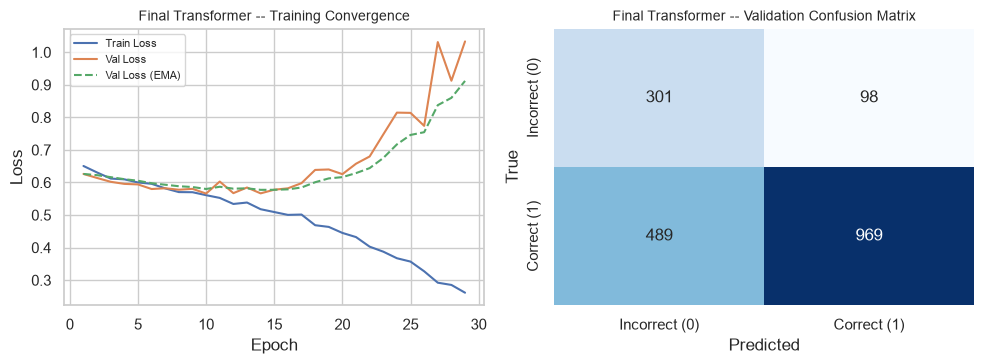

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
plot_training_curves(lpt_final_train_losses, lpt_final_val_losses, lpt_final_val_loss_emas,
                      title='Final Transformer -- Training Convergence', ax=axes[0])
plot_confusion_matrix(lpt_final_val_metrics['confusion_matrix'],
                       title='Final Transformer -- Validation Confusion Matrix', ax=axes[1])
fig.tight_layout()
plt.show()

In [50]:
lpt_final_test_loader = create_dataloader(test_df, features, batch_size=selected_lpt_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

lpt_final_test_metrics = evaluate_model(lpt_final_model, lpt_final_test_loader, lpt_final_criterion, lpt_final_device)

print("=== Final Transformer Model -- Test Set Evaluation (this track's first and only test-set contact) ===")
print(f"Test Loss:        {lpt_final_test_metrics['loss']:.4f}")
print(f"Test Macro F1:    {lpt_final_test_metrics['macro_f1']:.4f}")
print(f"Test F1 (class0): {lpt_final_test_metrics['f1_class0']:.4f}")
print(f"Test F1 (class1): {lpt_final_test_metrics['f1_class1']:.4f}")
print(f"Test ROC-AUC:     {lpt_final_test_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(lpt_final_test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

=== Final Transformer Model -- Test Set Evaluation (this track's first and only test-set contact) ===
Test Loss:        0.6350
Test Macro F1:    0.6261
Test F1 (class0): 0.5008
Test F1 (class1): 0.7514
Test ROC-AUC:     0.7383
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     309     138
True 1     478     931


### Section 5.5c: Final Transformer Model -- Test Confusion Matrix

Renders the final Transformer model's test-set confusion matrix (`lpt_final_test_metrics['confusion_matrix']`, computed in the cell above) as a heatmap.

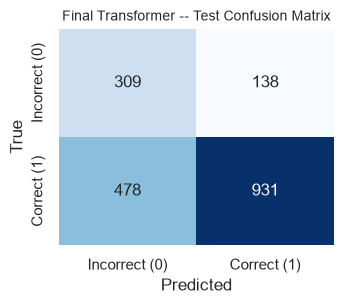

In [51]:
plot_confusion_matrix(lpt_final_test_metrics['confusion_matrix'],
                       title='Final Transformer -- Test Confusion Matrix')

### Section 5.9a: Backbone vs. `linear_per_timestep` -- A Second Test-Set Touch to Resolve the Tokenizer Discrepancy

Section 5.3e's mechanical fallback establishes that this run's architecture ablation favors `backbone` over `linear_per_timestep` on validation data (val_loss 0.5743 vs. 0.5957 during the ablation), but only `linear_per_timestep` has we only implement a dedicated hyperparameter search, so Section 5.5a's "final model" trained and tested that one instead`backbone` does not need a hyperparameter search of its own, though because it has no other hyperparameters beyond what Section 5.2a's S6.2 search already tunes (unlike `linear_per_timestep`, which needed extra tokenizer-specific hyperparameters that has never been explored).

Here, we show that `backbone_final_model` is retrained from scratch here, because Section 5.3d's ablation trains `backbone` as the first of six models sharing one loop, with no reseed between them.

#### Section 5.9b: Standalone Backbone Final Model -- Validation

We retrain `EyeMovementTransformer` from scratch using Section 5.2a's `selected_hp`, with the same prcoess as Section 5.5a's `lpt_final_model` cell exactly.

In [52]:
set_seed(69)

backbone_final_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

backbone_final_train_loader = create_dataloader(train_df, features, batch_size=selected_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
backbone_final_val_loader = create_dataloader(val_df, features, batch_size=selected_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

backbone_final_train_labels = np.array([label for _, label, _ in backbone_final_train_loader.dataset])
backbone_final_class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(backbone_final_train_labels), y=backbone_final_train_labels
)
backbone_final_class_weights_tensor = torch.tensor(backbone_final_class_weights, dtype=torch.float32).to(backbone_final_device)
backbone_final_criterion = nn.CrossEntropyLoss(weight=backbone_final_class_weights_tensor)

backbone_final_model = EyeMovementTransformer(
    n_features=N_FEATURES,
    patch_kernel_size=selected_hp['patch_kernel_size'],
    patch_stride=selected_hp['patch_stride'],
    patch_out_channels=selected_hp['patch_out_channels'],
    num_encoder_layers=selected_hp['num_encoder_layers'],
    num_attention_heads=selected_hp['num_attention_heads'],
    ffn_hidden_dim=selected_hp['ffn_hidden_dim'],
    num_fc_layers=selected_hp['num_fc_layers'],
    fc_hidden_size=selected_hp['fc_hidden_size'],
    attention_dropout=selected_hp['attention_dropout'],
    fc_dropout=selected_hp['fc_dropout'],
).to(backbone_final_device)

backbone_final_optimizer = optim.Adam(backbone_final_model.parameters(), lr=selected_hp['learning_rate'])

backbone_final_model, backbone_final_best_val_loss, backbone_final_train_losses, backbone_final_val_losses, backbone_final_val_loss_emas = train_with_early_stopping(
    backbone_final_model, backbone_final_train_loader, backbone_final_val_loader, backbone_final_optimizer, backbone_final_criterion, backbone_final_device,
    max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
)

backbone_final_val_metrics = evaluate_model(backbone_final_model, backbone_final_val_loader, backbone_final_criterion, backbone_final_device)

ablation_backbone_val_loss = ablation_results_df.loc[ablation_results_df['model'] == 'backbone', 'best_val_loss'].iloc[0]
print(f"Standalone backbone final model -- best_val_loss={backbone_final_best_val_loss:.4f} "
      f"(ablation's own backbone run: val_loss={ablation_backbone_val_loss:.4f})")
print(f"Val Loss:        {backbone_final_val_metrics['loss']:.4f}")
print(f"Val Macro F1:    {backbone_final_val_metrics['macro_f1']:.4f}")
print(f"Val F1 (class0): {backbone_final_val_metrics['f1_class0']:.4f}")
print(f"Val F1 (class1): {backbone_final_val_metrics['f1_class1']:.4f}")
print(f"Val ROC-AUC:     {backbone_final_val_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(backbone_final_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\3150370329.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6647 | val_loss=0.6325 | val_loss_ema=0.6325
Epoch   2/200 | train_loss=0.6433 | val_loss=0.6549 | val_loss_ema=0.6392
Epoch   3/200 | train_loss=0.6117 | val_loss=0.6000 | val_loss_ema=0.6274
Epoch   4/200 | train_loss=0.6188 | val_loss=0.6215 | val_loss_ema=0.6257
Epoch   5/200 | train_loss=0.6072 | val_loss=0.5869 | val_loss_ema=0.6140
Epoch   6/200 | train_loss=0.5933 | val_loss=0.5911 | val_loss_ema=0.6071
Epoch   7/200 | train_loss=0.5698 | val_loss=0.6006 | val_loss_ema=0.6052
Epoch   8/200 | train_loss=0.5793 | val_loss=0.5802 | val_loss_ema=0.5977
Epoch   9/200 | train_loss=0.5504 | val_loss=0.6141 | val_loss_ema=0.6026
Epoch  10/200 | train_loss=0.5463 | val_loss=0.5855 | val_loss_ema=0.5975
Epoch  11/200 | train_loss=0.5353 | val_loss=0.6532 | val_loss_ema=0.6142
Epoch  12/200 | train_loss=0.5369 | val_loss=0.6091 | val_loss_ema=0.6127
Epoch  13/200 | train_loss=0.5123 | val_loss=0.6164 | val_loss_ema=0.6138
Epoch  14/200 | train_loss=0.4980 | va

#### Section 5.9c: Standalone Backbone Final Model -- Training Curves and Validation Confusion Matrix

We visualize `backbone_final_model`'s optimization behavior and validation-set performance.

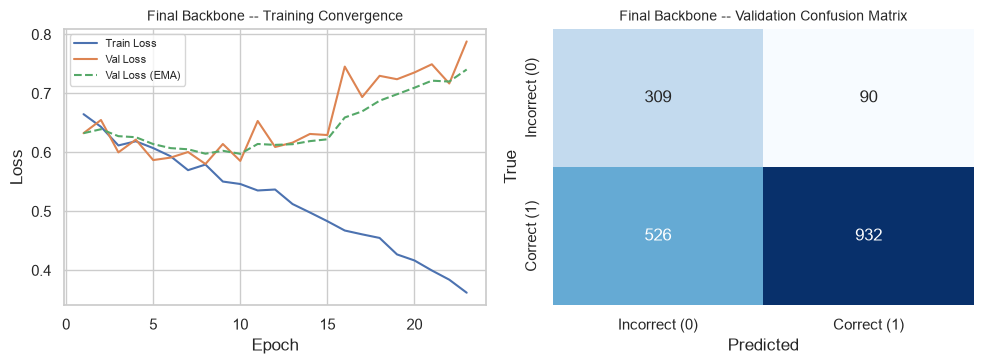

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
plot_training_curves(backbone_final_train_losses, backbone_final_val_losses, backbone_final_val_loss_emas,
                      title='Final Backbone -- Training Convergence', ax=axes[0])
plot_confusion_matrix(backbone_final_val_metrics['confusion_matrix'],
                       title='Final Backbone -- Validation Confusion Matrix', ax=axes[1])
fig.tight_layout()
plt.show()

#### Section 5.9d: Standalone Backbone Final Model -- Test Set Evaluation and Comparison

We show `backbone_final_model`'s single test-set touch, immediately followed by the side-by-side comparison against `lpt_final_test_metrics` (already computed in Section 5.5a) to show the actual results of this whole section.

In [54]:
backbone_final_test_loader = create_dataloader(test_df, features, batch_size=selected_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

backbone_final_test_metrics = evaluate_model(backbone_final_model, backbone_final_test_loader, backbone_final_criterion, backbone_final_device)

print("=== Standalone Backbone Final Model -- Test Set Evaluation ===")
print(f"Test Loss:        {backbone_final_test_metrics['loss']:.4f}")
print(f"Test Macro F1:    {backbone_final_test_metrics['macro_f1']:.4f}")
print(f"Test F1 (class0): {backbone_final_test_metrics['f1_class0']:.4f}")
print(f"Test F1 (class1): {backbone_final_test_metrics['f1_class1']:.4f}")
print(f"Test ROC-AUC:     {backbone_final_test_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(backbone_final_test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Backbone vs. linear_per_timestep -- Test Summary ===")
tokenizer_comparison_rows = {
    'backbone (true ablation winner, standalone retrain)': {
        'test_loss': backbone_final_test_metrics['loss'],
        'test_macro_f1': backbone_final_test_metrics['macro_f1'],
        'test_f1_class0': backbone_final_test_metrics['f1_class0'],
        'test_f1_class1': backbone_final_test_metrics['f1_class1'],
        'test_roc_auc': backbone_final_test_metrics['roc_auc'],
    },
    'linear_per_timestep (tooled fallback)': {
        'test_loss': lpt_final_test_metrics['loss'],
        'test_macro_f1': lpt_final_test_metrics['macro_f1'],
        'test_f1_class0': lpt_final_test_metrics['f1_class0'],
        'test_f1_class1': lpt_final_test_metrics['f1_class1'],
        'test_roc_auc': lpt_final_test_metrics['roc_auc'],
    },
}
tokenizer_comparison_df = pd.DataFrame(tokenizer_comparison_rows).T
display(tokenizer_comparison_df)

=== Standalone Backbone Final Model -- Test Set Evaluation ===
Test Loss:        0.6182
Test Macro F1:    0.6229
Test F1 (class0): 0.5028
Test F1 (class1): 0.7430
Test ROC-AUC:     0.7320
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     318     129
True 1     500     909

=== Backbone vs. linear_per_timestep -- Test Summary ===


,test_loss,test_macro_f1,test_f1_class0,test_f1_class1,test_roc_auc
"backbone (true ablation winner, standalone retrain)",0.6182,0.6229,0.5028,0.7430,0.7320
linear_per_timestep (tooled fallback),0.6350,0.6261,0.5008,0.7514,0.7383


We visualize the comparison above: each tokenizer's test confusion matrix side by side, plus a grouped bar chart of test Macro F1 and ROC-AUC.

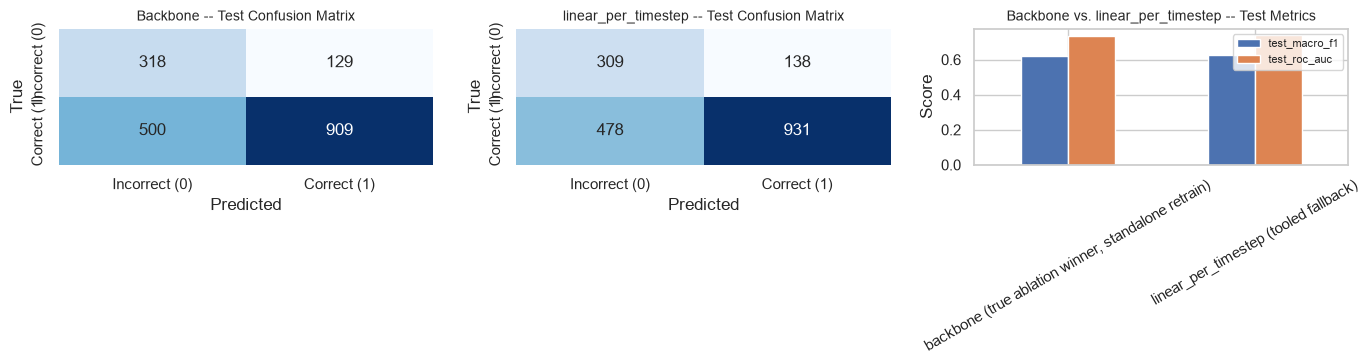

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
plot_confusion_matrix(backbone_final_test_metrics['confusion_matrix'], title='Backbone -- Test Confusion Matrix', ax=axes[0])
plot_confusion_matrix(lpt_final_test_metrics['confusion_matrix'], title='linear_per_timestep -- Test Confusion Matrix', ax=axes[1])
plot_grouped_metric_comparison(
    tokenizer_comparison_df, metrics=['test_macro_f1', 'test_roc_auc'],
    title='Backbone vs. linear_per_timestep -- Test Metrics', ax=axes[2],
)
fig.tight_layout()
plt.show()

### Section 5.6a: Data Ablation 1 (Transformer) -- Fixations vs. Saccades

For transformers, we too filter trials down to only fixation events (`eventType == 1`) or only saccade events (`eventType == 0`) before the trial-grouping step, then retrains the final model's exact architecture and hyperparameters (`selected_lpt_hp`) unchanged -- only sequence length is affected (each trial keeps roughly half its rows), the feature count stays at 15, so `d_model` and every other architecture-defining hyperparameter carry over as-is. The existing final model (`lpt_final_*`)
already *is* the "both events" condition, so this only needs two new training runs likewise.

We also notice that several columns become near-constant filler within a single-event-type subset (e.g. `startSaccadeX/Y` stay at their fill value throughout a fixations-only trial, and vice versa for fixation-specific columns during a saccades-only trial) -- this doesn't break anything, it just means fewer of the 15 input dimensions carry live information for either condition.

In [56]:
EVENT_TYPE_CONDITIONS = {'fixations_only': 1, 'saccades_only': 0}

lpt_event_results = {}
for name, event_value in EVENT_TYPE_CONDITIONS.items():
    print(f"\n{'=' * 80}\nData Ablation 1 -- {name} (eventType == {event_value})\n{'=' * 80}")

    cond_train_df = train_df[train_df['eventType'] == event_value]
    cond_val_df = val_df[val_df['eventType'] == event_value]
    cond_test_df = test_df[test_df['eventType'] == event_value]

    cond_train_loader = create_dataloader(cond_train_df, features, batch_size=selected_lpt_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
    cond_val_loader = create_dataloader(cond_val_df, features, batch_size=selected_lpt_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)
    cond_test_loader = create_dataloader(cond_test_df, features, batch_size=selected_lpt_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

    print(f"Trials: train={len(cond_train_loader.dataset)}, val={len(cond_val_loader.dataset)}, test={len(cond_test_loader.dataset)} "
          f"(baseline both-events: train={len(lpt_final_train_loader.dataset)}, val={len(lpt_final_val_loader.dataset)}, "
          f"test={len(lpt_final_test_loader.dataset)})")

    cond_train_labels = np.array([label for _, label, _ in cond_train_loader.dataset])
    cond_class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(cond_train_labels), y=cond_train_labels)
    cond_class_weights_tensor = torch.tensor(cond_class_weights, dtype=torch.float32).to(lpt_final_device)
    cond_criterion = nn.CrossEntropyLoss(weight=cond_class_weights_tensor)

    set_seed(69)
    cond_tokenizer = LinearPerTimestepTokenizer(
        n_features=N_FEATURES,
        d_model=selected_lpt_hp['d_model'],
        hidden_size=selected_lpt_hp['tokenizer_hidden_size'],
        dropout=selected_lpt_hp['tokenizer_dropout'],
        gate_type=selected_lpt_hp['gate_type'],
    )
    cond_model = TokenizerTransformer(
        tokenizer=cond_tokenizer,
        num_encoder_layers=selected_lpt_hp['num_encoder_layers'],
        num_attention_heads=selected_lpt_hp['num_attention_heads'],
        ffn_hidden_dim=selected_lpt_hp['ffn_hidden_dim'],
        num_fc_layers=selected_lpt_hp['num_fc_layers'],
        fc_hidden_size=selected_lpt_hp['fc_hidden_size'],
        attention_dropout=selected_lpt_hp['attention_dropout'],
        fc_dropout=selected_lpt_hp['fc_dropout'],
    ).to(lpt_final_device)

    cond_optimizer = optim.Adam(cond_model.parameters(), lr=selected_lpt_hp['learning_rate'])

    cond_model, cond_best_val_loss, cond_train_losses, cond_val_losses, cond_val_loss_emas = train_with_early_stopping(
        cond_model, cond_train_loader, cond_val_loader, cond_optimizer, cond_criterion, lpt_final_device,
        max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
    )

    cond_val_metrics = evaluate_model(cond_model, cond_val_loader, cond_criterion, lpt_final_device)
    lpt_event_results[name] = {
        'model': cond_model, 'criterion': cond_criterion, 'test_loader': cond_test_loader, 'val_metrics': cond_val_metrics,
    }

    print(f"Val Loss:        {cond_val_metrics['loss']:.4f}")
    print(f"Val Macro F1:    {cond_val_metrics['macro_f1']:.4f}")
    print(f"Val F1 (class0): {cond_val_metrics['f1_class0']:.4f}")
    print(f"Val F1 (class1): {cond_val_metrics['f1_class1']:.4f}")
    print(f"Val ROC-AUC:     {cond_val_metrics['roc_auc']:.4f}")
    print("Confusion Matrix (rows=true, cols=pred):")
    print(pd.DataFrame(cond_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Data Ablation 1: Validation Summary (vs. the final model's both-events baseline) ===")
lpt_event_val_rows = {
    name: {
        'val_loss': r['val_metrics']['loss'],
        'val_macro_f1': r['val_metrics']['macro_f1'],
        'val_f1_class0': r['val_metrics']['f1_class0'],
        'val_f1_class1': r['val_metrics']['f1_class1'],
        'val_roc_auc': r['val_metrics']['roc_auc'],
    }
    for name, r in lpt_event_results.items()
}
lpt_event_val_rows['both_events_baseline'] = {
    'val_loss': lpt_final_val_metrics['loss'],
    'val_macro_f1': lpt_final_val_metrics['macro_f1'],
    'val_f1_class0': lpt_final_val_metrics['f1_class0'],
    'val_f1_class1': lpt_final_val_metrics['f1_class1'],
    'val_roc_auc': lpt_final_val_metrics['roc_auc'],
}
lpt_event_val_summary = pd.DataFrame(lpt_event_val_rows).T
display(lpt_event_val_summary)


Data Ablation 1 -- fixations_only (eventType == 1)
Trials: train=5465, val=1857, test=1855 (baseline both-events: train=5465, val=1857, test=1856)


C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6493 | val_loss=0.6131 | val_loss_ema=0.6131
Epoch   2/200 | train_loss=0.6221 | val_loss=0.6038 | val_loss_ema=0.6103
Epoch   3/200 | train_loss=0.6133 | val_loss=0.6053 | val_loss_ema=0.6088
Epoch   4/200 | train_loss=0.6081 | val_loss=0.6023 | val_loss_ema=0.6069
Epoch   5/200 | train_loss=0.6014 | val_loss=0.6176 | val_loss_ema=0.6101
Epoch   6/200 | train_loss=0.6081 | val_loss=0.5986 | val_loss_ema=0.6067
Epoch   7/200 | train_loss=0.5880 | val_loss=0.6080 | val_loss_ema=0.6071
Epoch   8/200 | train_loss=0.5828 | val_loss=0.5777 | val_loss_ema=0.5983
Epoch   9/200 | train_loss=0.5766 | val_loss=0.5769 | val_loss_ema=0.5918
Epoch  10/200 | train_loss=0.5565 | val_loss=0.5847 | val_loss_ema=0.5897
Epoch  11/200 | train_loss=0.5566 | val_loss=0.6360 | val_loss_ema=0.6036
Epoch  12/200 | train_loss=0.5386 | val_loss=0.5919 | val_loss_ema=0.6001
Epoch  13/200 | train_loss=0.5259 | val_loss=0.6310 | val_loss_ema=0.6094
Epoch  14/200 | train_loss=0.5099 | va

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6605 | val_loss=0.6391 | val_loss_ema=0.6391
Epoch   2/200 | train_loss=0.6295 | val_loss=0.6099 | val_loss_ema=0.6303
Epoch   3/200 | train_loss=0.6149 | val_loss=0.5999 | val_loss_ema=0.6212
Epoch   4/200 | train_loss=0.6056 | val_loss=0.6096 | val_loss_ema=0.6177
Epoch   5/200 | train_loss=0.5964 | val_loss=0.5987 | val_loss_ema=0.6120
Epoch   6/200 | train_loss=0.5945 | val_loss=0.5850 | val_loss_ema=0.6039
Epoch   7/200 | train_loss=0.5896 | val_loss=0.5931 | val_loss_ema=0.6007
Epoch   8/200 | train_loss=0.5849 | val_loss=0.5799 | val_loss_ema=0.5944
Epoch   9/200 | train_loss=0.5793 | val_loss=0.5796 | val_loss_ema=0.5900
Epoch  10/200 | train_loss=0.5770 | val_loss=0.5814 | val_loss_ema=0.5874
Epoch  11/200 | train_loss=0.5626 | val_loss=0.6055 | val_loss_ema=0.5928
Epoch  12/200 | train_loss=0.5569 | val_loss=0.5792 | val_loss_ema=0.5888
Epoch  13/200 | train_loss=0.5525 | val_loss=0.5841 | val_loss_ema=0.5874
Epoch  14/200 | train_loss=0.5445 | va

,val_loss,val_macro_f1,val_f1_class0,val_f1_class1,val_roc_auc
fixations_only,0.5847,0.6102,0.4891,0.7313,0.7600
saccades_only,0.5773,0.6385,0.5030,0.7740,0.7695
both_events_baseline,0.5666,0.6369,0.5063,0.7675,0.7855


In [57]:
for name, r in lpt_event_results.items():
    test_metrics = evaluate_model(r['model'], r['test_loader'], r['criterion'], lpt_final_device)
    r['test_metrics'] = test_metrics

    print(f"\nData Ablation 1 -- {name} -- Test Set Evaluation")
    print(f"Test Loss:        {test_metrics['loss']:.4f}")
    print(f"Test Macro F1:    {test_metrics['macro_f1']:.4f}")
    print(f"Test F1 (class0): {test_metrics['f1_class0']:.4f}")
    print(f"Test F1 (class1): {test_metrics['f1_class1']:.4f}")
    print(f"Test ROC-AUC:     {test_metrics['roc_auc']:.4f}")
    print("Confusion Matrix (rows=true, cols=pred):")
    print(pd.DataFrame(test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Data Ablation 1: Test Summary (vs. the final model's both-events baseline) ===")
lpt_event_test_rows = {
    name: {
        'test_loss': r['test_metrics']['loss'],
        'test_macro_f1': r['test_metrics']['macro_f1'],
        'test_f1_class0': r['test_metrics']['f1_class0'],
        'test_f1_class1': r['test_metrics']['f1_class1'],
        'test_roc_auc': r['test_metrics']['roc_auc'],
    }
    for name, r in lpt_event_results.items()
}
lpt_event_test_rows['both_events_baseline'] = {
    'test_loss': lpt_final_test_metrics['loss'],
    'test_macro_f1': lpt_final_test_metrics['macro_f1'],
    'test_f1_class0': lpt_final_test_metrics['f1_class0'],
    'test_f1_class1': lpt_final_test_metrics['f1_class1'],
    'test_roc_auc': lpt_final_test_metrics['roc_auc'],
}
lpt_event_test_summary = pd.DataFrame(lpt_event_test_rows).T
display(lpt_event_test_summary)


Data Ablation 1 -- fixations_only -- Test Set Evaluation
Test Loss:        0.6232
Test Macro F1:    0.5969
Test F1 (class0): 0.4878
Test F1 (class1): 0.7060
Test ROC-AUC:     0.7106
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     330     116
True 1     577     832

Data Ablation 1 -- saccades_only -- Test Set Evaluation
Test Loss:        0.6237
Test Macro F1:    0.6227
Test F1 (class0): 0.4829
Test F1 (class1): 0.7626
Test ROC-AUC:     0.7292
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     282     165
True 1     439     970

=== Data Ablation 1: Test Summary (vs. the final model's both-events baseline) ===


,test_loss,test_macro_f1,test_f1_class0,test_f1_class1,test_roc_auc
fixations_only,0.6232,0.5969,0.4878,0.7060,0.7106
saccades_only,0.6237,0.6227,0.4829,0.7626,0.7292
both_events_baseline,0.6350,0.6261,0.5008,0.7514,0.7383


### Section 5.7a: Data Ablation 2 (Transformer) -- Coordinate-Free Features (Testing-Environment-Agnostic)

Like for RNN and RNN with Attention, we also study whether saccade amplitude can be reported without reference to screen-specific pixel coordinates: modern eye-tracking software (e.g. EyeLink Data Viewer, Tobii systems) computes and exports saccade amplitude natively in degrees of visual angle, using the same distance-to-screen and screen-size calibration every eye-tracking study performs regardless of application -- unlike raw `meanX`/`meanY` screen coordinates, it isn't tied to this particular study's pixel layout. `saccadeAmplitude` is kept; the 6 raw pixel-coordinate columns (`meanX`, `meanY`, `startSaccadeX/Y`, `endSaccadeX/Y`) are dropped, leaving 9 of the original 15 features.

Here we show that `LinearPerTimestepTokenizer` needs no code changes, as it already takes `n_features` as a constructor argument. What does need *attention*: `d_model = expansion * n_features` shrinks (120 -> 72) since `expansion` is held fixed, and the final model's `fc_hidden_size`/`ffn_hidden_dim` were tuned as *ratios* of d_model (1x and 4x respectively), not as independent values so we both recompute relative to the new d_model to preserve those tuned proportions, instead of reusing the old literal 120/480 (which would otherwise silently widen the FC head relative to the encoder's own representation width).

In [58]:
print(f"Coordinate-free feature set ({N_FEATURES_NO_COORDS} features): {features_no_coords}")

# Recomputed relative to the new feature count so the final model's tuned fc_hidden_size==d_model and
# ffn_hidden_dim==4*d_model ratios carry over, rather than reusing the old literal 120/480.
coord_free_d_model = selected_lpt_hp['expansion'] * N_FEATURES_NO_COORDS
coord_free_fc_hidden_size = coord_free_d_model
coord_free_ffn_hidden_dim = 4 * coord_free_d_model

assert coord_free_d_model % selected_lpt_hp['num_attention_heads'] == 0, (
    f"coord_free_d_model ({coord_free_d_model}) must be divisible by num_attention_heads "
    f"({selected_lpt_hp['num_attention_heads']}); got remainder "
    f"{coord_free_d_model % selected_lpt_hp['num_attention_heads']}."
)
print(f"New d_model={coord_free_d_model}, fc_hidden_size={coord_free_fc_hidden_size}, ffn_hidden_dim={coord_free_ffn_hidden_dim}")

lpt_coordfree_train_loader = create_dataloader(train_df, features_no_coords, batch_size=selected_lpt_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
lpt_coordfree_val_loader = create_dataloader(val_df, features_no_coords, batch_size=selected_lpt_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)
lpt_coordfree_test_loader = create_dataloader(test_df, features_no_coords, batch_size=selected_lpt_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

lpt_coordfree_train_labels = np.array([label for _, label, _ in lpt_coordfree_train_loader.dataset])
lpt_coordfree_class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(lpt_coordfree_train_labels), y=lpt_coordfree_train_labels
)
lpt_coordfree_class_weights_tensor = torch.tensor(lpt_coordfree_class_weights, dtype=torch.float32).to(lpt_final_device)
lpt_coordfree_criterion = nn.CrossEntropyLoss(weight=lpt_coordfree_class_weights_tensor)

set_seed(69)
lpt_coordfree_tokenizer = LinearPerTimestepTokenizer(
    n_features=N_FEATURES_NO_COORDS,
    d_model=coord_free_d_model,
    hidden_size=selected_lpt_hp['tokenizer_hidden_size'],
    dropout=selected_lpt_hp['tokenizer_dropout'],
    gate_type=selected_lpt_hp['gate_type'],
)
lpt_coordfree_model = TokenizerTransformer(
    tokenizer=lpt_coordfree_tokenizer,
    num_encoder_layers=selected_lpt_hp['num_encoder_layers'],
    num_attention_heads=selected_lpt_hp['num_attention_heads'],
    ffn_hidden_dim=coord_free_ffn_hidden_dim,
    num_fc_layers=selected_lpt_hp['num_fc_layers'],
    fc_hidden_size=coord_free_fc_hidden_size,
    attention_dropout=selected_lpt_hp['attention_dropout'],
    fc_dropout=selected_lpt_hp['fc_dropout'],
).to(lpt_final_device)

lpt_coordfree_optimizer = optim.Adam(lpt_coordfree_model.parameters(), lr=selected_lpt_hp['learning_rate'])

lpt_coordfree_model, lpt_coordfree_best_val_loss, lpt_coordfree_train_losses, lpt_coordfree_val_losses, lpt_coordfree_val_loss_emas = train_with_early_stopping(
    lpt_coordfree_model, lpt_coordfree_train_loader, lpt_coordfree_val_loader, lpt_coordfree_optimizer, lpt_coordfree_criterion, lpt_final_device,
    max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
)

lpt_coordfree_val_metrics = evaluate_model(lpt_coordfree_model, lpt_coordfree_val_loader, lpt_coordfree_criterion, lpt_final_device)

print(f"\nData Ablation 2 (coordinate-free, {N_FEATURES_NO_COORDS} features) -- Validation")
print(f"Val Loss:        {lpt_coordfree_val_metrics['loss']:.4f}")
print(f"Val Macro F1:    {lpt_coordfree_val_metrics['macro_f1']:.4f}")
print(f"Val F1 (class0): {lpt_coordfree_val_metrics['f1_class0']:.4f}")
print(f"Val F1 (class1): {lpt_coordfree_val_metrics['f1_class1']:.4f}")
print(f"Val ROC-AUC:     {lpt_coordfree_val_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(lpt_coordfree_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print(f"\nFor comparison, final model (15 features): val macro F1={lpt_final_val_metrics['macro_f1']:.4f}, "
      f"val F1 class0={lpt_final_val_metrics['f1_class0']:.4f}, val ROC-AUC={lpt_final_val_metrics['roc_auc']:.4f}")

Coordinate-free feature set (9 features): ['eventType', 'timeSinceStart', 'eye', 'duration', 'meanPupilDiameter', 'microsaccadeCount', 'microsaccadeAmplitude', 'microsaccadePeakVelocity', 'saccadeAmplitude']
New d_model=72, fc_hidden_size=72, ffn_hidden_dim=288


C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6637 | val_loss=0.6200 | val_loss_ema=0.6200
Epoch   2/200 | train_loss=0.6258 | val_loss=0.6118 | val_loss_ema=0.6175
Epoch   3/200 | train_loss=0.6154 | val_loss=0.6139 | val_loss_ema=0.6164
Epoch   4/200 | train_loss=0.6116 | val_loss=0.6085 | val_loss_ema=0.6140
Epoch   5/200 | train_loss=0.6119 | val_loss=0.6072 | val_loss_ema=0.6120
Epoch   6/200 | train_loss=0.6118 | val_loss=0.6060 | val_loss_ema=0.6102
Epoch   7/200 | train_loss=0.5998 | val_loss=0.6111 | val_loss_ema=0.6105
Epoch   8/200 | train_loss=0.6079 | val_loss=0.6059 | val_loss_ema=0.6091
Epoch   9/200 | train_loss=0.5954 | val_loss=0.6033 | val_loss_ema=0.6074
Epoch  10/200 | train_loss=0.6028 | val_loss=0.6065 | val_loss_ema=0.6071
Epoch  11/200 | train_loss=0.5971 | val_loss=0.6012 | val_loss_ema=0.6053
Epoch  12/200 | train_loss=0.5889 | val_loss=0.5988 | val_loss_ema=0.6034
Epoch  13/200 | train_loss=0.5888 | val_loss=0.6243 | val_loss_ema=0.6097
Epoch  14/200 | train_loss=0.5906 | va

In [59]:
lpt_coordfree_test_metrics = evaluate_model(lpt_coordfree_model, lpt_coordfree_test_loader, lpt_coordfree_criterion, lpt_final_device)

print(f"Data Ablation 2 (coordinate-free, {N_FEATURES_NO_COORDS} features) -- Test Set Evaluation")
print(f"Test Loss:        {lpt_coordfree_test_metrics['loss']:.4f}")
print(f"Test Macro F1:    {lpt_coordfree_test_metrics['macro_f1']:.4f}")
print(f"Test F1 (class0): {lpt_coordfree_test_metrics['f1_class0']:.4f}")
print(f"Test F1 (class1): {lpt_coordfree_test_metrics['f1_class1']:.4f}")
print(f"Test ROC-AUC:     {lpt_coordfree_test_metrics['roc_auc']:.4f}")
print("Confusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(lpt_coordfree_test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print(f"\nFor comparison, final model (15 features): test macro F1={lpt_final_test_metrics['macro_f1']:.4f}, "
      f"test F1 class0={lpt_final_test_metrics['f1_class0']:.4f}, test ROC-AUC={lpt_final_test_metrics['roc_auc']:.4f}")

Data Ablation 2 (coordinate-free, 9 features) -- Test Set Evaluation
Test Loss:        0.6153
Test Macro F1:    0.6041
Test F1 (class0): 0.4940
Test F1 (class1): 0.7142
Test ROC-AUC:     0.7201
Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0     331     116
True 1     562     847

For comparison, final model (15 features): test macro F1=0.6261, test F1 class0=0.5008, test ROC-AUC=0.7383


### Section 5.8a: Data Ablation 3 (Transformer) -- Per-Task Specialization

Similarly, for the Transformer track, we train one model per task block (`block_1`..`block_4` -- Series Continuation, Classifications, Matrices, Topological Conclusions), each using the final model's selected architecture but only that block's trials, to test whether knowing the test-time task lets a specialist beat the general model. Architecture and hyperparameters are unchanged from `selected_lpt_hp`; only the training data is restricted.

The generalist's comparison numbers are recomputed *per block* here (re-scoring the existing `lpt_final_model` on each block's own val/test subset), not reused from its overall aggregate metrics reported earlier, as comparing a specialist's block-specific performance against the generalist's *overall* performance would be comparing different populations. Each specialist also gets its own from-scratch class weights, since task difficulty (and therefore class balance) isn't guaranteed to match the pooled dataset's. Each specialist trains on roughly a quarter of the pooled training data (~1,350 vs. ~5,425 trials), which is worth keeping in mind when interpreting any specialist-vs-generalist gap -- some of it could just be a data-volume effect rather than actual task-specific signal.

In [60]:
lpt_task_results = {}
for block in TASK_BLOCKS:
    print(f"\n{'=' * 80}\nData Ablation 3 -- {block}\n{'=' * 80}")

    block_train_df = train_df[train_df[block] == 1]
    block_val_df = val_df[val_df[block] == 1]
    block_test_df = test_df[test_df[block] == 1]

    block_train_loader = create_dataloader(block_train_df, features, batch_size=selected_lpt_hp['batch_size'], shuffle=True, max_seq_len=MAX_SEQ_LEN)
    block_val_loader = create_dataloader(block_val_df, features, batch_size=selected_lpt_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)
    block_test_loader = create_dataloader(block_test_df, features, batch_size=selected_lpt_hp['batch_size'], shuffle=False, max_seq_len=MAX_SEQ_LEN)

    print(f"Trials: train={len(block_train_loader.dataset)}, val={len(block_val_loader.dataset)}, test={len(block_test_loader.dataset)}")

    block_train_labels = np.array([label for _, label, _ in block_train_loader.dataset])
    block_class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(block_train_labels), y=block_train_labels)
    block_class_weights_tensor = torch.tensor(block_class_weights, dtype=torch.float32).to(lpt_final_device)
    block_criterion = nn.CrossEntropyLoss(weight=block_class_weights_tensor)

    set_seed(69)
    block_tokenizer = LinearPerTimestepTokenizer(
        n_features=N_FEATURES,
        d_model=selected_lpt_hp['d_model'],
        hidden_size=selected_lpt_hp['tokenizer_hidden_size'],
        dropout=selected_lpt_hp['tokenizer_dropout'],
        gate_type=selected_lpt_hp['gate_type'],
    )
    block_model = TokenizerTransformer(
        tokenizer=block_tokenizer,
        num_encoder_layers=selected_lpt_hp['num_encoder_layers'],
        num_attention_heads=selected_lpt_hp['num_attention_heads'],
        ffn_hidden_dim=selected_lpt_hp['ffn_hidden_dim'],
        num_fc_layers=selected_lpt_hp['num_fc_layers'],
        fc_hidden_size=selected_lpt_hp['fc_hidden_size'],
        attention_dropout=selected_lpt_hp['attention_dropout'],
        fc_dropout=selected_lpt_hp['fc_dropout'],
    ).to(lpt_final_device)

    block_optimizer = optim.Adam(block_model.parameters(), lr=selected_lpt_hp['learning_rate'])

    block_model, block_best_val_loss, block_train_losses, block_val_losses, block_val_loss_emas = train_with_early_stopping(
        block_model, block_train_loader, block_val_loader, block_optimizer, block_criterion, lpt_final_device,
        max_epochs=TUNING_MAX_EPOCHS, patience=TUNING_PATIENCE, min_delta=TUNING_MIN_DELTA,
    )

    block_val_metrics = evaluate_model(block_model, block_val_loader, block_criterion, lpt_final_device)

    # Generalist comparison: the already-trained final model, re-scored on this block's val
    # subset only -- NOT its overall aggregate metrics, which would be a different population.
    general_block_val_metrics = evaluate_model(lpt_final_model, block_val_loader, lpt_final_criterion, lpt_final_device)

    lpt_task_results[block] = {
        'model': block_model, 'criterion': block_criterion, 'test_loader': block_test_loader,
        'specialist_val_metrics': block_val_metrics, 'general_val_metrics': general_block_val_metrics,
    }

    print(f"Specialist -- Val Loss: {block_val_metrics['loss']:.4f} | Val Macro F1: {block_val_metrics['macro_f1']:.4f} | "
          f"Val F1 class0: {block_val_metrics['f1_class0']:.4f} | Val F1 class1: {block_val_metrics['f1_class1']:.4f} | "
          f"Val ROC-AUC: {block_val_metrics['roc_auc']:.4f}")
    print(f"Generalist (scored on this block only) -- Val Macro F1: {general_block_val_metrics['macro_f1']:.4f} | "
          f"Val F1 class0: {general_block_val_metrics['f1_class0']:.4f} | Val F1 class1: {general_block_val_metrics['f1_class1']:.4f} | "
          f"Val ROC-AUC: {general_block_val_metrics['roc_auc']:.4f}")
    print("Specialist Confusion Matrix (rows=true, cols=pred):")
    print(pd.DataFrame(block_val_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Data Ablation 3: Validation Summary -- Specialist vs. Generalist per Block ===")
lpt_task_val_rows = {}
for block, r in lpt_task_results.items():
    lpt_task_val_rows[f"{block}_specialist"] = {
        'val_macro_f1': r['specialist_val_metrics']['macro_f1'],
        'val_f1_class0': r['specialist_val_metrics']['f1_class0'],
        'val_f1_class1': r['specialist_val_metrics']['f1_class1'],
        'val_roc_auc': r['specialist_val_metrics']['roc_auc'],
    }
    lpt_task_val_rows[f"{block}_generalist"] = {
        'val_macro_f1': r['general_val_metrics']['macro_f1'],
        'val_f1_class0': r['general_val_metrics']['f1_class0'],
        'val_f1_class1': r['general_val_metrics']['f1_class1'],
        'val_roc_auc': r['general_val_metrics']['roc_auc'],
    }
lpt_task_val_summary = pd.DataFrame(lpt_task_val_rows).T
display(lpt_task_val_summary)


Data Ablation 3 -- block_1
Trials: train=1540, val=524, test=519


C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6675 | val_loss=0.5832 | val_loss_ema=0.5832
Epoch   2/200 | train_loss=0.6113 | val_loss=0.6242 | val_loss_ema=0.5955
Epoch   3/200 | train_loss=0.6677 | val_loss=0.6290 | val_loss_ema=0.6056
Epoch   4/200 | train_loss=0.6151 | val_loss=0.5953 | val_loss_ema=0.6025
Epoch   5/200 | train_loss=0.5861 | val_loss=0.5933 | val_loss_ema=0.5997
Epoch   6/200 | train_loss=0.5668 | val_loss=0.6551 | val_loss_ema=0.6163
Epoch   7/200 | train_loss=0.5908 | val_loss=0.5947 | val_loss_ema=0.6098
Epoch   8/200 | train_loss=0.5599 | val_loss=0.6219 | val_loss_ema=0.6135
Epoch   9/200 | train_loss=0.5528 | val_loss=0.6196 | val_loss_ema=0.6153
Epoch  10/200 | train_loss=0.5405 | val_loss=0.6213 | val_loss_ema=0.6171
Epoch  11/200 | train_loss=0.5401 | val_loss=0.5903 | val_loss_ema=0.6090
Epoch  12/200 | train_loss=0.5354 | val_loss=0.6386 | val_loss_ema=0.6179
Epoch  13/200 | train_loss=0.5370 | val_loss=0.6418 | val_loss_ema=0.6251
Epoch  14/200 | train_loss=0.5283 | va

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6246 | val_loss=0.5750 | val_loss_ema=0.5750
Epoch   2/200 | train_loss=0.5913 | val_loss=0.5747 | val_loss_ema=0.5749
Epoch   3/200 | train_loss=0.5833 | val_loss=0.5954 | val_loss_ema=0.5810
Epoch   4/200 | train_loss=0.5706 | val_loss=0.5742 | val_loss_ema=0.5790
Epoch   5/200 | train_loss=0.5727 | val_loss=0.5540 | val_loss_ema=0.5715
Epoch   6/200 | train_loss=0.5504 | val_loss=0.5414 | val_loss_ema=0.5625
Epoch   7/200 | train_loss=0.5456 | val_loss=0.5479 | val_loss_ema=0.5581
Epoch   8/200 | train_loss=0.5397 | val_loss=0.5295 | val_loss_ema=0.5495
Epoch   9/200 | train_loss=0.5021 | val_loss=0.5515 | val_loss_ema=0.5501
Epoch  10/200 | train_loss=0.5023 | val_loss=0.5455 | val_loss_ema=0.5487
Epoch  11/200 | train_loss=0.4866 | val_loss=0.5730 | val_loss_ema=0.5560
Epoch  12/200 | train_loss=0.4659 | val_loss=0.5828 | val_loss_ema=0.5641
Epoch  13/200 | train_loss=0.4609 | val_loss=0.5410 | val_loss_ema=0.5571
Epoch  14/200 | train_loss=0.4555 | va

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6624 | val_loss=0.6033 | val_loss_ema=0.6033
Epoch   2/200 | train_loss=0.6431 | val_loss=0.5979 | val_loss_ema=0.6017
Epoch   3/200 | train_loss=0.6100 | val_loss=0.6141 | val_loss_ema=0.6054
Epoch   4/200 | train_loss=0.6053 | val_loss=0.6070 | val_loss_ema=0.6059
Epoch   5/200 | train_loss=0.5767 | val_loss=0.6206 | val_loss_ema=0.6103
Epoch   6/200 | train_loss=0.5737 | val_loss=0.5910 | val_loss_ema=0.6045
Epoch   7/200 | train_loss=0.5766 | val_loss=0.5670 | val_loss_ema=0.5933
Epoch   8/200 | train_loss=0.5625 | val_loss=0.5594 | val_loss_ema=0.5831
Epoch   9/200 | train_loss=0.5479 | val_loss=0.6129 | val_loss_ema=0.5920
Epoch  10/200 | train_loss=0.5420 | val_loss=0.6353 | val_loss_ema=0.6050
Epoch  11/200 | train_loss=0.5488 | val_loss=0.6108 | val_loss_ema=0.6067
Epoch  12/200 | train_loss=0.5543 | val_loss=0.5703 | val_loss_ema=0.5958
Epoch  13/200 | train_loss=0.5315 | val_loss=0.5437 | val_loss_ema=0.5802
Epoch  14/200 | train_loss=0.5050 | va

C:\Users\Denzel Macayan\AppData\Local\Temp\ipykernel_8428\1591392391.py:281: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/200 | train_loss=0.6913 | val_loss=0.6857 | val_loss_ema=0.6857
Epoch   2/200 | train_loss=0.6941 | val_loss=0.7068 | val_loss_ema=0.6920
Epoch   3/200 | train_loss=0.6768 | val_loss=0.6987 | val_loss_ema=0.6940
Epoch   4/200 | train_loss=0.6637 | val_loss=0.6890 | val_loss_ema=0.6925
Epoch   5/200 | train_loss=0.6615 | val_loss=0.6959 | val_loss_ema=0.6935
Epoch   6/200 | train_loss=0.6407 | val_loss=0.6903 | val_loss_ema=0.6925
Epoch   7/200 | train_loss=0.6502 | val_loss=0.6932 | val_loss_ema=0.6928
Epoch   8/200 | train_loss=0.6427 | val_loss=0.6893 | val_loss_ema=0.6917
Epoch   9/200 | train_loss=0.6251 | val_loss=0.6927 | val_loss_ema=0.6920
Epoch  10/200 | train_loss=0.6257 | val_loss=0.6831 | val_loss_ema=0.6893
Epoch  11/200 | train_loss=0.6063 | val_loss=0.6989 | val_loss_ema=0.6922
Epoch  12/200 | train_loss=0.5995 | val_loss=0.6748 | val_loss_ema=0.6870
Epoch  13/200 | train_loss=0.5976 | val_loss=0.6871 | val_loss_ema=0.6870
Epoch  14/200 | train_loss=0.5879 | va

,val_macro_f1,val_f1_class0,val_f1_class1,val_roc_auc
block_1_specialist,0.5647,0.3711,0.7583,0.7695
block_1_generalist,0.6248,0.4000,0.8496,0.7728
block_2_specialist,0.6826,0.5251,0.8401,0.8141
block_2_generalist,0.6762,0.5495,0.8028,0.8046
block_3_specialist,0.6013,0.4606,0.7420,0.7880
block_3_generalist,0.5876,0.4235,0.7518,0.7626
block_4_specialist,0.4465,0.5737,0.3193,0.5741
block_4_generalist,0.5248,0.6017,0.4479,0.6869


In [61]:
for block, r in lpt_task_results.items():
    specialist_test_metrics = evaluate_model(r['model'], r['test_loader'], r['criterion'], lpt_final_device)
    general_test_metrics = evaluate_model(lpt_final_model, r['test_loader'], lpt_final_criterion, lpt_final_device)
    r['specialist_test_metrics'] = specialist_test_metrics
    r['general_test_metrics'] = general_test_metrics

    print(f"\nData Ablation 3 -- {block} -- Test Set Evaluation")
    print(f"Specialist -- Test Macro F1: {specialist_test_metrics['macro_f1']:.4f} | "
          f"Test F1 class0: {specialist_test_metrics['f1_class0']:.4f} | "
          f"Test F1 class1: {specialist_test_metrics['f1_class1']:.4f} | "
          f"Test ROC-AUC: {specialist_test_metrics['roc_auc']:.4f}")
    print(f"Generalist (scored on this block only) -- Test Macro F1: {general_test_metrics['macro_f1']:.4f} | "
          f"Test F1 class0: {general_test_metrics['f1_class0']:.4f} | "
          f"Test F1 class1: {general_test_metrics['f1_class1']:.4f} | "
          f"Test ROC-AUC: {general_test_metrics['roc_auc']:.4f}")
    print("Specialist Confusion Matrix (rows=true, cols=pred):")
    print(pd.DataFrame(specialist_test_metrics['confusion_matrix'], index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']))

print("\n=== Data Ablation 3: Test Summary -- Specialist vs. Generalist per Block ===")
lpt_task_test_rows = {}
for block, r in lpt_task_results.items():
    lpt_task_test_rows[f"{block}_specialist"] = {
        'test_macro_f1': r['specialist_test_metrics']['macro_f1'],
        'test_f1_class0': r['specialist_test_metrics']['f1_class0'],
        'test_f1_class1': r['specialist_test_metrics']['f1_class1'],
        'test_roc_auc': r['specialist_test_metrics']['roc_auc'],
    }
    lpt_task_test_rows[f"{block}_generalist"] = {
        'test_macro_f1': r['general_test_metrics']['macro_f1'],
        'test_f1_class0': r['general_test_metrics']['f1_class0'],
        'test_f1_class1': r['general_test_metrics']['f1_class1'],
        'test_roc_auc': r['general_test_metrics']['roc_auc'],
    }
lpt_task_test_summary = pd.DataFrame(lpt_task_test_rows).T
display(lpt_task_test_summary)


Data Ablation 3 -- block_1 -- Test Set Evaluation
Specialist -- Test Macro F1: 0.5514 | Test F1 class0: 0.3612 | Test F1 class1: 0.7415 | Test ROC-AUC: 0.6762
Generalist (scored on this block only) -- Test Macro F1: 0.5973 | Test F1 class0: 0.3529 | Test F1 class1: 0.8417 | Test ROC-AUC: 0.6881
Specialist Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0      54      28
True 1     163     274

Data Ablation 3 -- block_2 -- Test Set Evaluation
Specialist -- Test Macro F1: 0.6873 | Test F1 class0: 0.5574 | Test F1 class1: 0.8173 | Test ROC-AUC: 0.7878
Generalist (scored on this block only) -- Test Macro F1: 0.6491 | Test F1 class0: 0.5450 | Test F1 class1: 0.7533 | Test ROC-AUC: 0.7540
Specialist Confusion Matrix (rows=true, cols=pred):
        Pred 0  Pred 1
True 0      85      61
True 1      74     302

Data Ablation 3 -- block_3 -- Test Set Evaluation
Specialist -- Test Macro F1: 0.6170 | Test F1 class0: 0.5056 | Test F1 class1: 0.7284 | Test ROC-AUC: 0.7838
Gene

,test_macro_f1,test_f1_class0,test_f1_class1,test_roc_auc
block_1_specialist,0.5514,0.3612,0.7415,0.6762
block_1_generalist,0.5973,0.3529,0.8417,0.6881
block_2_specialist,0.6873,0.5574,0.8173,0.7878
block_2_generalist,0.6491,0.5450,0.7533,0.7540
block_3_specialist,0.6170,0.5056,0.7284,0.7838
block_3_generalist,0.6366,0.5092,0.7640,0.7574
block_4_specialist,0.4344,0.5085,0.3603,0.5658
block_4_generalist,0.4954,0.5341,0.4567,0.6464


## Section 6: Cross-Architecture Comparison: Transformer vs. GRU vs. GRU + Attention

Overall, each architectural track above (`lpt_final_*`, `gru_final_*`, `gru_attn_final_*`) picked its own architecture independently via its own dedicated 30-trial search, then touched its own test set exactly once. Here, we show a comprehensive cross-architecture sourced from the three final models' single test-set evaluations, side by side. The following cells only tabulates/visualizes them together.

In [62]:
architecture_comparison_rows = {
    'transformer_linear_per_timestep': {
        'test_loss': lpt_final_test_metrics['loss'],
        'test_macro_f1': lpt_final_test_metrics['macro_f1'],
        'test_f1_class0': lpt_final_test_metrics['f1_class0'],
        'test_f1_class1': lpt_final_test_metrics['f1_class1'],
        'test_roc_auc': lpt_final_test_metrics['roc_auc'],
        'total_params': sum(p.numel() for p in lpt_final_model.parameters()),
    },
    'gru': {
        'test_loss': gru_final_test_metrics['loss'],
        'test_macro_f1': gru_final_test_metrics['macro_f1'],
        'test_f1_class0': gru_final_test_metrics['f1_class0'],
        'test_f1_class1': gru_final_test_metrics['f1_class1'],
        'test_roc_auc': gru_final_test_metrics['roc_auc'],
        'total_params': sum(p.numel() for p in gru_final_model.parameters()),
    },
    'gru_attention': {
        'test_loss': gru_attn_final_test_metrics['loss'],
        'test_macro_f1': gru_attn_final_test_metrics['macro_f1'],
        'test_f1_class0': gru_attn_final_test_metrics['f1_class0'],
        'test_f1_class1': gru_attn_final_test_metrics['f1_class1'],
        'test_roc_auc': gru_attn_final_test_metrics['roc_auc'],
        'total_params': sum(p.numel() for p in gru_attn_final_model.parameters()),
    },
}

print("=== Cross-Architecture Comparison: Final Test Set Metrics (each track's own single test-set contact) ===")
architecture_comparison_df = pd.DataFrame(architecture_comparison_rows).T
pd.set_option('display.float_format', '{:.4f}'.format)
display(architecture_comparison_df)


=== Cross-Architecture Comparison: Final Test Set Metrics (each track's own single test-set contact) ===


,test_loss,test_macro_f1,test_f1_class0,test_f1_class1,test_roc_auc,total_params
transformer_linear_per_timestep,0.6350,0.6261,0.5008,0.7514,0.7383,1183563.0000
gru,0.6227,0.6003,0.4820,0.7185,0.7146,88962.0000
gru_attention,0.6426,0.5981,0.4842,0.7120,0.7109,68226.0000


### Cross-Architecture Test Metrics and Parameter Count

We plot the three architectures' single test-set evaluations (`architecture_comparison_df`, built in the cell above) as grouped bar charts, so Objective 1 -- whether sequence-aware architectures meaningfully beat a naive baseline, and which of the three does best -- can be read at a glance instead of scanning a transposed table. Parameter count is plotted separately (right panel) since it's on a completely different scale from the 0-1 metrics on the left.

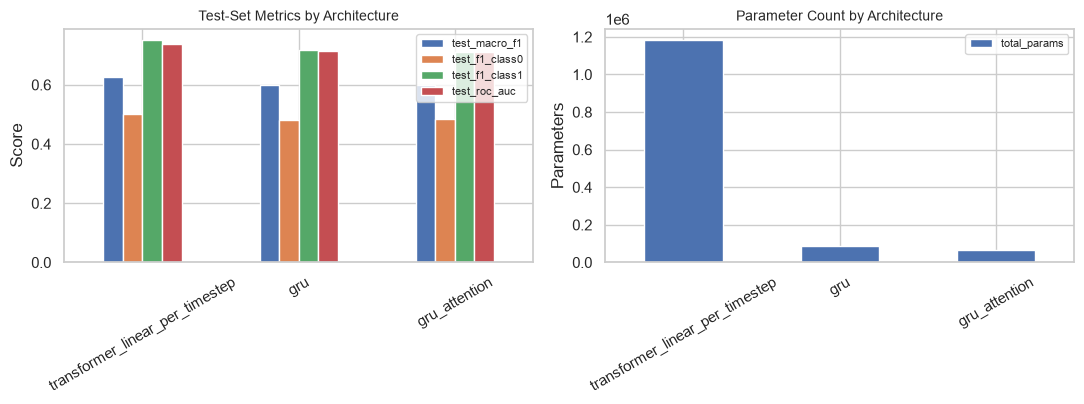

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_grouped_metric_comparison(
    architecture_comparison_df,
    metrics=['test_macro_f1', 'test_f1_class0', 'test_f1_class1', 'test_roc_auc'],
    title='Test-Set Metrics by Architecture', ax=axes[0],
)
plot_grouped_metric_comparison(
    architecture_comparison_df, metrics=['total_params'],
    title='Parameter Count by Architecture', ylabel='Parameters', ax=axes[1],
)
fig.tight_layout()
plt.show()

## Section 7: Cross-Architecture Ablation Comparison

For each archiecture, we run the same 3 data ablations independently (Section 4f-4h for GRU, 4k-4m for GRU + Attention, 5f-5h for Transformer), but every result so far has only ever been tabulated *within* its own track. Here, we pull all three tracks' already-computed ablation results together into one set of charts per ablation.

#### Fixations vs. Saccades, Across All Three Architectures

Combines each track's event-type test summary (`gru_event_test_summary`, `gru_attn_event_test_summary`, `lpt_event_test_summary`) into one long-format DataFrame, then plots test Macro F1 for the `fixations_only`, `saccades_only`, and `both_events_baseline` condition of each architecture side by side.

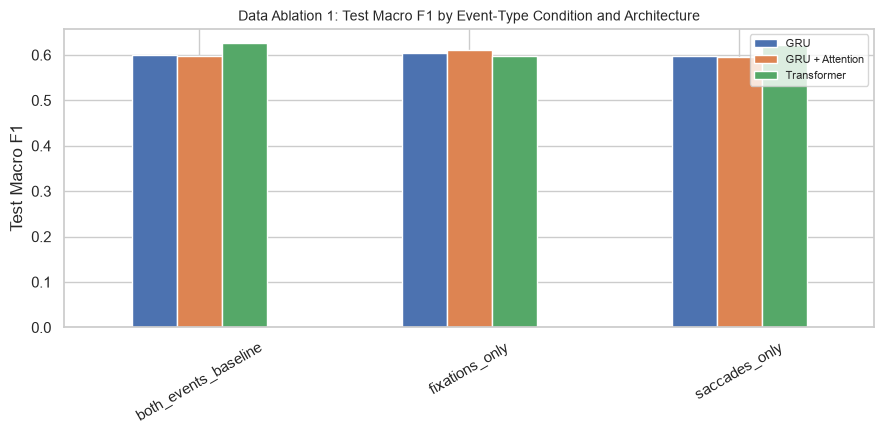

In [64]:
event_ablation_rows = []
for arch_name, summary_df in [
    ('GRU', gru_event_test_summary),
    ('GRU + Attention', gru_attn_event_test_summary),
    ('Transformer', lpt_event_test_summary),
]:
    for condition, row in summary_df.iterrows():
        event_ablation_rows.append({
            'architecture': arch_name,
            'condition': condition,
            'test_macro_f1': row['test_macro_f1'],
        })

event_ablation_df = pd.DataFrame(event_ablation_rows)
event_ablation_pivot = event_ablation_df.pivot(index='condition', columns='architecture', values='test_macro_f1')
event_ablation_pivot = event_ablation_pivot.loc[['both_events_baseline', 'fixations_only', 'saccades_only']]

plot_grouped_metric_comparison(
    event_ablation_pivot, metrics=list(event_ablation_pivot.columns),
    title='Data Ablation 1: Test Macro F1 by Event-Type Condition and Architecture',
    ylabel='Test Macro F1',
)

#### Coordinate-Free Features, Across All Three Architectures

Combines each track's full-feature baseline and coordinate-free test metrics into one comparison, plotting test Macro F1 for both conditions of each architecture.

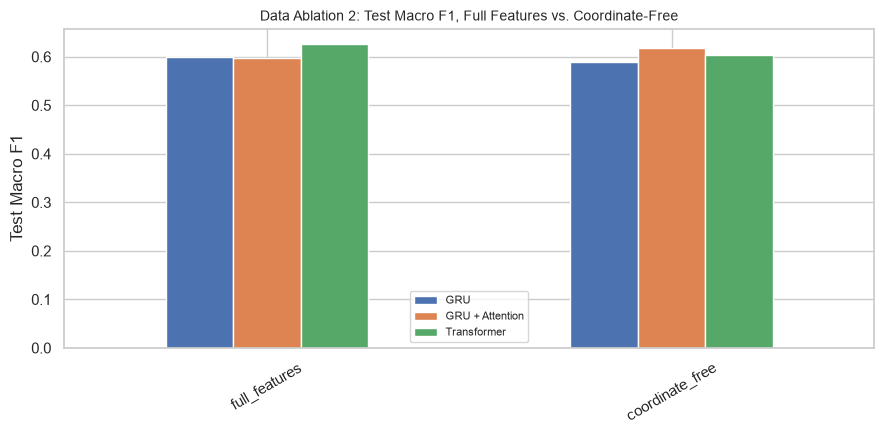

In [65]:
coordfree_ablation_rows = [
    {'architecture': 'GRU', 'condition': 'full_features', 'test_macro_f1': gru_final_test_metrics['macro_f1']},
    {'architecture': 'GRU', 'condition': 'coordinate_free', 'test_macro_f1': gru_coordfree_test_metrics['macro_f1']},
    {'architecture': 'GRU + Attention', 'condition': 'full_features', 'test_macro_f1': gru_attn_final_test_metrics['macro_f1']},
    {'architecture': 'GRU + Attention', 'condition': 'coordinate_free', 'test_macro_f1': gru_attn_coordfree_test_metrics['macro_f1']},
    {'architecture': 'Transformer', 'condition': 'full_features', 'test_macro_f1': lpt_final_test_metrics['macro_f1']},
    {'architecture': 'Transformer', 'condition': 'coordinate_free', 'test_macro_f1': lpt_coordfree_test_metrics['macro_f1']},
]
coordfree_ablation_df = pd.DataFrame(coordfree_ablation_rows)
coordfree_ablation_pivot = coordfree_ablation_df.pivot(index='condition', columns='architecture', values='test_macro_f1')
coordfree_ablation_pivot = coordfree_ablation_pivot.loc[['full_features', 'coordinate_free']]

plot_grouped_metric_comparison(
    coordfree_ablation_pivot, metrics=list(coordfree_ablation_pivot.columns),
    title='Data Ablation 2: Test Macro F1, Full Features vs. Coordinate-Free',
    ylabel='Test Macro F1',
)

#### Per-Task Specialization (Specialists), Across All Three Architectures

Combines each track's per-block specialist test Macro F1 (`gru_task_test_summary`, `gru_attn_task_test_summary`, `lpt_task_test_summary`) into one chart, restricted to the `_specialist` rows so the comparison is about task blocks, not repeating each track's own specialist-vs-generalist framing a fourth time.

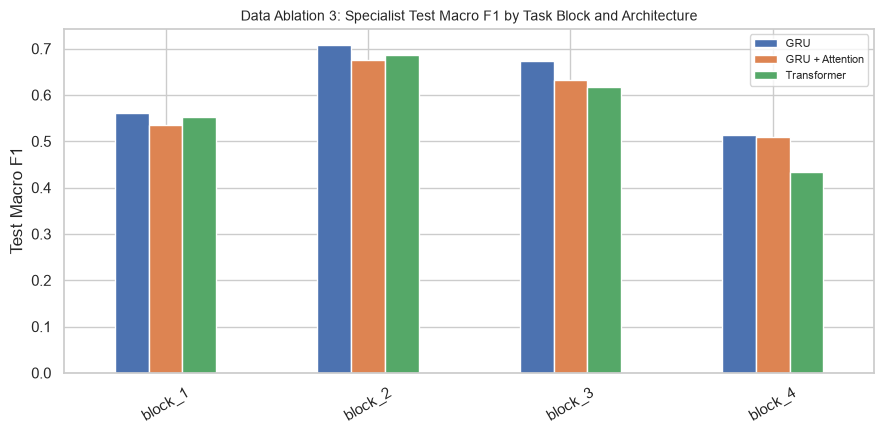

In [66]:
task_ablation_rows = []
for arch_name, summary_df in [
    ('GRU', gru_task_test_summary),
    ('GRU + Attention', gru_attn_task_test_summary),
    ('Transformer', lpt_task_test_summary),
]:
    specialist_rows = summary_df[summary_df.index.str.endswith('_specialist')]
    for block_label, row in specialist_rows.iterrows():
        task_ablation_rows.append({
            'architecture': arch_name,
            'block': block_label.replace('_specialist', ''),
            'test_macro_f1': row['test_macro_f1'],
        })

task_ablation_df = pd.DataFrame(task_ablation_rows)
task_ablation_pivot = task_ablation_df.pivot(index='block', columns='architecture', values='test_macro_f1')
task_ablation_pivot = task_ablation_pivot.loc[TASK_BLOCKS]

plot_grouped_metric_comparison(
    task_ablation_pivot, metrics=list(task_ablation_pivot.columns),
    title='Data Ablation 3: Specialist Test Macro F1 by Task Block and Architecture',
    ylabel='Test Macro F1',
)

In [67]:
print("Done running :)")

_notebook_end_time = time.time()
_elapsed_seconds = _notebook_end_time - _notebook_start_time

_hours, _rem = divmod(int(_elapsed_seconds), 3600)
_minutes, _seconds = divmod(_rem, 60)

print(f"Total notebook runtime: {_hours:02d}h {_minutes:02d}m {_seconds:02d}s (from timer start to this cell)")


Done running :)
Total notebook runtime: 02h 49m 38s (from timer start to this cell)


<div align="center">
    <h2>### NOTHING FOLLOWS ###</h2>
</div>